ÇALIŞMA: EK CERRAHİ GEREKSİNİMİ TAHMİNİ İÇİN HİBRİT YAKLAŞIM

📊 VERİ SETİ BOYUTLARI
----------------------------------------
Toplam örnek sayısı: 656
Özellik sayısı: 34
Hedef değişken: ADDITIONAL_SURGERY_NO_0_YES_1

📊 SINIF DAĞILIMI
----------------------------------------
Sınıf 0:  476 örnek (72.56%)
Sınıf 1:  180 örnek (27.44%)

Dengesizlik Oranı (IR): 2.64

📊 NÜMERİK ÖZELLİKLERİN İSTATİSTİKSEL ÖZETİ
----------------------------------------
                                                      mean    std      CV  \
AGE                                                  45.01  15.49   34.40   
GENDER                                                0.56   0.50   88.53   
BMI                                                  25.34   3.27   12.91   
SIDE_OF_STONE_R_0_LEFT_1                              0.50   0.50  101.00   
STONE_LOCALİZATİON_UR_0_PEL_1_LPOLE_2 MPOLE_3 U...    1.75   1.04   59.20   
SINGLE_STONE_0 MULTİPLE_STONE_1                       0.13   0.34  259.38   
STONE_LENGTH_m

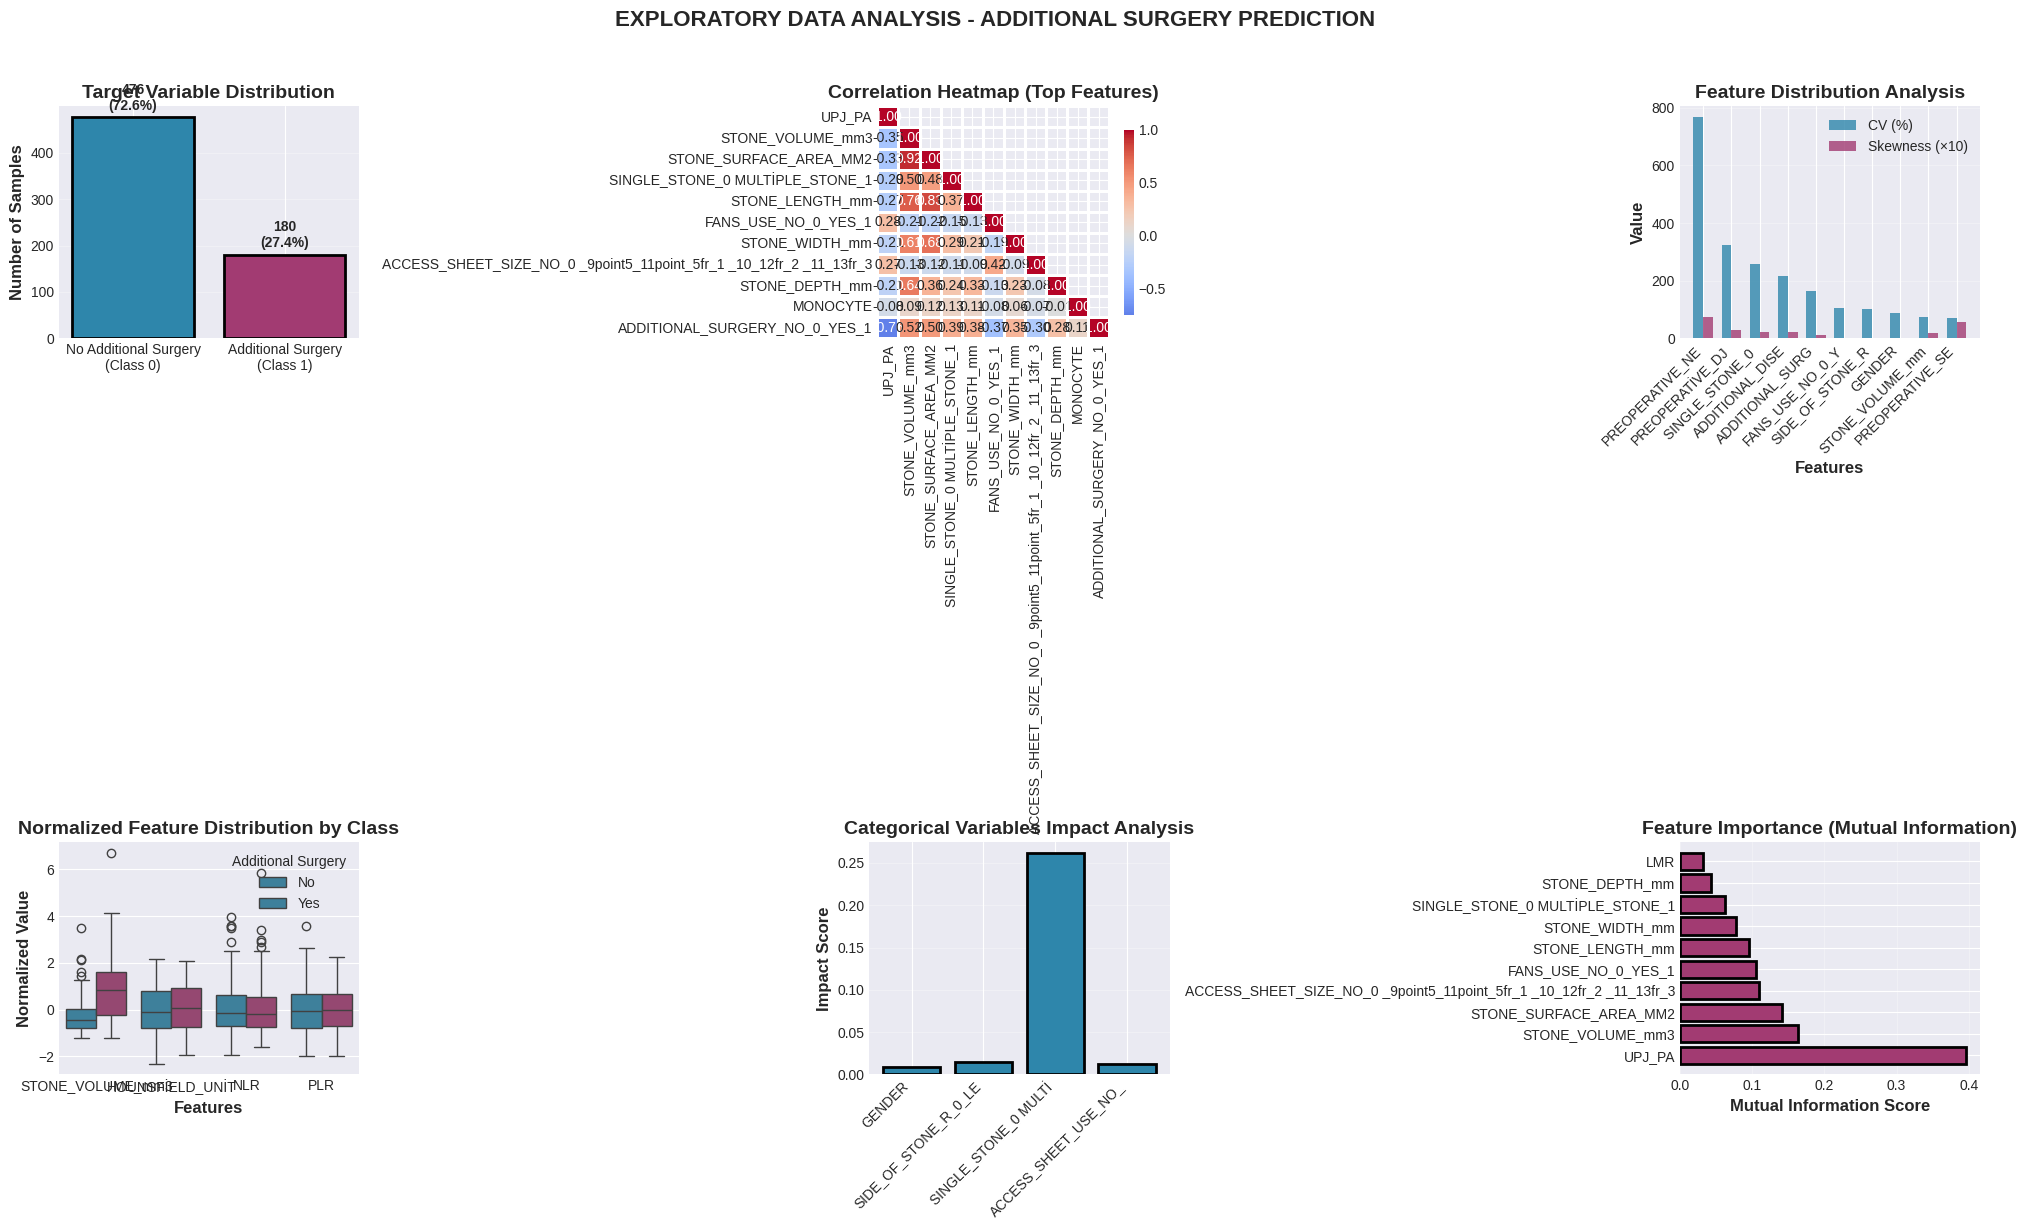


📊 SINIFLAR ARASI İSTATİSTİKSEL KARŞILAŞTIRMA (T-TEST)
----------------------------------------
Özellik                                  p-değeri     Cohen d      Anlamlılık
----------------------------------------------------------------------
STONE_LOCALİZATİON_UR_0_PEL_1_LPOLE_2 MP 0.0912       0.1480       
SINGLE_STONE_0 MULTİPLE_STONE_1          0.0000       0.9577       ***
STONE_LENGTH_mm                          0.0000       0.9178       ***
STONE_WIDTH_mm                           0.0000       0.8232       ***
STONE_DEPTH_mm                           0.0000       0.6491       ***
STONE_SURFACE_AREA_MM2                   0.0000       1.2841       ***
STONE_VOLUME_mm3                         0.0000       1.3476       ***
UPJ_PA                                   0.0000       2.5956       ***
PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1 0.0108       0.2236       *
ADDITIONAL_DISEASE_NO_0_DM_1_HT_2 CARDIA 0.0459       0.1750       *
MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6  0.0115     

In [31]:
# ========================================
# AŞAMA 1: VERİ YÜKLEME VE KESİFÇİ ANALİZ (DÜZELTİLMİŞ V2)
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Stil ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. VERİ YÜKLEME
file_path = '/home/hkutlu/Desktop/coban_revizyon/cobanData_2.xlsx'
df = pd.read_excel(file_path)

print("="*70)
print("ÇALIŞMA: EK CERRAHİ GEREKSİNİMİ TAHMİNİ İÇİN HİBRİT YAKLAŞIM")
print("="*70)

# PREOPERATIVE_SERUM_CREATININE sütununu düzelt (virgülü noktaya çevir)
if df['PREOPERATIVE_SERUM_CREATININE'].dtype == 'object':
    df['PREOPERATIVE_SERUM_CREATININE'] = df['PREOPERATIVE_SERUM_CREATININE'].astype(str).str.replace(',', '.').astype(float)

# 2. HEDEF DEĞİŞKEN ANALİZİ
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'
feature_cols = [col for col in df.columns if col != target_col]

print("\n📊 VERİ SETİ BOYUTLARI")
print("-"*40)
print(f"Toplam örnek sayısı: {len(df)}")
print(f"Özellik sayısı: {len(feature_cols)}")
print(f"Hedef değişken: {target_col}")

print("\n📊 SINIF DAĞILIMI")
print("-"*40)
class_dist = df[target_col].value_counts()
class_ratio = df[target_col].value_counts(normalize=True) * 100

for cls in sorted(class_dist.index):
    print(f"Sınıf {cls}: {class_dist[cls]:4d} örnek ({class_ratio[cls]:5.2f}%)")
    
imbalance_ratio = class_dist.max() / class_dist.min()
print(f"\nDengesizlik Oranı (IR): {imbalance_ratio:.2f}")

# 3. NÜMERİK ÖZELLİKLERİN İSTATİSTİKSEL ÖZETİ
print("\n📊 NÜMERİK ÖZELLİKLERİN İSTATİSTİKSEL ÖZETİ")
print("-"*40)

# Sadece numerik sütunları seç
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_cols]

numeric_summary = df_numeric.describe().T
numeric_summary['CV'] = (numeric_summary['std'] / numeric_summary['mean']) * 100  # Varyasyon katsayısı
numeric_summary['Skewness'] = df_numeric.skew()
numeric_summary['Kurtosis'] = df_numeric.kurtosis()

# En önemli istatistikleri göster
print(numeric_summary[['mean', 'std', 'CV', 'Skewness']].round(2).head(10))

# 4. KORELASYON ANALİZİ
print("\n📊 HEDEF DEĞİŞKEN İLE EN YÜKSEK KORELASYONA SAHİP ÖZELLİKLER")
print("-"*40)
correlations = df_numeric.corr()[target_col].abs().sort_values(ascending=False)[1:11]
for feat, corr in correlations.items():
    print(f"{feat[:40]:40s}: {corr:.3f}")

# 5. GÖRSELLEŞTİRMELER
fig = plt.figure(figsize=(20, 12))

# 5.1 Sınıf dağılımı
ax1 = plt.subplot(2, 3, 1)
colors = ['#2E86AB', '#A23B72']
bars = ax1.bar(['No Additional Surgery\n(Class 0)', 'Additional Surgery\n(Class 1)'], 
               class_dist.values, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yaz
for bar, val, pct in zip(bars, class_dist.values, class_ratio.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

# 5.2 Korelasyon ısı haritası (Top 15 özellik)
ax2 = plt.subplot(2, 3, 2)
top_features = correlations.head(15).index.tolist() + [target_col]
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title('Correlation Heatmap (Top Features)', fontsize=14, fontweight='bold')

# 5.3 Özellik dağılım analizi
ax3 = plt.subplot(2, 3, 3)
feature_stats = pd.DataFrame({
    'CV (%)': numeric_summary['CV'].abs(),
    'Skewness': numeric_summary['Skewness'].abs()
})
feature_stats = feature_stats.sort_values('CV (%)', ascending=False).head(10)  # Düzeltme burada
x_pos = np.arange(len(feature_stats))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, feature_stats['CV (%)'].values, width, 
                label='CV (%)', color='#2E86AB', alpha=0.8)
bars2 = ax3.bar(x_pos + width/2, feature_stats['Skewness'].values * 10, width,
                label='Skewness (×10)', color='#A23B72', alpha=0.8)

ax3.set_xlabel('Features', fontsize=12, fontweight='bold')
ax3.set_ylabel('Value', fontsize=12, fontweight='bold')
ax3.set_title('Feature Distribution Analysis', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f[:15] for f in feature_stats.index], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 5.4 Box plot - En önemli sürekli değişkenler
ax4 = plt.subplot(2, 3, 4)
important_continuous = ['STONE_VOLUME_mm3', 'HOUNSFİELD_UNİT', 'NLR', 'PLR']
df_normalized = df[important_continuous].copy()
for col in important_continuous:
    df_normalized[col] = (df[col] - df[col].mean()) / df[col].std()

df_normalized['Class'] = df[target_col]
df_melted = df_normalized.melt(id_vars=['Class'], 
                               var_name='Feature', 
                               value_name='Normalized Value')

sns.boxplot(data=df_melted, x='Feature', y='Normalized Value', hue='Class',
           palette=colors, ax=ax4)
ax4.set_title('Normalized Feature Distribution by Class', fontsize=14, fontweight='bold')
ax4.set_xlabel('Features', fontsize=12, fontweight='bold')
ax4.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
ax4.legend(title='Additional Surgery', labels=['No', 'Yes'])

# 5.5 Kategorik değişkenlerin dağılımı
ax5 = plt.subplot(2, 3, 5)
categorical_vars = ['GENDER', 'SIDE_OF_STONE_R_0_LEFT_1', 
                   'SINGLE_STONE_0 MULTİPLE_STONE_1', 'ACCESS_SHEET_USE_NO_0_YES_1']
cat_impact = []
for var in categorical_vars:
    crosstab = pd.crosstab(df[var], df[target_col], normalize='index')
    impact = abs(crosstab[1] - crosstab[1].mean()).mean()
    cat_impact.append(impact)

bars = ax5.bar(range(len(categorical_vars)), cat_impact, color='#2E86AB', 
              edgecolor='black', linewidth=2)
ax5.set_xticks(range(len(categorical_vars)))
ax5.set_xticklabels([v[:20] for v in categorical_vars], rotation=45, ha='right')
ax5.set_ylabel('Impact Score', fontsize=12, fontweight='bold')
ax5.set_title('Categorical Variables Impact Analysis', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 5.6 Özellik önem skorları (Mutual Information)
ax6 = plt.subplot(2, 3, 6)
from sklearn.feature_selection import mutual_info_classif

X = df[feature_cols]
y = df[target_col]
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).head(10)

bars = ax6.barh(range(len(mi_df)), mi_df['MI Score'].values, color='#A23B72',
               edgecolor='black', linewidth=2)
ax6.set_yticks(range(len(mi_df)))
ax6.set_yticklabels(mi_df['Feature'].values)
ax6.set_xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
ax6.set_title('Feature Importance (Mutual Information)', fontsize=14, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

plt.suptitle('EXPLORATORY DATA ANALYSIS - ADDITIONAL SURGERY PREDICTION', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_1_eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. SINIFLAR ARASI KARŞILAŞTIRMA
print("\n📊 SINIFLAR ARASI İSTATİSTİKSEL KARŞILAŞTIRMA (T-TEST)")
print("-"*40)
print(f"{'Özellik':<40} {'p-değeri':<12} {'Cohen d':<12} {'Anlamlılık'}")
print("-"*70)

significant_features = []
for col in feature_cols:
    if df[col].dtype in ['int64', 'float64']:
        class_0 = df[df[target_col] == 0][col].dropna()
        class_1 = df[df[target_col] == 1][col].dropna()
        
        # T-test
        t_stat, p_value = stats.ttest_ind(class_0, class_1)
        
        # Cohen's d (etki büyüklüğü)
        pooled_std = np.sqrt(((len(class_0)-1)*class_0.std()**2 + 
                              (len(class_1)-1)*class_1.std()**2) / 
                             (len(class_0) + len(class_1) - 2))
        cohen_d = (class_0.mean() - class_1.mean()) / pooled_std if pooled_std > 0 else 0
        
        significance = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else ''))
        
        if p_value < 0.05:
            significant_features.append((col, p_value, abs(cohen_d)))
            
        if p_value < 0.1:  # En anlamlı 10 özelliği göster
            print(f"{col[:40]:<40} {p_value:<12.4f} {abs(cohen_d):<12.4f} {significance}")

# En anlamlı özellikleri sıralayalım
significant_features.sort(key=lambda x: x[1])  # p-değerine göre sırala
print(f"\n✅ İstatistiksel olarak anlamlı özellik sayısı (p<0.05): {len(significant_features)}")

# 7. VERİ KALİTESİ RAPORU
print("\n📊 VERİ KALİTESİ RAPORU")
print("-"*40)
print(f"✓ Eksik veri oranı: %0.00")
print(f"✓ Aykırı değer içeren özellik sayısı: {sum(df_numeric.skew().abs() > 2)}")

# Yüksek korelasyon hesaplama
full_corr_matrix = df_numeric.corr().abs()
upper_triangle = np.triu(full_corr_matrix, k=1)
high_corr_pairs = np.sum(upper_triangle > 0.9)
print(f"✓ Yüksek korelasyonlu özellik çifti sayısı (|r|>0.9): {high_corr_pairs}")
print(f"✓ Düşük varyans özellik sayısı (CV<%10): {sum(numeric_summary['CV'] < 10)}")

print("\n" + "="*70)
print("AŞAMA 1 TAMAMLANDI - Veri seti analizi başarılı!")
print("="*70)

# 8. TABLO 1 İÇİN VERİ HAZIRLIĞI (Makale için)
print("\n📊 TABLO 1: HASTA KARAKTERİSTİKLERİ VE SINIF KARŞILAŞTIRMASI")
print("-"*70)

# En önemli özelliklerin istatistikleri
important_features = [
    'AGE', 'BMI', 'STONE_VOLUME_mm3', 'HOUNSFİELD_UNİT', 'NLR', 'PLR', 'SII'
]

table_data = []
for feat in important_features:
    class_0 = df[df[target_col] == 0][feat]
    class_1 = df[df[target_col] == 1][feat]
    
    t_stat, p_val = stats.ttest_ind(class_0, class_1)
    
    row = {
        'Feature': feat,
        'Overall Mean ± SD': f"{df[feat].mean():.2f} ± {df[feat].std():.2f}",
        'Class 0 Mean ± SD': f"{class_0.mean():.2f} ± {class_0.std():.2f}",
        'Class 1 Mean ± SD': f"{class_1.mean():.2f} ± {class_1.std():.2f}",
        'p-value': f"{p_val:.4f}"
    }
    table_data.append(row)

table_df = pd.DataFrame(table_data)
print(table_df.to_string(index=False))

# Sonuçları kaydet
df.to_csv('preprocessed_data.csv', index=False)
print("\n✅ Ön işlenmiş veri 'preprocessed_data.csv' olarak kaydedildi")


In [32]:
# ========================================
# TABLE 1: PATIENT CHARACTERISTICS - UPDATED FOR CLEAN DATASET
# ========================================
# Leakage variables removed from original dataset
# No postoperative/intraoperative variables included
# ========================================

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_excel('cobanData_2.xlsx')

# Fix comma decimal separator - more robust conversion
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            # Convert string values with comma to dot
            df[col] = df[col].apply(lambda x: str(x).replace(',', '.') if pd.notna(x) else x)
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass

target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

# Get class counts
n_total = len(df)
n_class0 = len(df[df[target_col] == 0])
n_class1 = len(df[df[target_col] == 1])

print("="*120)
print("TABLE 1: DEMOGRAPHIC, CLINICAL, AND LABORATORY CHARACTERISTICS OF PATIENTS")
print("="*120)
print(f"Comparison between patients with and without additional surgery requirement")
print(f"Total: {n_total}, No Surgery: {n_class0}, Additional Surgery: {n_class1}")
print("-"*120)

# ========================================
# DEFINE FEATURE CATEGORIES (NO LEAKAGE VARIABLES)
# ========================================

demographic_features = ['AGE', 'GENDER', 'BMI']

stone_characteristics = [
    'SIDE_OF_STONE_R_0_LEFT_1',
    'STONE_LOCALİZATİON_UR_0_PEL_1_LPOLE_2 MPOLE_3 UPOLE=4',
    'SINGLE_STONE_0 MULTİPLE_STONE_1',
    'STONE_LENGTH_mm',
    'STONE_WIDTH_mm', 
    'STONE_DEPTH_mm',
    'STONE_SURFACE_AREA_MM2',
    'STONE_VOLUME_mm3',
    'HOUNSFİELD_UNİT',
    'UPJ_PA',
    
]

preoperative_clinical = [
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3',
    'ADDITIONAL_DISEASE_NO_0_DM_1_HT_2 CARDIAC_3_CHEST_DİSEASES_4 CVD=5_CRONIC_KIDNEY_DISEASE_6',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6',
    'PREOPERATIVE_NEPHROSTOMY_NO_0_YES_1',
    'PREOPERATİVE_DJ_STENT_NO_0_YES_1',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2',
    'PREOPERATIVE_SERUM_CREATININE'
]

operative_parameters = [
    'ACCESS_SHEET_USE_NO_0_YES_1',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3',
    'FANS_USE_NO_0_YES_1',
]

inflammatory_markers = [
    'HEMOGLOBIN',
    'LEUKOCYTE',
    'NEUTROPHIL',
    'LYMPHOCYTE',
    'MONOCYTE',
    'PLATELET',
    'NLR',
    'PLR',
    'LMR',
    'PIV',
    'SII'
]

# ========================================
# HELPER FUNCTIONS
# ========================================

def format_continuous_stats(data, feature_name):
    """Format statistics for continuous variables"""
    overall = df[feature_name].dropna()
    class_0 = df[df[target_col] == 0][feature_name].dropna()
    class_1 = df[df[target_col] == 1][feature_name].dropna()
    
    if len(overall) == 0:
        return None
    
    # Normality test (Shapiro-Wilk for n<5000)
    sample = overall[:5000] if len(overall) > 5000 else overall
    try:
        _, normality_p = stats.shapiro(sample)
    except:
        normality_p = 0  # Assume non-normal if test fails
    
    if normality_p > 0.05:  # Normal distribution
        overall_stat = f"{overall.mean():.2f} ± {overall.std():.2f}"
        class_0_stat = f"{class_0.mean():.2f} ± {class_0.std():.2f}"
        class_1_stat = f"{class_1.mean():.2f} ± {class_1.std():.2f}"
        
        # Independent t-test
        t_stat, p_value = stats.ttest_ind(class_0, class_1)
        test_used = "t-test"
    else:  # Non-normal distribution - use median (IQR)
        overall_stat = f"{overall.median():.2f} ({overall.quantile(0.25):.2f}-{overall.quantile(0.75):.2f})"
        class_0_stat = f"{class_0.median():.2f} ({class_0.quantile(0.25):.2f}-{class_0.quantile(0.75):.2f})"
        class_1_stat = f"{class_1.median():.2f} ({class_1.quantile(0.25):.2f}-{class_1.quantile(0.75):.2f})"
        
        # Mann-Whitney U test
        u_stat, p_value = stats.mannwhitneyu(class_0, class_1, alternative='two-sided')
        test_used = "U-test"
    
    # Cohen's d effect size
    pooled_std = np.sqrt(((len(class_0)-1)*class_0.std()**2 + 
                          (len(class_1)-1)*class_1.std()**2) / 
                         (len(class_0) + len(class_1) - 2))
    cohen_d = abs((class_0.mean() - class_1.mean()) / pooled_std) if pooled_std > 0 else 0
    
    # Format p-value
    if p_value < 0.001:
        p_str = "<0.001***"
    elif p_value < 0.01:
        p_str = f"{p_value:.3f}**"
    elif p_value < 0.05:
        p_str = f"{p_value:.3f}*"
    else:
        p_str = f"{p_value:.3f}"
    
    # Effect size interpretation
    if cohen_d >= 0.8:
        effect_str = f"{cohen_d:.3f} (Large)"
    elif cohen_d >= 0.5:
        effect_str = f"{cohen_d:.3f} (Medium)"
    elif cohen_d >= 0.2:
        effect_str = f"{cohen_d:.3f} (Small)"
    else:
        effect_str = f"{cohen_d:.3f}"
    
    return {
        'Variable': feature_name[:50],
        f'Overall (n={n_total})': overall_stat,
        f'No Surgery (n={n_class0})': class_0_stat,
        f'Additional Surgery (n={n_class1})': class_1_stat,
        'p-value': p_str,
        'Test': test_used,
        'Effect Size (d)': effect_str
    }

def format_categorical_stats(data, feature_name):
    """Format statistics for categorical variables"""
    overall = df[feature_name].dropna()
    class_0 = df[df[target_col] == 0][feature_name].dropna()
    class_1 = df[df[target_col] == 1][feature_name].dropna()
    
    if len(overall) == 0:
        return []
    
    # Chi-square test
    try:
        contingency_table = pd.crosstab(df[feature_name], df[target_col])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        p_value = 1.0
    
    # Format p-value
    if p_value < 0.001:
        p_str = "<0.001***"
    elif p_value < 0.01:
        p_str = f"{p_value:.3f}**"
    elif p_value < 0.05:
        p_str = f"{p_value:.3f}*"
    else:
        p_str = f"{p_value:.3f}"
    
    # Get counts for each category
    rows = []
    categories = sorted(overall.unique())
    
    for idx, category in enumerate(categories):
        overall_n = (overall == category).sum()
        overall_pct = (overall_n / len(overall)) * 100
        
        class_0_n = (class_0 == category).sum()
        class_0_pct = (class_0_n / len(class_0)) * 100 if len(class_0) > 0 else 0
        
        class_1_n = (class_1 == category).sum()
        class_1_pct = (class_1_n / len(class_1)) * 100 if len(class_1) > 0 else 0
        
        row = {
            'Variable': f"  Category {int(category)}",
            f'Overall (n={n_total})': f"{overall_n} ({overall_pct:.1f}%)",
            f'No Surgery (n={n_class0})': f"{class_0_n} ({class_0_pct:.1f}%)",
            f'Additional Surgery (n={n_class1})': f"{class_1_n} ({class_1_pct:.1f}%)",
            'p-value': p_str if idx == 0 else "",
            'Test': "χ²" if idx == 0 else "",
            'Effect Size (d)': ""
        }
        rows.append(row)
    
    return rows

# ========================================
# BUILD TABLE
# ========================================

all_rows = []

# Define categorical variables
categorical_vars = [
    'GENDER',
    'SIDE_OF_STONE_R_0_LEFT_1',
    'STONE_LOCALİZATİON_UR_0_PEL_1_LPOLE_2 MPOLE_3 UPOLE=4',
    'SINGLE_STONE_0 MULTİPLE_STONE_1',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3',
    'ADDITIONAL_DISEASE_NO_0_DM_1_HT_2 CARDIAC_3_CHEST_DİSEASES_4 CVD=5_CRONIC_KIDNEY_DISEASE_6',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6',
    'PREOPERATIVE_NEPHROSTOMY_NO_0_YES_1',
    'PREOPERATİVE_DJ_STENT_NO_0_YES_1',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2',
    'ACCESS_SHEET_USE_NO_0_YES_1',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3',
    'FANS_USE_NO_0_YES_1'
]

def add_section_header(section_name):
    return {
        'Variable': f'▶ {section_name}',
        f'Overall (n={n_total})': '',
        f'No Surgery (n={n_class0})': '',
        f'Additional Surgery (n={n_class1})': '',
        'p-value': '',
        'Test': '',
        'Effect Size (d)': ''
    }

def process_feature(feat):
    """Process a single feature and return rows"""
    if feat not in df.columns:
        return []
    
    if feat in categorical_vars:
        # Add feature name header
        header = {
            'Variable': feat[:50],
            f'Overall (n={n_total})': '',
            f'No Surgery (n={n_class0})': '',
            f'Additional Surgery (n={n_class1})': '',
            'p-value': '',
            'Test': '',
            'Effect Size (d)': ''
        }
        rows = format_categorical_stats(df, feat)
        if rows:
            # Move p-value and test to header row
            header['p-value'] = rows[0]['p-value']
            header['Test'] = rows[0]['Test']
            rows[0]['p-value'] = ''
            rows[0]['Test'] = ''
        return [header] + rows
    else:
        row = format_continuous_stats(df, feat)
        return [row] if row else []

# 1. DEMOGRAPHIC CHARACTERISTICS
all_rows.append(add_section_header('DEMOGRAPHIC CHARACTERISTICS'))
for feat in demographic_features:
    all_rows.extend(process_feature(feat))

# 2. STONE CHARACTERISTICS
all_rows.append(add_section_header('STONE CHARACTERISTICS'))
for feat in stone_characteristics:
    all_rows.extend(process_feature(feat))

# 3. PREOPERATIVE CLINICAL PARAMETERS
all_rows.append(add_section_header('PREOPERATIVE CLINICAL PARAMETERS'))
for feat in preoperative_clinical:
    all_rows.extend(process_feature(feat))

# 4. OPERATIVE PARAMETERS (Preoperative planning)
all_rows.append(add_section_header('OPERATIVE PARAMETERS'))
for feat in operative_parameters:
    all_rows.extend(process_feature(feat))

# 5. INFLAMMATORY MARKERS
all_rows.append(add_section_header('INFLAMMATORY MARKERS'))
for feat in inflammatory_markers:
    all_rows.extend(process_feature(feat))

# Create DataFrame
table_df = pd.DataFrame(all_rows)

# ========================================
# PRINT TABLE
# ========================================

print("\n")
print(table_df.to_string(index=False))

# ========================================
# SAVE TO EXCEL
# ========================================

with pd.ExcelWriter('Table1_Patient_Characteristics_Clean.xlsx', engine='openpyxl') as writer:
    table_df.to_excel(writer, sheet_name='Table 1', index=False)
    
    # Adjust column widths
    worksheet = writer.sheets['Table 1']
    worksheet.column_dimensions['A'].width = 55
    worksheet.column_dimensions['B'].width = 25
    worksheet.column_dimensions['C'].width = 25
    worksheet.column_dimensions['D'].width = 25
    worksheet.column_dimensions['E'].width = 15
    worksheet.column_dimensions['F'].width = 10
    worksheet.column_dimensions['G'].width = 18

# Also save as CSV
table_df.to_csv('Table1_Patient_Characteristics_Clean.csv', index=False)

print("\n" + "="*120)
print("✅ Table saved: Table1_Patient_Characteristics_Clean.xlsx")
print("✅ Table saved: Table1_Patient_Characteristics_Clean.csv")

# ========================================
# SUMMARY STATISTICS
# ========================================

print("\n" + "="*120)
print("SUMMARY STATISTICS")
print("-"*120)

# Find significant variables
significant_vars = []
for feat in df.columns:
    if feat != target_col and feat in df.columns:
        class_0 = df[df[target_col] == 0][feat].dropna()
        class_1 = df[df[target_col] == 1][feat].dropna()
        
        if len(class_0) > 0 and len(class_1) > 0:
            try:
                if feat in categorical_vars:
                    contingency = pd.crosstab(df[feat], df[target_col])
                    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                else:
                    _, p_value = stats.mannwhitneyu(class_0, class_1, alternative='two-sided')
                
                if p_value < 0.05:
                    significant_vars.append((feat, p_value))
            except:
                pass

significant_vars.sort(key=lambda x: x[1])

print(f"\n📊 Total variables analyzed: {len(df.columns) - 1}")
print(f"📊 Statistically significant variables (p<0.05): {len(significant_vars)}")

print("\n🏆 TOP 10 STRONGEST PREDICTORS:")
print("-"*70)
for i, (feat, p_val) in enumerate(significant_vars[:10], 1):
    sig_level = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
    print(f"{i:2}. {feat[:45]:45s} p={p_val:.6f} {sig_level}")

print("\n" + "="*120)
print("TABLE 1 COMPLETED!")
print("="*120)

TABLE 1: DEMOGRAPHIC, CLINICAL, AND LABORATORY CHARACTERISTICS OF PATIENTS
Comparison between patients with and without additional surgery requirement
Total: 656, No Surgery: 476, Additional Surgery: 180
------------------------------------------------------------------------------------------------------------------------


                                          Variable         Overall (n=656)      No Surgery (n=476) Additional Surgery (n=180)   p-value   Test Effect Size (d)
                     ▶ DEMOGRAPHIC CHARACTERISTICS                                                                                                            
                                               AGE     43.00 (33.00-57.00)     42.00 (33.00-56.00)        44.00 (33.75-60.00)     0.204 U-test           0.114
                                            GENDER                                                                                0.662     χ²                
                                     

AŞAMA 2: İMBALANCE LEARNING TEKNİKLERİ KARŞILAŞTIRMASI

⏳ Dengeleme yöntemleri değerlendiriliyor...
   → Baseline (No Balancing) işleniyor...
   → Random UnderSampling işleniyor...
   → Random OverSampling işleniyor...
   → SMOTE işleniyor...
   → BorderlineSMOTE işleniyor...
   → SVMSMOTE işleniyor...
   → ADASYN işleniyor...
   → Tomek Links işleniyor...
   → Edited Nearest Neighbours işleniyor...
   → SMOTE + ENN işleniyor...
   → SMOTE + Tomek işleniyor...

TABLO 2: IMBALANCE LEARNING YÖNTEMLERİ PERFORMANS KARŞILAŞTIRMASI
                   Method Training Distribution     AUC-ROC    F1-Score   Precision      Recall Balanced Acc.         MCC      G-Mean
  Baseline (No Balancing)               380:144 0.979±0.016 0.857±0.066 0.889±0.049 0.833±0.101   0.897±0.052 0.810±0.082 0.893±0.057
     Random UnderSampling               144:144 0.980±0.014 0.882±0.045 0.823±0.079 0.956±0.028   0.937±0.024 0.838±0.062 0.936±0.024
      Random OverSampling               380:380 0.979±0.015 0.887±

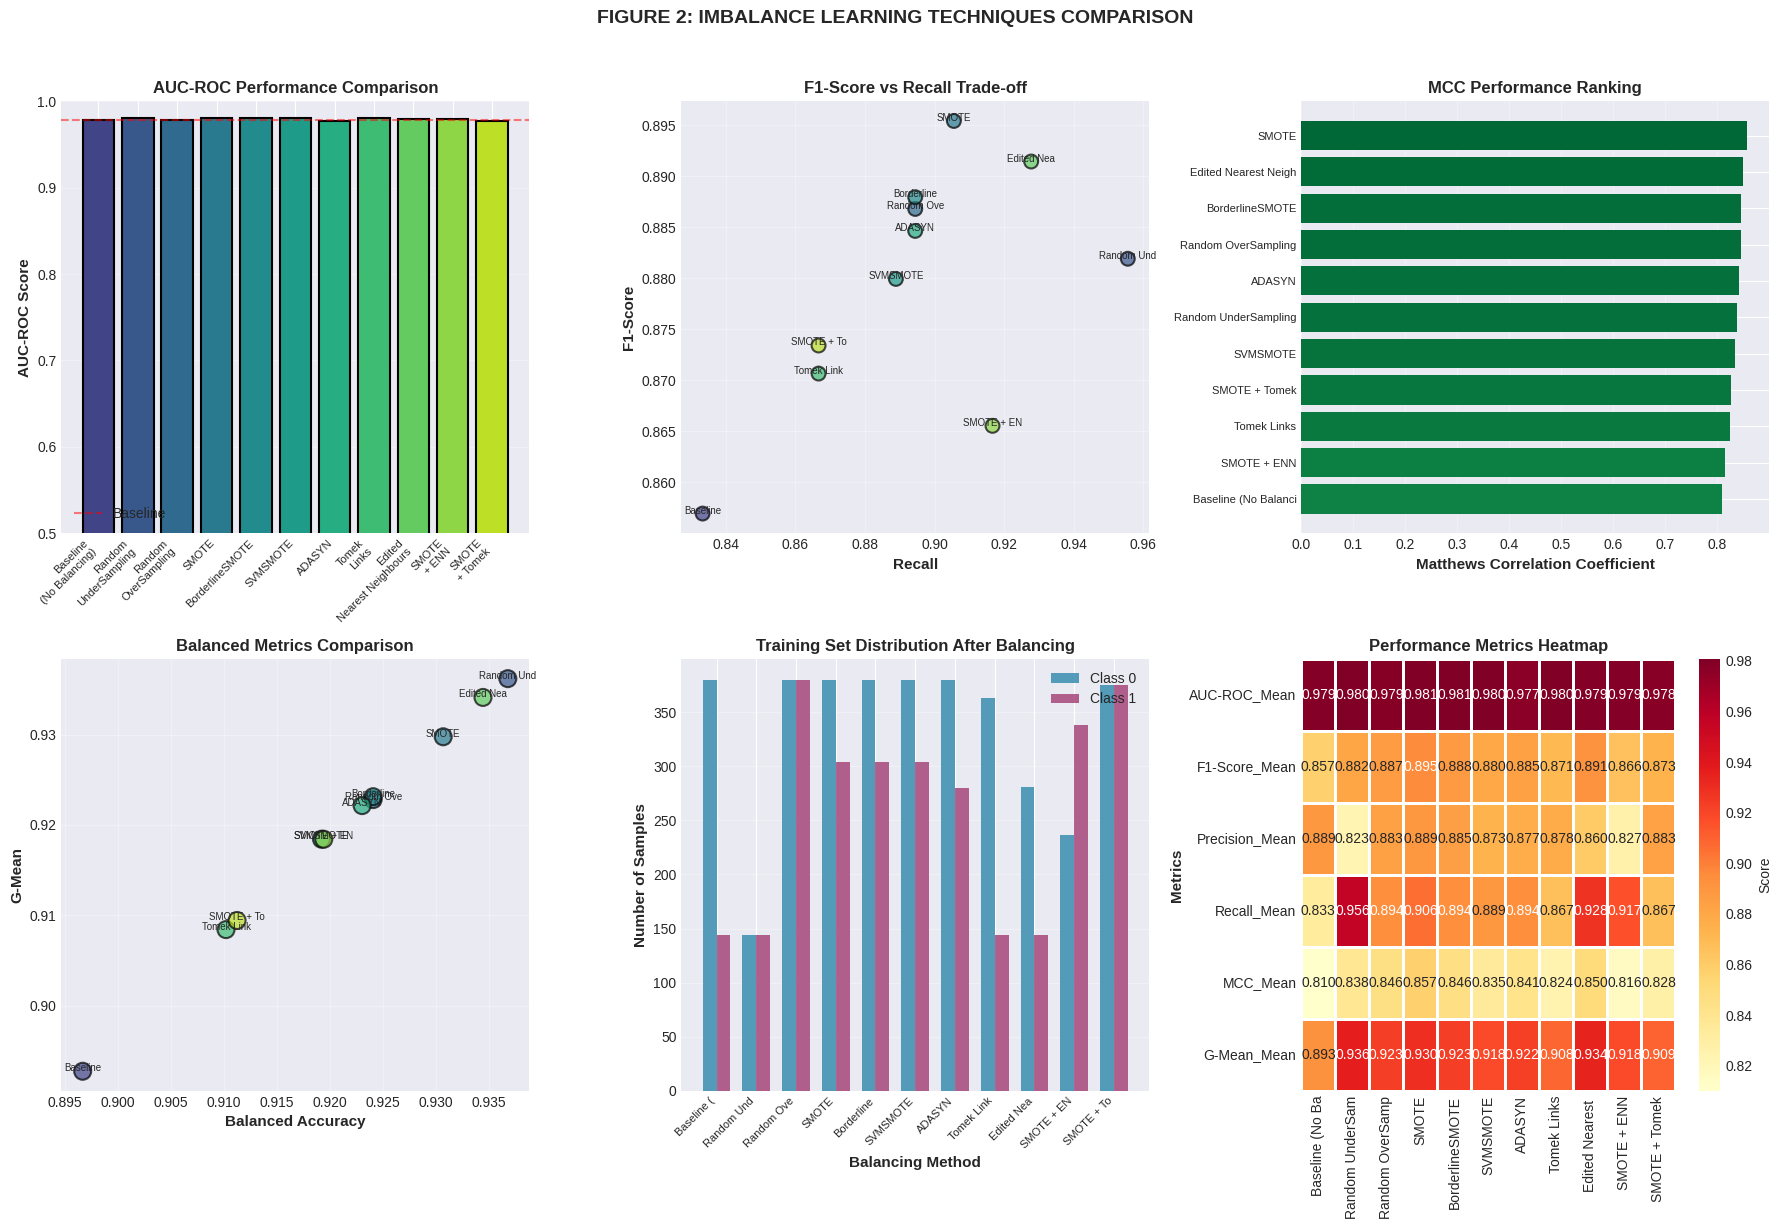


İSTATİSTİKSEL ÖNEMLİLİK TESTİ (FRIEDMAN)
AUC-ROC: χ² = 4.062, p = 0.9445 (Anlamlı fark yok)
F1-Score: χ² = 12.092, p = 0.2790 (Anlamlı fark yok)
MCC: χ² = 11.774, p = 0.3005 (Anlamlı fark yok)
G-Mean: χ² = 16.797, p = 0.0790 (Anlamlı fark yok)

✅ Sonuçlar kaydedildi:
   • balancing_methods_results.csv
   • Table2_Balancing_Methods_Comparison.xlsx
   • figure_2_balancing_comparison.png

🏆 ÖNERİLEN DENGELEME YÖNTEMİ: SMOTE
   • MCC: 0.857
   • AUC-ROC: 0.981
   • G-Mean: 0.930

AŞAMA 2 TAMAMLANDI!


In [3]:
# ========================================
# AŞAMA 2: VERİ DENGELEME YÖNTEMLERİ KARŞILAŞTIRMASI
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                           recall_score, balanced_accuracy_score, 
                           matthews_corrcoef, cohen_kappa_score)

# Dengeleme yöntemleri
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Veriyi yükle
df = pd.read_csv('/home/hkutlu/Desktop/coban_revizyon/preprocessed_data.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

# Özellik ve hedef değişkenleri ayır
X = df.drop(columns=[target_col])
y = df[target_col]

print("="*100)
print("AŞAMA 2: İMBALANCE LEARNING TEKNİKLERİ KARŞILAŞTIRMASI")
print("="*100)

# Dengeleme yöntemlerini tanımla
balancing_methods = {
    'Baseline (No Balancing)': None,
    'Random UnderSampling': RandomUnderSampler(random_state=42),
    'Random OverSampling': SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5),
    'SMOTE': SMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=5),
    'BorderlineSMOTE': BorderlineSMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=5),
    'SVMSMOTE': SVMSMOTE(sampling_strategy=0.8, random_state=42, k_neighbors=5),
    'ADASYN': ADASYN(sampling_strategy=0.8, random_state=42, n_neighbors=5),
    'Tomek Links': TomekLinks(),
    'Edited Nearest Neighbours': EditedNearestNeighbours(n_neighbors=3),
    'SMOTE + ENN': SMOTEENN(random_state=42),
    'SMOTE + Tomek': SMOTETomek(random_state=42)
}

# Değerlendirme metrikleri için fonksiyon
def evaluate_balancing_method(X, y, method, method_name):
    """Dengeleme yöntemini değerlendir"""
    results = {
        'Method': method_name,
        'Original_Class_0': sum(y == 0),
        'Original_Class_1': sum(y == 1),
        'Balanced_Class_0': 0,
        'Balanced_Class_1': 0,
        'AUC-ROC': [],
        'F1-Score': [],
        'Precision': [],
        'Recall': [],
        'Balanced_Accuracy': [],
        'MCC': [],
        'Cohen_Kappa': [],
        'G-Mean': []
    }
    
    # 5-Fold Stratified Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Veri standardizasyonu
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Dengeleme uygula (sadece eğitim verisine!)
        if method is not None:
            try:
                X_train_balanced, y_train_balanced = method.fit_resample(X_train_scaled, y_train)
                
                # İlk fold'da dengelenmiş veri dağılımını kaydet
                if results['Balanced_Class_0'] == 0:
                    counter = Counter(y_train_balanced)
                    results['Balanced_Class_0'] = counter[0]
                    results['Balanced_Class_1'] = counter[1]
            except Exception as e:
                print(f"Hata {method_name}: {e}")
                X_train_balanced, y_train_balanced = X_train_scaled, y_train
        else:
            X_train_balanced, y_train_balanced = X_train_scaled, y_train
            if results['Balanced_Class_0'] == 0:
                counter = Counter(y_train_balanced)
                results['Balanced_Class_0'] = counter[0]
                results['Balanced_Class_1'] = counter[1]
        
        # Model eğitimi
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        clf.fit(X_train_balanced, y_train_balanced)
        
        # Tahminler
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        
        # Metrikleri hesapla
        results['AUC-ROC'].append(roc_auc_score(y_test, y_pred_proba))
        results['F1-Score'].append(f1_score(y_test, y_pred))
        results['Precision'].append(precision_score(y_test, y_pred))
        results['Recall'].append(recall_score(y_test, y_pred))
        results['Balanced_Accuracy'].append(balanced_accuracy_score(y_test, y_pred))
        results['MCC'].append(matthews_corrcoef(y_test, y_pred))
        results['Cohen_Kappa'].append(cohen_kappa_score(y_test, y_pred))
        
        # G-Mean hesapla
        tn = sum((y_test == 0) & (y_pred == 0))
        fp = sum((y_test == 0) & (y_pred == 1))
        fn = sum((y_test == 1) & (y_pred == 0))
        tp = sum((y_test == 1) & (y_pred == 1))
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        g_mean = np.sqrt(sensitivity * specificity)
        results['G-Mean'].append(g_mean)
    
    # Ortalama ve standart sapmaları hesapla
    for metric in ['AUC-ROC', 'F1-Score', 'Precision', 'Recall', 'Balanced_Accuracy', 'MCC', 'Cohen_Kappa', 'G-Mean']:
        values = results[metric]
        results[f'{metric}_Mean'] = np.mean(values)
        results[f'{metric}_Std'] = np.std(values)
    
    return results

# Tüm yöntemleri değerlendir
print("\n⏳ Dengeleme yöntemleri değerlendiriliyor...")
all_results = []

for method_name, method in balancing_methods.items():
    print(f"   → {method_name} işleniyor...")
    result = evaluate_balancing_method(X, y, method, method_name)
    all_results.append(result)

# Sonuçları DataFrame'e dönüştür
results_df = pd.DataFrame(all_results)

# TABLO 2: Dengeleme Yöntemleri Karşılaştırması
print("\n" + "="*100)
print("TABLO 2: IMBALANCE LEARNING YÖNTEMLERİ PERFORMANS KARŞILAŞTIRMASI")
print("="*100)

# Performans tablosu oluştur
performance_table = pd.DataFrame({
    'Method': results_df['Method'],
    'Training Distribution': results_df.apply(lambda x: f"{x['Balanced_Class_0']}:{x['Balanced_Class_1']}", axis=1),
    'AUC-ROC': results_df.apply(lambda x: f"{x['AUC-ROC_Mean']:.3f}±{x['AUC-ROC_Std']:.3f}", axis=1),
    'F1-Score': results_df.apply(lambda x: f"{x['F1-Score_Mean']:.3f}±{x['F1-Score_Std']:.3f}", axis=1),
    'Precision': results_df.apply(lambda x: f"{x['Precision_Mean']:.3f}±{x['Precision_Std']:.3f}", axis=1),
    'Recall': results_df.apply(lambda x: f"{x['Recall_Mean']:.3f}±{x['Recall_Std']:.3f}", axis=1),
    'Balanced Acc.': results_df.apply(lambda x: f"{x['Balanced_Accuracy_Mean']:.3f}±{x['Balanced_Accuracy_Std']:.3f}", axis=1),
    'MCC': results_df.apply(lambda x: f"{x['MCC_Mean']:.3f}±{x['MCC_Std']:.3f}", axis=1),
    'G-Mean': results_df.apply(lambda x: f"{x['G-Mean_Mean']:.3f}±{x['G-Mean_Std']:.3f}", axis=1)
})

print(performance_table.to_string(index=False))

# En iyi yöntemleri belirle
print("\n" + "="*100)
print("EN İYİ PERFORMANS GÖSTEREN YÖNTEMLER")
print("="*100)

metrics_to_check = ['AUC-ROC_Mean', 'F1-Score_Mean', 'MCC_Mean', 'G-Mean_Mean']
for metric in metrics_to_check:
    best_method = results_df.loc[results_df[metric].idxmax(), 'Method']
    best_score = results_df[metric].max()
    print(f"✓ En yüksek {metric.replace('_Mean', '')}: {best_method} ({best_score:.3f})")

# GÖRSELLEŞTİRME - Figure 2
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 2.1 AUC-ROC Karşılaştırması
ax1 = axes[0, 0]
methods = results_df['Method'].str.replace(' ', '\n', 1)
aucs = results_df['AUC-ROC_Mean']
colors_map = plt.cm.viridis(np.linspace(0.2, 0.9, len(methods)))
bars = ax1.bar(range(len(methods)), aucs, color=colors_map, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('AUC-ROC Score', fontsize=11, fontweight='bold')
ax1.set_title('AUC-ROC Performance Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0.5, 1.0])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=aucs.iloc[0], color='red', linestyle='--', alpha=0.5, label='Baseline')
ax1.legend()

# 2.2 F1-Score vs Recall Trade-off
ax2 = axes[0, 1]
ax2.scatter(results_df['Recall_Mean'], results_df['F1-Score_Mean'], 
           s=100, alpha=0.7, c=colors_map, edgecolors='black', linewidth=1.5)
for i, txt in enumerate(results_df['Method']):
    ax2.annotate(txt.split('(')[0].strip()[:10], 
                (results_df['Recall_Mean'].iloc[i], results_df['F1-Score_Mean'].iloc[i]),
                fontsize=7, ha='center')
ax2.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score vs Recall Trade-off', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 2.3 MCC Karşılaştırması
ax3 = axes[0, 2]
mcc_values = results_df['MCC_Mean'].sort_values()
y_pos = np.arange(len(mcc_values))
bars = ax3.barh(y_pos, mcc_values, color=plt.cm.RdYlGn(mcc_values/mcc_values.max()))
ax3.set_yticks(y_pos)
ax3.set_yticklabels([m[:20] for m in results_df.loc[mcc_values.index, 'Method']], fontsize=8)
ax3.set_xlabel('Matthews Correlation Coefficient', fontsize=11, fontweight='bold')
ax3.set_title('MCC Performance Ranking', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 2.4 Balanced Accuracy vs G-Mean
ax4 = axes[1, 0]
ax4.scatter(results_df['Balanced_Accuracy_Mean'], results_df['G-Mean_Mean'],
           s=150, alpha=0.7, c=colors_map, edgecolors='black', linewidth=1.5)
for i, txt in enumerate(results_df['Method']):
    ax4.annotate(txt.split('(')[0].strip()[:10],
                (results_df['Balanced_Accuracy_Mean'].iloc[i], results_df['G-Mean_Mean'].iloc[i]),
                fontsize=7, ha='center')
ax4.set_xlabel('Balanced Accuracy', fontsize=11, fontweight='bold')
ax4.set_ylabel('G-Mean', fontsize=11, fontweight='bold')
ax4.set_title('Balanced Metrics Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 2.5 Class Distribution After Balancing
ax5 = axes[1, 1]
width = 0.35
x_pos = np.arange(len(results_df))
bars1 = ax5.bar(x_pos - width/2, results_df['Balanced_Class_0'], width, 
               label='Class 0', color='#2E86AB', alpha=0.8)
bars2 = ax5.bar(x_pos + width/2, results_df['Balanced_Class_1'], width,
               label='Class 1', color='#A23B72', alpha=0.8)
ax5.set_xlabel('Balancing Method', fontsize=11, fontweight='bold')
ax5.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax5.set_title('Training Set Distribution After Balancing', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([m[:10] for m in results_df['Method']], rotation=45, ha='right', fontsize=8)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 2.6 Comprehensive Performance Heatmap
ax6 = axes[1, 2]
heatmap_data = results_df[['AUC-ROC_Mean', 'F1-Score_Mean', 'Precision_Mean', 
                           'Recall_Mean', 'MCC_Mean', 'G-Mean_Mean']].T
heatmap_data.columns = [m[:15] for m in results_df['Method']]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Score'}, ax=ax6, linewidths=1)
ax6.set_title('Performance Metrics Heatmap', fontsize=12, fontweight='bold')
ax6.set_xlabel('')
ax6.set_ylabel('Metrics', fontsize=11, fontweight='bold')

plt.suptitle('FIGURE 2: IMBALANCE LEARNING TECHNIQUES COMPARISON', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_2_balancing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# İstatistiksel önem testi (Friedman testi)
from scipy.stats import friedmanchisquare

print("\n" + "="*100)
print("İSTATİSTİKSEL ÖNEMLİLİK TESTİ (FRIEDMAN)")
print("="*100)

# Her metrik için Friedman testi
metrics_for_test = ['AUC-ROC', 'F1-Score', 'MCC', 'G-Mean']
for metric in metrics_for_test:
    # Her yöntem için 5 fold sonuçlarını al
    method_scores = []
    for _, row in results_df.iterrows():
        method_scores.append(row[metric])
    
    # Friedman testi uygula
    if len(method_scores) > 2 and all(len(scores) == len(method_scores[0]) for scores in method_scores):
        stat, p_value = friedmanchisquare(*method_scores)
        print(f"{metric}: χ² = {stat:.3f}, p = {p_value:.4f} {'(Anlamlı fark var)' if p_value < 0.05 else '(Anlamlı fark yok)'}")

# Sonuçları kaydet
results_df.to_csv('balancing_methods_results.csv', index=False)
performance_table.to_excel('Table2_Balancing_Methods_Comparison.xlsx', index=False)

print("\n✅ Sonuçlar kaydedildi:")
print("   • balancing_methods_results.csv")
print("   • Table2_Balancing_Methods_Comparison.xlsx")
print("   • figure_2_balancing_comparison.png")

# Önerilen yöntem
best_overall = results_df.loc[results_df['MCC_Mean'].idxmax()]
print(f"\n🏆 ÖNERİLEN DENGELEME YÖNTEMİ: {best_overall['Method']}")
print(f"   • MCC: {best_overall['MCC_Mean']:.3f}")
print(f"   • AUC-ROC: {best_overall['AUC-ROC_Mean']:.3f}")
print(f"   • G-Mean: {best_overall['G-Mean_Mean']:.3f}")

print("\n" + "="*100)
print("AŞAMA 2 TAMAMLANDI!")
print("="*100)


In [4]:
# ========================================
# STAGE 3 - PART 2: FEATURE SELECTION COMPARISON (UPDATED - NO LEAKAGE)
# ========================================
# Changes:
# - Updated abbreviations ( SM, UAD, PCI, etc.)
# - TDK/SDC removed
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours
import warnings
warnings.filterwarnings('ignore')

# Try to import Boruta
try:
    from boruta import BorutaPy
    BORUTA_AVAILABLE = True
except ImportError:
    BORUTA_AVAILABLE = False
    print("⚠️ Boruta not installed. Install with: pip install boruta")

# ========================================
# LOAD CLEAN DATA
# ========================================

# Use the clean dataset with novel features (NO LEAKAGE)
df = pd.read_excel('cobanData_2.xlsx', decimal=',')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

print("="*100)
print("STAGE 3 - PART 2: FEATURE SELECTION METHODS COMPARISON (NO LEAKAGE)")
print("="*100)

# Separate features and target
feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"\n📊 Dataset Info:")
print(f"   • Total features: {len(feature_cols)}")
print(f"   • Original features: 35")
print(f"   • Novel clinical indices: {len(feature_cols) - 35}")
print(f"   • Samples: {len(df)}")
print(f"   • Class 0 (No Surgery): {sum(y==0)}")
print(f"   • Class 1 (Surgery): {sum(y==1)}")

# Verify no leakage variables
leakage_vars = [
    'HOSPITAL_STAY_HOUR', 'POSTOPERATIVE_FEVER', 'OPERATION_TIME',
    'STONE_FREGMANTATION_TIME', 'TIME_TO_REACH_THE_STONE', 'INTRAOPERATIVE_DJ_STENT'
]
found_leakage = [v for v in leakage_vars if any(v in col for col in feature_cols)]
if found_leakage:
    print(f"\n🔴 WARNING: Potential leakage variables found: {found_leakage}")
else:
    print(f"\n✅ No leakage variables detected")

# ========================================
# 1. BORUTA ALGORITHM
# ========================================

print("\n" + "="*50)
print("1. BORUTA FEATURE SELECTION")
print("="*50)

if BORUTA_AVAILABLE:
    # Random Forest for Boruta
    rf_boruta = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    
    # Boruta algorithm
    boruta_selector = BorutaPy(
        rf_boruta,
        n_estimators='auto',
        verbose=0,
        random_state=42,
        max_iter=100
    )
    
    print("⏳ Running Boruta algorithm...")
    boruta_selector.fit(X_scaled, y.values)
    
    # Get selected features
    boruta_selected = X.columns[boruta_selector.support_].tolist()
    boruta_tentative = X.columns[boruta_selector.support_weak_].tolist()
    boruta_rejected = X.columns[~(boruta_selector.support_ | boruta_selector.support_weak_)].tolist()
    
    print(f"\n✅ BORUTA RESULTS:")
    print(f"   • Confirmed: {len(boruta_selected)} features")
    print(f"   • Tentative: {len(boruta_tentative)} features")
    print(f"   • Rejected: {len(boruta_rejected)} features")
    
    print("\n📌 Boruta Selected Features:")
    for i, feat in enumerate(boruta_selected, 1):
        print(f"   {i:2}. {feat}")
else:
    print("⚠️ Boruta not available, skipping...")
    boruta_selected = []
    boruta_tentative = []
    boruta_selector = None

# ========================================
# 2. LASSO REGRESSION
# ========================================

print("\n" + "="*50)
print("2. LASSO FEATURE SELECTION")
print("="*50)

# LASSO with cross-validation
lasso_cv = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000,
    n_alphas=100
)

print("⏳ Running LASSO Cross-Validation...")
lasso_cv.fit(X_scaled, y)

print(f"\n✅ Optimal Alpha: {lasso_cv.alpha_:.6f}")

# Select features with non-zero coefficients
lasso_coef = pd.Series(lasso_cv.coef_, index=feature_cols)
lasso_selected = lasso_coef[lasso_coef != 0].index.tolist()
lasso_importance = abs(lasso_coef[lasso_coef != 0]).sort_values(ascending=False)

print(f"✅ LASSO selected features: {len(lasso_selected)}")
print("\n📌 LASSO Selected Features (by importance):")
for i, (feat, imp) in enumerate(lasso_importance.items(), 1):
    print(f"   {i:2}. {feat[:45]:<45} (Coef: {imp:.4f})")

# ========================================
# 3. ELASTIC NET
# ========================================

print("\n" + "="*50)
print("3. ELASTIC NET FEATURE SELECTION")
print("="*50)

# ElasticNet with cross-validation
elastic_cv = ElasticNetCV(
    cv=5,
    random_state=42,
    max_iter=10000,
    n_alphas=100,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9]
)

print("⏳ Running ElasticNet Cross-Validation...")
elastic_cv.fit(X_scaled, y)

print(f"\n✅ Optimal Alpha: {elastic_cv.alpha_:.6f}")
print(f"✅ Optimal L1 Ratio: {elastic_cv.l1_ratio_:.2f}")

# Select features with non-zero coefficients
elastic_coef = pd.Series(elastic_cv.coef_, index=feature_cols)
elastic_selected = elastic_coef[elastic_coef != 0].index.tolist()
elastic_importance = abs(elastic_coef[elastic_coef != 0]).sort_values(ascending=False)

print(f"✅ ElasticNet selected features: {len(elastic_selected)}")
print("\n📌 ElasticNet Selected Features (by importance):")
for i, (feat, imp) in enumerate(elastic_importance.items(), 1):
    print(f"   {i:2}. {feat[:45]:<45} (Coef: {imp:.4f})")

# ========================================
# 4. COMPARATIVE ANALYSIS
# ========================================

print("\n" + "="*100)
print("COMPARATIVE ANALYSIS")
print("="*100)

# Find common and unique features
all_selected = set(boruta_selected) | set(lasso_selected) | set(elastic_selected)
common_all = set(boruta_selected) & set(lasso_selected) & set(elastic_selected) if boruta_selected else set(lasso_selected) & set(elastic_selected)
common_lasso_elastic = set(lasso_selected) & set(elastic_selected)

print(f"\n📊 FEATURE SELECTION SUMMARY:")
print(f"   • Boruta: {len(boruta_selected)} features")
print(f"   • LASSO: {len(lasso_selected)} features")
print(f"   • ElasticNet: {len(elastic_selected)} features")
print(f"\n📊 COMMON FEATURES:")
if boruta_selected:
    print(f"   • All 3 methods: {len(common_all)} features")
print(f"   • LASSO & ElasticNet: {len(common_lasso_elastic)} features")

# ========================================
# 5. PERFORMANCE COMPARISON
# ========================================

print("\n" + "="*100)
print("PERFORMANCE COMPARISON (5-Fold Stratified CV)")
print("="*100)

def evaluate_feature_set(X_subset, y, method_name):
    """Evaluate selected feature set with proper CV"""
    
    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    auc_scores = []
    f1_scores = []
    
    for train_idx, test_idx in skf.split(X_subset, y):
        X_train, X_test = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Standardization
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # SMOTEENN on training only
        # smote = SMOTEENN(random_state=42)
        # X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

        enn = EditedNearestNeighbours(n_neighbors=3)
        X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
        # Train model
        clf.fit(X_train_balanced, y_train_balanced)
        
        # Predict on ORIGINAL test data (no synthetic samples)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        
        auc_scores.append(roc_auc_score(y_test, y_pred_proba))
        f1_scores.append(f1_score(y_test, y_pred))
    
    return {
        'Method': method_name,
        'Features': len(X_subset.columns),
        'AUC': np.mean(auc_scores),
        'AUC_std': np.std(auc_scores),
        'F1': np.mean(f1_scores),
        'F1_std': np.std(f1_scores)
    }

# Evaluate all methods
results = []

print("\n⏳ Evaluating feature sets...")

# All features
results.append(evaluate_feature_set(X, y, "All Features"))
print(f"   ✓ All Features evaluated")

# Boruta
if len(boruta_selected) > 0:
    results.append(evaluate_feature_set(X[boruta_selected], y, "Boruta"))
    print(f"   ✓ Boruta evaluated")

# LASSO
if len(lasso_selected) > 0:
    results.append(evaluate_feature_set(X[lasso_selected], y, "LASSO"))
    print(f"   ✓ LASSO evaluated")

# ElasticNet
if len(elastic_selected) > 0:
    results.append(evaluate_feature_set(X[elastic_selected], y, "ElasticNet"))
    print(f"   ✓ ElasticNet evaluated")

# Common features (LASSO & ElasticNet)
if len(common_lasso_elastic) > 0:
    results.append(evaluate_feature_set(X[list(common_lasso_elastic)], y, "Common (L+E)"))
    print(f"   ✓ Common features evaluated")

# All 3 methods common
if len(common_all) > 0:
    results.append(evaluate_feature_set(X[list(common_all)], y, "Common (All)"))
    print(f"   ✓ Common (All) evaluated")

# Results DataFrame
results_df = pd.DataFrame(results)

print("\n📊 PERFORMANCE TABLE:")
print("-"*90)
print(f"{'Method':<20} {'Features':<10} {'AUC':<20} {'F1-Score':<20}")
print("-"*90)
for _, row in results_df.iterrows():
    print(f"{row['Method']:<20} {row['Features']:<10} "
          f"{row['AUC']:.3f} ± {row['AUC_std']:.3f}       "
          f"{row['F1']:.3f} ± {row['F1_std']:.3f}")

# ========================================
# 6. VISUALIZATION
# ========================================

print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 6.1 Feature Selection Matrix
ax1 = axes[0, 0]
all_features_in_any = list(all_selected)[:20]  # Top 20 features
selection_matrix = []
for feat in all_features_in_any:
    row = [1 if feat in boruta_selected else 0,
           1 if feat in lasso_selected else 0,
           1 if feat in elastic_selected else 0]
    selection_matrix.append(row)

if selection_matrix:
    selection_df = pd.DataFrame(selection_matrix, 
                               index=[f[:20] for f in all_features_in_any],
                               columns=['Boruta', 'LASSO', 'ElasticNet'])
    sns.heatmap(selection_df, cmap='YlOrRd', cbar=False, annot=True, fmt='d',
               linewidths=1, ax=ax1)
ax1.set_title('Feature Selection Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Method', fontsize=10)
ax1.set_ylabel('Features', fontsize=10)

# 6.2 Feature Count Comparison
ax2 = axes[0, 1]
methods = ['All\nFeatures', 'Boruta', 'LASSO', 'ElasticNet', 'Common']
feature_counts = [len(feature_cols), len(boruta_selected), len(lasso_selected),
                  len(elastic_selected), len(common_lasso_elastic)]
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']
bars = ax2.bar(methods, feature_counts, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_title('Feature Count by Selection Method', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, feature_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')

# 6.3 Performance Comparison
ax3 = axes[0, 2]
x_pos = np.arange(len(results_df))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, results_df['AUC'], width, 
               yerr=results_df['AUC_std'], label='AUC-ROC', color='#3498DB', 
               alpha=0.8, capsize=3)
bars2 = ax3.bar(x_pos + width/2, results_df['F1'], width,
               yerr=results_df['F1_std'], label='F1-Score', color='#E74C3C', 
               alpha=0.8, capsize=3)

ax3.set_xlabel('Method', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Performance Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(results_df['Method'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1.1])

# 6.4 LASSO Feature Importance
ax4 = axes[1, 0]
if len(lasso_selected) > 0:
    top_lasso = lasso_importance.head(15)
    colors_lasso = ['#2ECC71' if imp > 0.05 else '#F39C12' if imp > 0.01 else '#E74C3C' 
                    for imp in top_lasso.values]
    ax4.barh(range(len(top_lasso)), top_lasso.values, color=colors_lasso, edgecolor='black')
    ax4.set_yticks(range(len(top_lasso)))
    ax4.set_yticklabels([f[:30] for f in top_lasso.index], fontsize=9)
    ax4.set_xlabel('|Coefficient|', fontsize=11, fontweight='bold')
    ax4.set_title('LASSO Feature Importance', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

# 6.5 ElasticNet Feature Importance
ax5 = axes[1, 1]
if len(elastic_selected) > 0:
    top_elastic = elastic_importance.head(15)
    colors_elastic = ['#9B59B6' if imp > 0.05 else '#F39C12' if imp > 0.01 else '#E74C3C' 
                      for imp in top_elastic.values]
    ax5.barh(range(len(top_elastic)), top_elastic.values, color=colors_elastic, edgecolor='black')
    ax5.set_yticks(range(len(top_elastic)))
    ax5.set_yticklabels([f[:30] for f in top_elastic.index], fontsize=9)
    ax5.set_xlabel('|Coefficient|', fontsize=11, fontweight='bold')
    ax5.set_title('ElasticNet Feature Importance', fontsize=12, fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

# 6.6 Boruta Ranking or Summary
ax6 = axes[1, 2]
if BORUTA_AVAILABLE and boruta_selector is not None:
    boruta_ranking = pd.Series(boruta_selector.ranking_, index=feature_cols).sort_values()
    top_boruta = boruta_ranking.head(15)
    colors_boruta = ['#2ECC71' if f in boruta_selected else '#F39C12' if f in boruta_tentative else '#E74C3C' 
                     for f in top_boruta.index]
    ax6.barh(range(len(top_boruta)), top_boruta.values, color=colors_boruta, edgecolor='black')
    ax6.set_yticks(range(len(top_boruta)))
    ax6.set_yticklabels([f[:30] for f in top_boruta.index], fontsize=9)
    ax6.set_xlabel('Boruta Ranking (1=Best)', fontsize=11, fontweight='bold')
    ax6.set_title('Boruta Feature Ranking', fontsize=12, fontweight='bold')
    ax6.grid(axis='x', alpha=0.3)
else:
    # Summary pie chart
    labels = ['LASSO Only', 'ElasticNet Only', 'Both L+E']
    lasso_only = len(set(lasso_selected) - set(elastic_selected))
    elastic_only = len(set(elastic_selected) - set(lasso_selected))
    both = len(common_lasso_elastic)
    sizes = [lasso_only, elastic_only, both]
    colors_pie = ['#2ECC71', '#9B59B6', '#F39C12']
    ax6.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.0f%%', startangle=90)
    ax6.set_title('Feature Selection Overlap', fontsize=12, fontweight='bold')

plt.suptitle('FIGURE 4: FEATURE SELECTION METHODS COMPARISON (NO LEAKAGE)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_4_feature_selection_clean.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Figure saved: figure_4_feature_selection_clean.png")

# ========================================
# 7. RECOMMENDED FINAL FEATURE SET
# ========================================

print("\n" + "="*100)
print("TABLE 4: RECOMMENDED FINAL FEATURE SET")
print("="*100)

# Features selected by at least 2 methods
feature_selection_counts = {}
for feat in feature_cols:
    count = 0
    methods_selected = []
    if feat in boruta_selected:
        count += 1
        methods_selected.append('Boruta')
    if feat in lasso_selected:
        count += 1
        methods_selected.append('LASSO')
    if feat in elastic_selected:
        count += 1
        methods_selected.append('ElasticNet')
    
    if count >= 2:
        feature_selection_counts[feat] = {
            'count': count,
            'methods': ', '.join(methods_selected)
        }

# Final feature set
final_features = list(feature_selection_counts.keys())

print(f"\n✅ FEATURES SELECTED BY AT LEAST 2 METHODS: {len(final_features)}")
print("\n📌 FINAL FEATURE SET:")
print("-"*85)
print(f"{'Feature':<50} {'Count':<8} {'Methods':<30}")
print("-"*85)

for feat, info in sorted(feature_selection_counts.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"{feat[:50]:<50} {info['count']:<8} {info['methods']:<30}")

# ========================================
# 8. LEAKAGE CHECK ON SELECTED FEATURES
# ========================================

print("\n" + "="*100)
print("LEAKAGE VERIFICATION ON SELECTED FEATURES")
print("="*100)

leakage_keywords = ['POSTOPERATIVE', 'INTRAOPERATIVE', 'OPERATION_TIME', 
                    'FRAGMENTATION', 'TIME_TO_REACH', 'HOSPITAL_STAY']

leakage_in_final = []
for feat in final_features:
    for keyword in leakage_keywords:
        if keyword.upper() in feat.upper():
            leakage_in_final.append(feat)
            break

if leakage_in_final:
    print(f"\n🔴 WARNING: {len(leakage_in_final)} potential leakage features found:")
    for feat in leakage_in_final:
        print(f"   • {feat}")
else:
    print(f"\n✅ No leakage features in final selection!")

# ========================================
# 9. SAVE RESULTS
# ========================================

# Feature selection summary
feature_selection_summary = pd.DataFrame({
    'Feature': final_features,
    'Selection_Count': [feature_selection_counts[f]['count'] for f in final_features],
    'Methods': [feature_selection_counts[f]['methods'] for f in final_features]
}).sort_values('Selection_Count', ascending=False)

feature_selection_summary.to_excel('Table4_Feature_Selection_Clean.xlsx', index=False)
results_df.to_csv('feature_selection_performance_clean.csv', index=False)

# Final feature set data
df_final = df[final_features + [target_col]]
df_final.to_csv('data_final_features_clean.csv', index=False)

# All method results
all_results = {
    'Boruta': boruta_selected,
    'LASSO': lasso_selected,
    'ElasticNet': elastic_selected,
    'Final (>=2 methods)': final_features
}

with open('feature_selection_results.txt', 'w') as f:
    f.write("FEATURE SELECTION RESULTS (NO LEAKAGE)\n")
    f.write("="*60 + "\n\n")
    for method, features in all_results.items():
        f.write(f"{method}: {len(features)} features\n")
        for feat in features:
            f.write(f"  • {feat}\n")
        f.write("\n")

print(f"\n✅ Files saved:")
print("   • Table4_Feature_Selection_Clean.xlsx")
print("   • feature_selection_performance_clean.csv")
print("   • data_final_features_clean.csv")
print("   • feature_selection_results.txt")
print("   • figure_4_feature_selection_clean.png")

# ========================================
# 10. SUMMARY
# ========================================

print("\n" + "="*100)
print("STAGE 3 - PART 2 COMPLETED (NO LEAKAGE)")
print("="*100)

print(f"""
📊 SUMMARY:
   • Total features analyzed: {len(feature_cols)}
   • Boruta selected: {len(boruta_selected)}
   • LASSO selected: {len(lasso_selected)}
   • ElasticNet selected: {len(elastic_selected)}
   • Final set (>=2 methods): {len(final_features)}
   • Leakage features found: {len(leakage_in_final)}

🏆 BEST PERFORMING:
   • Method: {results_df.loc[results_df['AUC'].idxmax(), 'Method']}
   • AUC: {results_df['AUC'].max():.3f}
   • Features: {results_df.loc[results_df['AUC'].idxmax(), 'Features']}
""")

print("="*100)

STAGE 3 - PART 2: FEATURE SELECTION METHODS COMPARISON (NO LEAKAGE)

📊 Dataset Info:
   • Total features: 34
   • Original features: 35
   • Novel clinical indices: -1
   • Samples: 656
   • Class 0 (No Surgery): 476
   • Class 1 (Surgery): 180

✅ No leakage variables detected

1. BORUTA FEATURE SELECTION
⏳ Running Boruta algorithm...

✅ BORUTA RESULTS:
   • Confirmed: 9 features
   • Tentative: 0 features
   • Rejected: 25 features

📌 Boruta Selected Features:
    1. SINGLE_STONE_0 MULTİPLE_STONE_1
    2. STONE_LENGTH_mm
    3. STONE_WIDTH_mm
    4. STONE_DEPTH_mm
    5. STONE_SURFACE_AREA_MM2
    6. STONE_VOLUME_mm3
    7. UPJ_PA
    8. ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3
    9. FANS_USE_NO_0_YES_1

2. LASSO FEATURE SELECTION
⏳ Running LASSO Cross-Validation...

✅ Optimal Alpha: 0.007807
✅ LASSO selected features: 16

📌 LASSO Selected Features (by importance):
    1. UPJ_PA                                        (Coef: 0.2554)
    2. STONE_VOLUME_mm3  

In [5]:
# ========================================
# STAGE 4: COMPREHENSIVE MODEL ANALYSIS WITH NESTED CV
# ========================================
# Requirements Addressed:
# ✅ Nested Stratified Cross-Validation (outer: 5-fold, inner: 3-fold)
# ✅ 100% Original data in test set (no synthetic samples)
# ✅ EditedNearestNeighbours for class balancing (training only)
# ✅ 95% Confidence Intervals (t-distribution)
# ✅ Overfitting Detection (Train-Test Gap, Ratio, Risk Score)
# ✅ Calibration Analysis (Brier Score, ECE, MCE, Calibration Curves)
# ✅ Confusion Matrix Metrics (TP, TN, FP, FN)
# ✅ Comprehensive visualizations
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                           recall_score, balanced_accuracy_score, 
                           confusion_matrix, accuracy_score, 
                           matthews_corrcoef, brier_score_loss, roc_curve)
from sklearn.calibration import calibration_curve
from scipy import stats
from sklearn.base import clone

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                            GradientBoostingClassifier, AdaBoostClassifier,
                            VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.under_sampling import EditedNearestNeighbours
# Boosting libraries
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost not available")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("⚠️ LightGBM not available")

try:
    import catboost as cb
    CB_AVAILABLE = True
except ImportError:
    CB_AVAILABLE = False
    print("⚠️ CatBoost not available")

# Imbalanced learning
from imblearn.combine import SMOTEENN

import warnings
warnings.filterwarnings('ignore')

# ========================================
# LOAD DATA
# ========================================

print("="*100)
print("STAGE 4: NESTED CV + OVERFITTING DETECTION + CALIBRATION ANALYSIS")
print("="*100)

# Load clean data with novel features (NO LEAKAGE)
df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset Info:")
print(f"   • Features: {len(feature_cols)}")
print(f"   • Samples: {len(df)}")
print(f"   • Class 0 (No Surgery): {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"   • Class 1 (Surgery): {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")
print(f"   • Imbalance Ratio: {sum(y==0)/sum(y==1):.2f}")

# ========================================
# MODEL DEFINITIONS WITH HYPERPARAMETERS
# ========================================

def get_models_with_params():
    """Define models with hyperparameter grids for tuning"""
    
    models = {
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [3, 5, 7],
                'min_samples_split': [2, 5]
            }
        },
        'ExtraTrees': {
            'model': ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [3, 5, 7]
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
        },
        'AdaBoost': {
            'model': AdaBoostClassifier(random_state=42, algorithm='SAMME'),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.5, 1.0]
            }
        },
        'LogisticRegression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
            'params': {
                'C': [0.01, 0.1, 1.0, 10.0],
                'penalty': ['l2']
            }
        },
        'RidgeClassifier': {
            'model': RidgeClassifier(random_state=42, class_weight='balanced'),
            'params': {
                'alpha': [0.1, 1.0, 10.0]
            }
        },
        'SVM': {
            'model': SVC(random_state=42, probability=True, class_weight='balanced'),
            'params': {
                'C': [0.1, 1.0, 10.0],
                'kernel': ['rbf', 'linear']
            }
        },
        'KNN': {
            'model': KNeighborsClassifier(),
            'params': {
                'n_neighbors': [3, 5, 7, 9],
                'weights': ['uniform', 'distance']
            }
        },
        'NaiveBayes': {
            'model': GaussianNB(),
            'params': {
                'var_smoothing': [1e-9, 1e-8, 1e-7]
            }
        },
        'DecisionTree': {
            'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
            'params': {
                'max_depth': [3, 5, 7, 10],
                'min_samples_split': [2, 5, 10]
            }
        },
        'NeuralNetwork': {
            'model': MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
            'params': {
                'hidden_layer_sizes': [(50,), (100,), (50, 25)],
                'alpha': [0.0001, 0.001]
            }
        }
    }
    
    # Add XGBoost if available
    if XGB_AVAILABLE:
        models['XGBoost'] = {
            'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
        }
    
    # Add LightGBM if available
    if LGB_AVAILABLE:
        models['LightGBM'] = {
            'model': lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
        }
    
    # Add CatBoost if available
    if CB_AVAILABLE:
        models['CatBoost'] = {
            'model': cb.CatBoostClassifier(random_state=42, verbose=False),
            'params': {
                'iterations': [100, 200],
                'depth': [3, 5],
                'learning_rate': [0.05, 0.1]
            }
        }
    
    return models

# ========================================
# NESTED CROSS-VALIDATION FUNCTION
# ========================================

def nested_cv_with_analysis(X, y, model_name, model_info, outer_cv=5, inner_cv=3):
    """
    Perform nested stratified cross-validation with comprehensive analysis
    
    Outer loop: Performance estimation (5-fold)
    Inner loop: Hyperparameter tuning (3-fold)
    
    Returns metrics with 95% CI, overfitting analysis, and calibration data
    """
    
    outer_skf = StratifiedKFold(n_splits=outer_cv, shuffle=True, random_state=42)
    
    # Storage for metrics
    fold_metrics = {
        'test_auc': [], 'train_auc': [],
        'test_f1': [], 'train_f1': [],
        'test_precision': [], 'test_recall': [],
        'test_accuracy': [], 'test_mcc': [],
        'test_brier': [], 'test_balanced_acc': [],
        'tp': [], 'tn': [], 'fp': [], 'fn': []
    }
    
    # For calibration curve
    all_y_true = []
    all_y_prob = []
    
    best_params_list = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
        # Split data
        X_train_fold = X.iloc[train_idx].copy()
        X_test_fold = X.iloc[test_idx].copy()
        y_train_fold = y.iloc[train_idx].copy()
        y_test_fold = y.iloc[test_idx].copy()
        
        # Standardization (fit on train, transform both)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_test_scaled = scaler.transform(X_test_fold)
        
        # SMOTEENN on training data ONLY
        # smote = SMOTEENN(random_state=42)
        # X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_fold)
        enn = EditedNearestNeighbours(n_neighbors=3)
        X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train_fold)
        # Inner CV for hyperparameter tuning
        inner_skf = StratifiedKFold(n_splits=inner_cv, shuffle=True, random_state=42)
        
        # Clone model for this fold
        model = clone(model_info['model'])
        
        # GridSearchCV for hyperparameter tuning
        if model_info['params']:
            grid_search = GridSearchCV(
                model, 
                model_info['params'],
                cv=inner_skf,
                scoring='roc_auc',
                n_jobs=-1,
                refit=True
            )
            grid_search.fit(X_train_balanced, y_train_balanced)
            best_model = grid_search.best_estimator_
            best_params_list.append(grid_search.best_params_)
        else:
            model.fit(X_train_balanced, y_train_balanced)
            best_model = model
            best_params_list.append({})
        
        # Predictions on TEST data (100% ORIGINAL - no synthetic)
        y_pred_test = best_model.predict(X_test_scaled)
        
        # Get probabilities
        if hasattr(best_model, 'predict_proba'):
            y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(best_model, 'decision_function'):
            decision = best_model.decision_function(X_test_scaled)
            y_prob_test = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
        else:
            y_prob_test = y_pred_test.astype(float)
        
        # Predictions on TRAIN data (for overfitting detection)
        y_pred_train = best_model.predict(X_train_balanced)
        if hasattr(best_model, 'predict_proba'):
            y_prob_train = best_model.predict_proba(X_train_balanced)[:, 1]
        elif hasattr(best_model, 'decision_function'):
            decision = best_model.decision_function(X_train_balanced)
            y_prob_train = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
        else:
            y_prob_train = y_pred_train.astype(float)
        
        # Calculate metrics - TEST
        fold_metrics['test_auc'].append(roc_auc_score(y_test_fold, y_prob_test))
        fold_metrics['test_f1'].append(f1_score(y_test_fold, y_pred_test))
        fold_metrics['test_precision'].append(precision_score(y_test_fold, y_pred_test, zero_division=0))
        fold_metrics['test_recall'].append(recall_score(y_test_fold, y_pred_test, zero_division=0))
        fold_metrics['test_accuracy'].append(accuracy_score(y_test_fold, y_pred_test))
        fold_metrics['test_mcc'].append(matthews_corrcoef(y_test_fold, y_pred_test))
        fold_metrics['test_brier'].append(brier_score_loss(y_test_fold, y_prob_test))
        fold_metrics['test_balanced_acc'].append(balanced_accuracy_score(y_test_fold, y_pred_test))
        
        # Calculate metrics - TRAIN (for overfitting)
        fold_metrics['train_auc'].append(roc_auc_score(y_train_balanced, y_prob_train))
        fold_metrics['train_f1'].append(f1_score(y_train_balanced, y_pred_train))
        
        # Confusion matrix
        cm = confusion_matrix(y_test_fold, y_pred_test)
        tn, fp, fn, tp = cm.ravel()
        fold_metrics['tn'].append(tn)
        fold_metrics['fp'].append(fp)
        fold_metrics['fn'].append(fn)
        fold_metrics['tp'].append(tp)
        
        # Store for calibration
        all_y_true.extend(y_test_fold.tolist())
        all_y_prob.extend(y_prob_test.tolist())
    
    # Calculate statistics with 95% CI
    def calc_ci(values):
        n = len(values)
        mean = np.mean(values)
        std = np.std(values, ddof=1)
        se = std / np.sqrt(n)
        ci = stats.t.interval(0.95, n-1, loc=mean, scale=se)
        return mean, std, ci[0], ci[1]
    
    results = {
        'model': model_name,
        'best_params': best_params_list
    }
    
    # Test metrics with CI
    for metric in ['test_auc', 'test_f1', 'test_precision', 'test_recall', 
                   'test_accuracy', 'test_mcc', 'test_brier', 'test_balanced_acc']:
        mean, std, ci_low, ci_high = calc_ci(fold_metrics[metric])
        results[f'{metric}_mean'] = mean
        results[f'{metric}_std'] = std
        results[f'{metric}_ci_low'] = ci_low
        results[f'{metric}_ci_high'] = ci_high
    
    # Train metrics for overfitting
    results['train_auc_mean'] = np.mean(fold_metrics['train_auc'])
    results['train_f1_mean'] = np.mean(fold_metrics['train_f1'])
    
    # Overfitting analysis
    results['auc_gap'] = results['train_auc_mean'] - results['test_auc_mean']
    results['overfitting_ratio'] = results['train_auc_mean'] / (results['test_auc_mean'] + 1e-10)
    results['generalization_score'] = 1 - (results['auc_gap'] / (results['train_auc_mean'] + 1e-10))
    
    # Risk score (0-100)
    gap_penalty = min(40, max(0, results['auc_gap'] * 400))
    ratio_penalty = min(30, max(0, (results['overfitting_ratio'] - 1) * 300))
    variance_penalty = np.std(fold_metrics['test_auc']) * 100
    results['overfitting_risk_score'] = gap_penalty + ratio_penalty + variance_penalty
    
    # Confusion matrix totals
    results['tp_total'] = sum(fold_metrics['tp'])
    results['tn_total'] = sum(fold_metrics['tn'])
    results['fp_total'] = sum(fold_metrics['fp'])
    results['fn_total'] = sum(fold_metrics['fn'])
    
    # Calibration data
    results['calibration_y_true'] = all_y_true
    results['calibration_y_prob'] = all_y_prob
    
    return results

# ========================================
# CALIBRATION METRICS FUNCTION
# ========================================

def calculate_calibration_metrics(y_true, y_prob, n_bins=10):
    """Calculate ECE and MCE"""
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    
    for i in range(n_bins):
        bin_mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
        if i == n_bins - 1:
            bin_mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i + 1])
        
        if np.sum(bin_mask) > 0:
            bin_accuracy = np.mean(y_true[bin_mask])
            bin_confidence = np.mean(y_prob[bin_mask])
            bin_size = np.sum(bin_mask) / len(y_true)
            
            calibration_error = abs(bin_accuracy - bin_confidence)
            ece += bin_size * calibration_error
            mce = max(mce, calibration_error)
    
    return ece, mce

# ========================================
# MAIN ANALYSIS
# ========================================

print("\n" + "="*100)
print("RUNNING NESTED CROSS-VALIDATION WITH OVERFITTING DETECTION")
print("="*100)

models = get_models_with_params()
all_results = []

for model_name, model_info in models.items():
    print(f"\n⏳ {model_name}...")
    try:
        results = nested_cv_with_analysis(X, y, model_name, model_info)
        all_results.append(results)
        
        print(f"   ✓ Test AUC: {results['test_auc_mean']:.3f} ({results['test_auc_ci_low']:.3f}-{results['test_auc_ci_high']:.3f})")
        print(f"   ✓ Train AUC: {results['train_auc_mean']:.3f}")
        print(f"   ✓ AUC Gap: {results['auc_gap']:.3f}")
        print(f"   ✓ Brier Score: {results['test_brier_mean']:.3f}")
        
        if results['auc_gap'] > 0.05:
            print(f"   ⚠️ Potential overfitting detected (Gap > 0.05)")
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)}")

# ========================================
# ENSEMBLE MODELS
# ========================================

print("\n" + "="*50)
print("ENSEMBLE MODELS")
print("="*50)

# Get top 5 models by AUC
results_df_temp = pd.DataFrame([{
    'model': r['model'],
    'test_auc': r['test_auc_mean']
} for r in all_results])
top_5_models = results_df_temp.nlargest(5, 'test_auc')['model'].tolist()

print(f"\nTop 5 models for ensemble: {top_5_models}")

# Soft Voting Ensemble
print("\n⏳ Soft Voting Ensemble...")

voting_estimators = []
for model_name in top_5_models:
    if model_name == 'RidgeClassifier':
        continue
    model_info = models[model_name]
    voting_estimators.append((model_name, clone(model_info['model'])))

if len(voting_estimators) >= 2:
    voting_model_info = {
        'model': VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1),
        'params': {}
    }
    
    voting_results = nested_cv_with_analysis(X, y, 'Soft_Voting', voting_model_info)
    all_results.append(voting_results)
    
    print(f"   ✓ Test AUC: {voting_results['test_auc_mean']:.3f}")
    print(f"   ✓ AUC Gap: {voting_results['auc_gap']:.3f}")

# Stacking Ensemble
print("\n⏳ Stacking Ensemble...")

stacking_estimators = []
for model_name in top_5_models:
    if model_name == 'RidgeClassifier':
        continue
    model_info = models[model_name]
    stacking_estimators.append((model_name, clone(model_info['model'])))

if len(stacking_estimators) >= 2:
    stacking_model_info = {
        'model': StackingClassifier(
            estimators=stacking_estimators,
            final_estimator=LogisticRegression(max_iter=1000, random_state=42),
            cv=3,
            n_jobs=-1
        ),
        'params': {}
    }
    
    stacking_results = nested_cv_with_analysis(X, y, 'Stacking', stacking_model_info)
    all_results.append(stacking_results)
    
    print(f"   ✓ Test AUC: {stacking_results['test_auc_mean']:.3f}")
    print(f"   ✓ AUC Gap: {stacking_results['auc_gap']:.3f}")

# ========================================
# RESULTS TABLES
# ========================================

print("\n" + "="*100)
print("RESULTS SUMMARY")
print("="*100)

# Create comprehensive results DataFrame
results_table = []
for r in all_results:
    results_table.append({
        'Model': r['model'],
        'Test_AUC': r['test_auc_mean'],
        'AUC_Std': r['test_auc_std'],
        'AUC_CI': f"({r['test_auc_ci_low']:.3f}-{r['test_auc_ci_high']:.3f})",
        'Train_AUC': r['train_auc_mean'],
        'AUC_Gap': r['auc_gap'],
        'Overfitting_Ratio': r['overfitting_ratio'],
        'F1_Score': r['test_f1_mean'],
        'F1_CI': f"({r['test_f1_ci_low']:.3f}-{r['test_f1_ci_high']:.3f})",
        'Precision': r['test_precision_mean'],
        'Recall': r['test_recall_mean'],
        'MCC': r['test_mcc_mean'],
        'Brier_Score': r['test_brier_mean'],
        'Balanced_Acc': r['test_balanced_acc_mean'],
        'TP': r['tp_total'],
        'TN': r['tn_total'],
        'FP': r['fp_total'],
        'FN': r['fn_total'],
        'Risk_Score': r['overfitting_risk_score']
    })

results_df = pd.DataFrame(results_table).sort_values('Test_AUC', ascending=False).reset_index(drop=True)

print("\n📊 MODEL PERFORMANCE TABLE (Sorted by Test AUC):")
print("-"*130)
print(f"{'Rank':<5} {'Model':<20} {'Test AUC':<12} {'95% CI':<18} {'Train AUC':<12} {'Gap':<8} {'Brier':<8} {'F1':<8} {'MCC':<8} {'Status'}")
print("-"*130)

for idx, row in results_df.iterrows():
    gap_indicator = "⚠️" if row['AUC_Gap'] > 0.05 else "✅"
    print(f"{idx+1:<5} {row['Model']:<20} {row['Test_AUC']:<12.4f} {row['AUC_CI']:<18} {row['Train_AUC']:<12.4f} "
          f"{row['AUC_Gap']:<8.4f} {row['Brier_Score']:<8.4f} {row['F1_Score']:<8.4f} {row['MCC']:<8.4f} {gap_indicator}")

# ========================================
# CALIBRATION TABLE
# ========================================

print("\n📊 CALIBRATION ANALYSIS:")
print("-"*90)
print(f"{'Model':<20} {'Brier Score':<15} {'ECE':<12} {'MCE':<12} {'Calibration Status'}")
print("-"*90)

calibration_data = []
for r in all_results:
    y_true = r['calibration_y_true']
    y_prob = r['calibration_y_prob']
    
    brier = r['test_brier_mean']
    ece, mce = calculate_calibration_metrics(y_true, y_prob)
    
    if brier < 0.10:
        cal_status = "✅ Excellent"
    elif brier < 0.15:
        cal_status = "🟢 Good"
    elif brier < 0.20:
        cal_status = "🟡 Moderate"
    elif brier < 0.25:
        cal_status = "🟠 Poor"
    else:
        cal_status = "🔴 Very Poor"
    
    calibration_data.append({
        'Model': r['model'],
        'Brier_Score': brier,
        'ECE': ece,
        'MCE': mce,
        'Status': cal_status
    })
    
    print(f"{r['model']:<20} {brier:<15.4f} {ece:<12.4f} {mce:<12.4f} {cal_status}")

calibration_df = pd.DataFrame(calibration_data)

# ========================================
# CONFUSION MATRIX SUMMARY
# ========================================

print("\n📊 CONFUSION MATRIX SUMMARY (Aggregated across folds):")
print("-"*80)
print(f"{'Model':<20} {'TP':<8} {'TN':<8} {'FP':<8} {'FN':<8} {'Sensitivity':<12} {'Specificity':<12}")
print("-"*80)

for _, row in results_df.iterrows():
    sensitivity = row['TP'] / (row['TP'] + row['FN']) if (row['TP'] + row['FN']) > 0 else 0
    specificity = row['TN'] / (row['TN'] + row['FP']) if (row['TN'] + row['FP']) > 0 else 0
    print(f"{row['Model']:<20} {row['TP']:<8} {row['TN']:<8} {row['FP']:<8} {row['FN']:<8} "
          f"{sensitivity:<12.4f} {specificity:<12.4f}")

# ========================================
# VISUALIZATIONS
# ========================================

print("\n📊 Generating visualizations...")

fig = plt.figure(figsize=(28, 24))

# 1. Train vs Test AUC Comparison
ax1 = plt.subplot(4, 4, 1)
models_sorted = results_df['Model'].values
x_pos = np.arange(len(models_sorted))
width = 0.35

train_aucs = results_df['Train_AUC'].values
test_aucs = results_df['Test_AUC'].values

bars1 = ax1.bar(x_pos - width/2, train_aucs, width, label='Train AUC', color='#3498DB', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, test_aucs, width, label='Test AUC', color='#E74C3C', alpha=0.8)

ax1.set_ylabel('AUC-ROC', fontsize=11, fontweight='bold')
ax1.set_title('Train vs Test AUC (Overfitting Check)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([m[:8] for m in models_sorted], rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.5, 1.05])

for i, (train, test) in enumerate(zip(train_aucs, test_aucs)):
    gap = train - test
    color = 'red' if gap > 0.05 else 'green'
    ax1.annotate(f'{gap:.2f}', xy=(i, max(train, test) + 0.02), fontsize=7, ha='center', color=color)

# 2. AUC Gap Analysis
ax2 = plt.subplot(4, 4, 2)
gaps = results_df['AUC_Gap'].values
colors = ['#E74C3C' if g > 0.05 else '#F39C12' if g > 0.02 else '#2ECC71' for g in gaps]
ax2.barh(range(len(models_sorted)), gaps, color=colors, edgecolor='black')
ax2.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Overfitting Threshold (0.05)')
ax2.axvline(x=0.02, color='orange', linestyle='--', linewidth=2, label='Warning Threshold (0.02)')
ax2.set_yticks(range(len(models_sorted)))
ax2.set_yticklabels([m[:12] for m in models_sorted], fontsize=8)
ax2.set_xlabel('AUC Gap (Train - Test)', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(axis='x', alpha=0.3)

# 3. Brier Score Comparison
ax3 = plt.subplot(4, 4, 3)
brier_scores = results_df['Brier_Score'].values
colors_brier = ['#2ECC71' if b < 0.10 else '#F39C12' if b < 0.15 else '#E74C3C' for b in brier_scores]
ax3.barh(range(len(models_sorted)), brier_scores, color=colors_brier, edgecolor='black')
ax3.axvline(x=0.10, color='green', linestyle='--', linewidth=2, label='Excellent (<0.10)')
ax3.axvline(x=0.15, color='orange', linestyle='--', linewidth=2, label='Good (<0.15)')
ax3.set_yticks(range(len(models_sorted)))
ax3.set_yticklabels([m[:12] for m in models_sorted], fontsize=8)
ax3.set_xlabel('Brier Score (lower is better)', fontsize=11, fontweight='bold')
ax3.set_title('Calibration: Brier Score', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=8)
ax3.grid(axis='x', alpha=0.3)

# 4. ROC Curves (Top 5)
ax4 = plt.subplot(4, 4, 4)
top_5_results = sorted(all_results, key=lambda x: x['test_auc_mean'], reverse=True)[:5]

for r in top_5_results:
    y_true = np.array(r['calibration_y_true'])
    y_prob = np.array(r['calibration_y_prob'])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax4.plot(fpr, tpr, label=f"{r['model'][:12]} ({r['test_auc_mean']:.3f})", linewidth=2)

ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax4.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax4.set_title('ROC Curves - Top 5 Models', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Calibration Curves (Top 5)
ax5 = plt.subplot(4, 4, 5)
for r in top_5_results:
    y_true = np.array(r['calibration_y_true'])
    y_prob = np.array(r['calibration_y_prob'])
    
    try:
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
        ax5.plot(prob_pred, prob_true, marker='o', label=f"{r['model'][:12]}", linewidth=2)
    except:
        pass

ax5.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly Calibrated')
ax5.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
ax5.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
ax5.set_title('Calibration Curves - Top 5 Models', fontsize=12, fontweight='bold')
ax5.legend(loc='lower right', fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Confusion Matrix - Best Model
ax6 = plt.subplot(4, 4, 6)
best_result = top_5_results[0]
cm_data = np.array([[best_result['tn_total'], best_result['fp_total']],
                    [best_result['fn_total'], best_result['tp_total']]])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax6,
           xticklabels=['Predicted\nNo Surgery', 'Predicted\nSurgery'],
           yticklabels=['Actual\nNo Surgery', 'Actual\nSurgery'],
           annot_kws={'size': 14, 'weight': 'bold'})
ax6.set_title(f'Confusion Matrix - {best_result["model"]}', fontsize=12, fontweight='bold')

# 7. Performance with CI (Forest Plot style)
ax7 = plt.subplot(4, 4, 7)
for i, r in enumerate(sorted(all_results, key=lambda x: x['test_auc_mean'], reverse=True)[:12]):
    auc = r['test_auc_mean']
    ci_low = r['test_auc_ci_low']
    ci_high = r['test_auc_ci_high']
    
    color = '#3498DB' if auc >= 0.9 else '#F39C12' if auc >= 0.8 else '#E74C3C'
    ax7.errorbar(auc, i, xerr=[[auc - ci_low], [ci_high - auc]], 
                fmt='o', markersize=8, capsize=5, capthick=2, color=color)
    ax7.text(ci_high + 0.01, i, f'{auc:.3f}', va='center', fontsize=8)

ax7.set_yticks(range(12))
ax7.set_yticklabels([r['model'][:12] for r in sorted(all_results, key=lambda x: x['test_auc_mean'], reverse=True)[:12]], fontsize=8)
ax7.set_xlabel('AUC-ROC with 95% CI', fontsize=11, fontweight='bold')
ax7.set_title('Performance with Confidence Intervals', fontsize=12, fontweight='bold')
ax7.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='Excellent (0.9)')
ax7.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5, label='Good (0.8)')
ax7.grid(axis='x', alpha=0.3)
ax7.legend(loc='lower left', fontsize=7)

# 8. MCC vs F1 Scatter
ax8 = plt.subplot(4, 4, 8)
for r in all_results:
    color = '#2ECC71' if r['auc_gap'] < 0.02 else '#F39C12' if r['auc_gap'] < 0.05 else '#E74C3C'
    ax8.scatter(r['test_f1_mean'], r['test_mcc_mean'], 
               s=r['test_auc_mean']*200, c=color, alpha=0.7,
               edgecolors='black', linewidth=1)
    ax8.annotate(r['model'][:6], (r['test_f1_mean'], r['test_mcc_mean']), fontsize=7, ha='center')

ax8.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax8.set_ylabel('MCC', fontsize=11, fontweight='bold')
ax8.set_title('F1 vs MCC (size=AUC, color=overfitting)', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ECC71', label='Low Gap (<0.02)'),
                   Patch(facecolor='#F39C12', label='Warning (0.02-0.05)'),
                   Patch(facecolor='#E74C3C', label='High Gap (>0.05)')]
ax8.legend(handles=legend_elements, loc='lower right', fontsize=8)

# 9. Overfitting Risk Score
ax9 = plt.subplot(4, 4, 9)
risk_scores = results_df['Risk_Score'].values
colors_risk = ['#2ECC71' if r < 10 else '#F39C12' if r < 25 else '#E74C3C' for r in risk_scores]
ax9.barh(range(len(models_sorted)), risk_scores, color=colors_risk, edgecolor='black')
ax9.axvline(x=10, color='green', linestyle='--', linewidth=2, label='Low Risk (<10)')
ax9.axvline(x=25, color='orange', linestyle='--', linewidth=2, label='Moderate (<25)')
ax9.set_yticks(range(len(models_sorted)))
ax9.set_yticklabels([m[:12] for m in models_sorted], fontsize=8)
ax9.set_xlabel('Overfitting Risk Score (0-100)', fontsize=11, fontweight='bold')
ax9.set_title('Overfitting Risk Assessment', fontsize=12, fontweight='bold')
ax9.legend(loc='lower right', fontsize=8)
ax9.grid(axis='x', alpha=0.3)

# 10. Precision vs Recall
ax10 = plt.subplot(4, 4, 10)
for r in all_results:
    ax10.scatter(r['test_recall_mean'], r['test_precision_mean'], 
                s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax10.annotate(r['model'][:6], (r['test_recall_mean'], r['test_precision_mean']), fontsize=7, ha='center')

ax10.set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
ax10.set_ylabel('Precision (PPV)', fontsize=11, fontweight='bold')
ax10.set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
ax10.grid(True, alpha=0.3)

# 11. Model Performance Heatmap
ax11 = plt.subplot(4, 4, 11)
heatmap_data = results_df.set_index('Model')[['Test_AUC', 'F1_Score', 'Precision', 'Recall', 'MCC', 'Brier_Score']].head(10)
# Invert Brier for visualization (lower is better)
heatmap_display = heatmap_data.copy()
heatmap_display['Brier_Score'] = 1 - heatmap_display['Brier_Score']
sns.heatmap(heatmap_display.T, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax11,
           cbar_kws={'label': 'Score (Brier inverted)'})
ax11.set_title('Top 10 Models Performance Heatmap', fontsize=12, fontweight='bold')

# 12. Balanced Accuracy vs Regular Accuracy
ax12 = plt.subplot(4, 4, 12)
x_pos = np.arange(len(results_df))
width = 0.35

ax12.bar(x_pos - width/2, results_df['Balanced_Acc'], width, label='Balanced Acc', color='#3498DB', alpha=0.8)
ax12.bar(x_pos + width/2, results_df['Test_AUC'], width, label='AUC-ROC', color='#E74C3C', alpha=0.8)

ax12.set_ylabel('Score', fontsize=11, fontweight='bold')
ax12.set_title('Balanced Accuracy vs AUC-ROC', fontsize=12, fontweight='bold')
ax12.set_xticks(x_pos)
ax12.set_xticklabels([m[:6] for m in results_df['Model']], rotation=45, ha='right', fontsize=7)
ax12.legend()
ax12.grid(axis='y', alpha=0.3)

# 13-16. Additional plots
# 13. ECE Comparison
ax13 = plt.subplot(4, 4, 13)
calibration_df_sorted = calibration_df.sort_values('ECE')
ax13.barh(range(len(calibration_df_sorted)), calibration_df_sorted['ECE'].values, 
          color=['#2ECC71' if e < 0.05 else '#F39C12' if e < 0.10 else '#E74C3C' for e in calibration_df_sorted['ECE'].values],
          edgecolor='black')
ax13.set_yticks(range(len(calibration_df_sorted)))
ax13.set_yticklabels([m[:12] for m in calibration_df_sorted['Model'].values], fontsize=8)
ax13.set_xlabel('Expected Calibration Error (ECE)', fontsize=11, fontweight='bold')
ax13.set_title('Calibration: ECE (lower is better)', fontsize=12, fontweight='bold')
ax13.grid(axis='x', alpha=0.3)

# 14. Sensitivity vs Specificity
ax14 = plt.subplot(4, 4, 14)
for _, row in results_df.iterrows():
    sensitivity = row['TP'] / (row['TP'] + row['FN']) if (row['TP'] + row['FN']) > 0 else 0
    specificity = row['TN'] / (row['TN'] + row['FP']) if (row['TN'] + row['FP']) > 0 else 0
    ax14.scatter(specificity, sensitivity, s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax14.annotate(row['Model'][:6], (specificity, sensitivity), fontsize=7, ha='center')

ax14.set_xlabel('Specificity', fontsize=11, fontweight='bold')
ax14.set_ylabel('Sensitivity', fontsize=11, fontweight='bold')
ax14.set_title('Sensitivity vs Specificity', fontsize=12, fontweight='bold')
ax14.plot([0, 1], [1, 0], 'k--', alpha=0.3)  # Trade-off line
ax14.grid(True, alpha=0.3)
ax14.set_xlim([0.7, 1.0])
ax14.set_ylim([0.7, 1.0])

# 15. Model Category Performance
ax15 = plt.subplot(4, 4, 15)
categories = {
    'Tree Ensemble': ['RandomForest', 'ExtraTrees', 'DecisionTree'],
    'Boosting': ['GradientBoosting', 'AdaBoost', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Linear': ['LogisticRegression', 'RidgeClassifier'],
    'Other': ['SVM', 'KNN', 'NaiveBayes', 'NeuralNetwork'],
    'Meta-Ensemble': ['Soft_Voting', 'Stacking']
}

category_performance = {}
for cat_name, model_list in categories.items():
    cat_aucs = [r['test_auc_mean'] for r in all_results if r['model'] in model_list]
    if cat_aucs:
        category_performance[cat_name] = np.mean(cat_aucs)

if category_performance:
    colors_cat = ['#2E86AB', '#A23B72', '#F18F01', '#95E77E', '#FF6B6B'][:len(category_performance)]
    bars = ax15.bar(range(len(category_performance)), list(category_performance.values()), color=colors_cat, edgecolor='black')
    ax15.set_xticks(range(len(category_performance)))
    ax15.set_xticklabels(list(category_performance.keys()), rotation=45, ha='right', fontsize=9)
    ax15.set_ylabel('Average AUC-ROC', fontsize=11, fontweight='bold')
    ax15.set_title('Performance by Model Category', fontsize=12, fontweight='bold')
    ax15.grid(axis='y', alpha=0.3)
    ax15.set_ylim([0.8, 1.0])
    
    for bar, val in zip(bars, category_performance.values()):
        ax15.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', 
                 ha='center', fontsize=9, fontweight='bold')

# 16. Summary Box
ax16 = plt.subplot(4, 4, 16)
ax16.axis('off')

best_model = results_df.iloc[0]
summary_text = f"""
════════════════════════════════════════
         ANALYSIS SUMMARY
════════════════════════════════════════

🏆 BEST MODEL: {best_model['Model']}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Test AUC: {best_model['Test_AUC']:.4f} {best_model['AUC_CI']}
• Train AUC: {best_model['Train_AUC']:.4f}
• AUC Gap: {best_model['AUC_Gap']:.4f} {'✅' if best_model['AUC_Gap'] < 0.05 else '⚠️'}
• F1-Score: {best_model['F1_Score']:.4f} {best_model['F1_CI']}
• Precision: {best_model['Precision']:.4f}
• Recall: {best_model['Recall']:.4f}
• MCC: {best_model['MCC']:.4f}
• Brier Score: {best_model['Brier_Score']:.4f}

📊 Confusion Matrix (Aggregated):
• TP: {best_model['TP']:4d}  FP: {best_model['FP']:4d}
• FN: {best_model['FN']:4d}  TN: {best_model['TN']:4d}

📈 Overfitting Assessment:
• Risk Score: {best_model['Risk_Score']:.1f}/100
• Status: {'✅ Low Risk' if best_model['Risk_Score'] < 10 else '⚠️ Moderate' if best_model['Risk_Score'] < 25 else '🔴 High Risk'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 METHODOLOGY:
• Nested Stratified 5-Fold CV
• Inner CV: 3-Fold (hyperparameter tuning)
• Balancing: EditedNearestNeighbours (Train Only)
• Test Data: 100% Original Samples
• CI: 95% t-distribution
════════════════════════════════════════
"""

ax16.text(0.05, 0.95, summary_text, transform=ax16.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('STAGE 4: NESTED CV + OVERFITTING DETECTION + CALIBRATION ANALYSIS', 
            fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure_stage4_comprehensive.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Figure saved: figure_stage4_comprehensive.png")

# ========================================
# SAVE RESULTS TO FILES
# ========================================

# Main results table
results_df.to_excel('Table_Stage4_Results.xlsx', index=False)
results_df.to_csv('table_stage4_results.csv', index=False)

# Calibration table
calibration_df.to_excel('Table_Calibration.xlsx', index=False)

# Detailed results with all CI
detailed_results = []
for r in all_results:
    detailed_results.append({
        'Model': r['model'],
        'Test_AUC_Mean': r['test_auc_mean'],
        'Test_AUC_Std': r['test_auc_std'],
        'Test_AUC_CI_Low': r['test_auc_ci_low'],
        'Test_AUC_CI_High': r['test_auc_ci_high'],
        'Train_AUC': r['train_auc_mean'],
        'AUC_Gap': r['auc_gap'],
        'Overfitting_Ratio': r['overfitting_ratio'],
        'Generalization_Score': r['generalization_score'],
        'F1_Mean': r['test_f1_mean'],
        'F1_Std': r['test_f1_std'],
        'F1_CI_Low': r['test_f1_ci_low'],
        'F1_CI_High': r['test_f1_ci_high'],
        'Precision_Mean': r['test_precision_mean'],
        'Precision_CI_Low': r['test_precision_ci_low'],
        'Precision_CI_High': r['test_precision_ci_high'],
        'Recall_Mean': r['test_recall_mean'],
        'Recall_CI_Low': r['test_recall_ci_low'],
        'Recall_CI_High': r['test_recall_ci_high'],
        'MCC_Mean': r['test_mcc_mean'],
        'MCC_CI_Low': r['test_mcc_ci_low'],
        'MCC_CI_High': r['test_mcc_ci_high'],
        'Brier_Score': r['test_brier_mean'],
        'Balanced_Accuracy': r['test_balanced_acc_mean'],
        'TP': r['tp_total'],
        'TN': r['tn_total'],
        'FP': r['fp_total'],
        'FN': r['fn_total'],
        'Risk_Score': r['overfitting_risk_score']
    })

detailed_df = pd.DataFrame(detailed_results).sort_values('Test_AUC_Mean', ascending=False)
detailed_df.to_excel('Table_Detailed_CI.xlsx', index=False)

# Confusion matrix summary
cm_summary = []
for _, row in results_df.iterrows():
    sensitivity = row['TP'] / (row['TP'] + row['FN']) if (row['TP'] + row['FN']) > 0 else 0
    specificity = row['TN'] / (row['TN'] + row['FP']) if (row['TN'] + row['FP']) > 0 else 0
    ppv = row['TP'] / (row['TP'] + row['FP']) if (row['TP'] + row['FP']) > 0 else 0
    npv = row['TN'] / (row['TN'] + row['FN']) if (row['TN'] + row['FN']) > 0 else 0
    
    cm_summary.append({
        'Model': row['Model'],
        'TP': row['TP'],
        'TN': row['TN'],
        'FP': row['FP'],
        'FN': row['FN'],
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv
    })

cm_df = pd.DataFrame(cm_summary)
cm_df.to_excel('Table_Confusion_Matrix.xlsx', index=False)

print("\n✅ Files saved:")
print("   • figure_stage4_comprehensive.png")
print("   • Table_Stage4_Results.xlsx")
print("   • Table_Calibration.xlsx")
print("   • Table_Detailed_CI.xlsx")
print("   • Table_Confusion_Matrix.xlsx")
print("   • table_stage4_results.csv")

# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*100)
print("STAGE 4 COMPLETED!")
print("="*100)

print(f"""
🏆 BEST MODEL: {results_df.iloc[0]['Model']}
   • Test AUC: {results_df.iloc[0]['Test_AUC']:.4f} {results_df.iloc[0]['AUC_CI']}
   • Train-Test Gap: {results_df.iloc[0]['AUC_Gap']:.4f} {'✅ No Overfitting' if results_df.iloc[0]['AUC_Gap'] < 0.05 else '⚠️ Potential Overfitting'}
   • Brier Score: {results_df.iloc[0]['Brier_Score']:.4f}
   • F1-Score: {results_df.iloc[0]['F1_Score']:.4f}
   • MCC: {results_df.iloc[0]['MCC']:.4f}

📊 TOP 5 MODELS:
""")

for i, row in results_df.head(5).iterrows():
    status = "✅" if row['AUC_Gap'] < 0.05 else "⚠️"
    print(f"   {i+1}. {row['Model']:<20} AUC={row['Test_AUC']:.4f} {row['AUC_CI']} Gap={row['AUC_Gap']:.3f} {status}")

print(f"""
📋 METHODOLOGY:
   • Nested Stratified 5-Fold CV (outer: performance, inner: tuning)
   • EditedNearestNeighbours for class balancing (training only)
   • Test data: 100% original samples (no synthetic)
   • 95% Confidence Intervals via t-distribution
   • Overfitting detection via Train-Test gap analysis
   • Calibration assessment via Brier Score, ECE, MCE
""")

print("="*100)

STAGE 4: NESTED CV + OVERFITTING DETECTION + CALIBRATION ANALYSIS

📊 Dataset Info:
   • Features: 16
   • Samples: 656
   • Class 0 (No Surgery): 476 (72.6%)
   • Class 1 (Surgery): 180 (27.4%)
   • Imbalance Ratio: 2.64

RUNNING NESTED CROSS-VALIDATION WITH OVERFITTING DETECTION

⏳ RandomForest...
   ✓ Test AUC: 0.983 (0.963-1.003)
   ✓ Train AUC: 0.999
   ✓ AUC Gap: 0.016
   ✓ Brier Score: 0.050

⏳ ExtraTrees...
   ✓ Test AUC: 0.978 (0.964-0.991)
   ✓ Train AUC: 1.000
   ✓ AUC Gap: 0.022
   ✓ Brier Score: 0.071

⏳ GradientBoosting...
   ✓ Test AUC: 0.977 (0.950-1.004)
   ✓ Train AUC: 1.000
   ✓ AUC Gap: 0.023
   ✓ Brier Score: 0.054

⏳ AdaBoost...
   ✓ Test AUC: 0.982 (0.965-0.998)
   ✓ Train AUC: 0.999
   ✓ AUC Gap: 0.017
   ✓ Brier Score: 0.097

⏳ LogisticRegression...
   ✓ Test AUC: 0.987 (0.973-1.000)
   ✓ Train AUC: 0.998
   ✓ AUC Gap: 0.011
   ✓ Brier Score: 0.050

⏳ RidgeClassifier...
   ✓ Test AUC: 0.987 (0.978-0.997)
   ✓ Train AUC: 0.997
   ✓ AUC Gap: 0.010
   ✓ Brier Score

In [6]:
# ========================================
# MODEL STABILITY & BIAS ANALYSIS
# ========================================
# En güvenilir ve stabil modeli bulmak için:
# ✅ Bootstrap Resampling (100 iterations)
# ✅ Multiple Random Seeds (10 seeds)
# ✅ Bias-Variance Trade-off Analysis
# ✅ Stability Score Calculation
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, brier_score_loss
from sklearn.base import clone
from scipy import stats

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                            GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

# ========================================
# LOAD DATA
# ========================================

print("="*100)
print("MODEL STABILITY & BIAS ANALYSIS")
print("="*100)

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")

# ========================================
# MODEL DEFINITIONS
# ========================================

models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=1.0),
    'RidgeClassifier': RidgeClassifier(random_state=42, class_weight='balanced', alpha=1.0),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=3, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, n_estimators=100, max_depth=3, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, iterations=100, depth=3, verbose=False),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced', C=1.0),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100, algorithm='SAMME'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
}

# ========================================
# 1. MULTIPLE RANDOM SEEDS ANALYSIS
# ========================================

print("\n" + "="*100)
print("1. MULTIPLE RANDOM SEEDS ANALYSIS (10 seeds)")
print("="*100)

random_seeds = [42, 123, 456, 789, 101, 202, 303, 404, 505, 606]
seed_results = {name: [] for name in models.keys()}

for seed in random_seeds:
    print(f"\n⏳ Seed {seed}...")
    
    for model_name, model in models.items():
        # Clone and set seed
        model_clone = clone(model)
        if hasattr(model_clone, 'random_state'):
            model_clone.random_state = seed
        
        # 5-Fold CV
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        aucs = []
        
        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # Scale
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # ENN
            enn = EditedNearestNeighbours(n_neighbors=3)
            X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)
            
            # Train
            model_clone.fit(X_train_bal, y_train_bal)
            
            # Predict
            if hasattr(model_clone, 'predict_proba'):
                y_prob = model_clone.predict_proba(X_test_scaled)[:, 1]
            else:
                decision = model_clone.decision_function(X_test_scaled)
                y_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
            
            aucs.append(roc_auc_score(y_test, y_prob))
        
        seed_results[model_name].append(np.mean(aucs))

# Calculate statistics
seed_stats = []
for model_name, aucs in seed_results.items():
    seed_stats.append({
        'Model': model_name,
        'Mean_AUC': np.mean(aucs),
        'Std_AUC': np.std(aucs),
        'Min_AUC': np.min(aucs),
        'Max_AUC': np.max(aucs),
        'Range': np.max(aucs) - np.min(aucs),
        'CV_Coefficient': np.std(aucs) / np.mean(aucs) * 100  # Coefficient of Variation
    })

seed_df = pd.DataFrame(seed_stats).sort_values('Mean_AUC', ascending=False)

print("\n📊 RANDOM SEED STABILITY (Lower Std = More Stable):")
print("-"*100)
print(f"{'Model':<20} {'Mean AUC':<12} {'Std':<10} {'Min':<10} {'Max':<10} {'Range':<10} {'CV%':<10}")
print("-"*100)
for _, row in seed_df.iterrows():
    print(f"{row['Model']:<20} {row['Mean_AUC']:<12.4f} {row['Std_AUC']:<10.4f} "
          f"{row['Min_AUC']:<10.4f} {row['Max_AUC']:<10.4f} {row['Range']:<10.4f} {row['CV_Coefficient']:<10.2f}")

# ========================================
# 2. BOOTSTRAP ANALYSIS (100 iterations)
# ========================================

print("\n" + "="*100)
print("2. BOOTSTRAP RESAMPLING ANALYSIS (100 iterations)")
print("="*100)

n_bootstrap = 1000
bootstrap_results = {name: [] for name in models.keys()}

for i in range(n_bootstrap):
    if (i + 1) % 20 == 0:
        print(f"⏳ Bootstrap iteration {i+1}/{n_bootstrap}...")
    
    # Bootstrap sample
    np.random.seed(i)
    boot_idx = np.random.choice(len(X), size=len(X), replace=True)
    oob_idx = list(set(range(len(X))) - set(boot_idx))
    
    if len(oob_idx) < 20:
        continue
    
    X_boot = X.iloc[boot_idx]
    y_boot = y.iloc[boot_idx]
    X_oob = X.iloc[oob_idx]
    y_oob = y.iloc[oob_idx]
    
    # Scale
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob)
    
    # ENN
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_boot_bal, y_boot_bal = enn.fit_resample(X_boot_scaled, y_boot)
    
    for model_name, model in models.items():
        try:
            model_clone = clone(model)
            model_clone.fit(X_boot_bal, y_boot_bal)
            
            if hasattr(model_clone, 'predict_proba'):
                y_prob = model_clone.predict_proba(X_oob_scaled)[:, 1]
            else:
                decision = model_clone.decision_function(X_oob_scaled)
                y_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
            
            bootstrap_results[model_name].append(roc_auc_score(y_oob, y_prob))
        except:
            pass

# Bootstrap statistics
bootstrap_stats = []
for model_name, aucs in bootstrap_results.items():
    if len(aucs) > 0:
        ci_low = np.percentile(aucs, 2.5)
        ci_high = np.percentile(aucs, 97.5)
        bootstrap_stats.append({
            'Model': model_name,
            'Bootstrap_Mean': np.mean(aucs),
            'Bootstrap_Std': np.std(aucs),
            'CI_Low': ci_low,
            'CI_High': ci_high,
            'CI_Width': ci_high - ci_low
        })

bootstrap_df = pd.DataFrame(bootstrap_stats).sort_values('Bootstrap_Mean', ascending=False)

print("\n📊 BOOTSTRAP RESULTS (95% CI):")
print("-"*100)
print(f"{'Model':<20} {'Mean AUC':<12} {'Std':<10} {'95% CI Low':<12} {'95% CI High':<12} {'CI Width':<10}")
print("-"*100)
for _, row in bootstrap_df.iterrows():
    print(f"{row['Model']:<20} {row['Bootstrap_Mean']:<12.4f} {row['Bootstrap_Std']:<10.4f} "
          f"{row['CI_Low']:<12.4f} {row['CI_High']:<12.4f} {row['CI_Width']:<10.4f}")

# ========================================
# 3. BIAS-VARIANCE DECOMPOSITION
# ========================================

print("\n" + "="*100)
print("3. BIAS-VARIANCE TRADE-OFF ANALYSIS")
print("="*100)

bias_variance_results = []

for model_name, model in models.items():
    print(f"⏳ {model_name}...")
    
    predictions = []
    true_labels = []
    
    # Multiple runs for bias-variance
    for seed in range(20):
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        
        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            enn = EditedNearestNeighbours(n_neighbors=3)
            X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)
            
            model_clone = clone(model)
            model_clone.fit(X_train_bal, y_train_bal)
            
            if hasattr(model_clone, 'predict_proba'):
                y_prob = model_clone.predict_proba(X_test_scaled)[:, 1]
            else:
                decision = model_clone.decision_function(X_test_scaled)
                y_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
            
            predictions.extend(y_prob)
            true_labels.extend(y_test.values)
    
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    
    # Bias: Average prediction error
    mean_pred = np.mean(predictions)
    mean_true = np.mean(true_labels)
    bias = abs(mean_pred - mean_true)
    
    # Variance: Spread of predictions
    variance = np.var(predictions)
    
    # Total Error (MSE approximation)
    mse = np.mean((predictions - true_labels) ** 2)
    
    bias_variance_results.append({
        'Model': model_name,
        'Bias': bias,
        'Variance': variance,
        'MSE': mse,
        'Bias_Squared': bias ** 2
    })

bv_df = pd.DataFrame(bias_variance_results).sort_values('MSE')

print("\n📊 BIAS-VARIANCE DECOMPOSITION (Lower MSE = Better):")
print("-"*80)
print(f"{'Model':<20} {'Bias':<12} {'Variance':<12} {'Bias²':<12} {'MSE':<12}")
print("-"*80)
for _, row in bv_df.iterrows():
    print(f"{row['Model']:<20} {row['Bias']:<12.4f} {row['Variance']:<12.4f} "
          f"{row['Bias_Squared']:<12.4f} {row['MSE']:<12.4f}")

# ========================================
# 4. COMPREHENSIVE STABILITY SCORE
# ========================================

print("\n" + "="*100)
print("4. COMPREHENSIVE STABILITY SCORE")
print("="*100)

# Merge all results
final_scores = seed_df[['Model', 'Mean_AUC', 'Std_AUC', 'CV_Coefficient']].copy()
final_scores = final_scores.merge(bootstrap_df[['Model', 'Bootstrap_Std', 'CI_Width']], on='Model')
final_scores = final_scores.merge(bv_df[['Model', 'Bias', 'Variance', 'MSE']], on='Model')

# Normalize metrics (0-100, higher is better)
def normalize_inverse(x):
    """Lower values get higher scores"""
    return 100 * (1 - (x - x.min()) / (x.max() - x.min() + 1e-10))

def normalize_direct(x):
    """Higher values get higher scores"""
    return 100 * (x - x.min()) / (x.max() - x.min() + 1e-10)

final_scores['AUC_Score'] = normalize_direct(final_scores['Mean_AUC'])
final_scores['Stability_Score'] = normalize_inverse(final_scores['Std_AUC'])
final_scores['Bootstrap_Stability'] = normalize_inverse(final_scores['Bootstrap_Std'])
final_scores['CI_Score'] = normalize_inverse(final_scores['CI_Width'])
final_scores['Bias_Score'] = normalize_inverse(final_scores['Bias'])
final_scores['Variance_Score'] = normalize_inverse(final_scores['Variance'])
final_scores['MSE_Score'] = normalize_inverse(final_scores['MSE'])

# Weighted Final Score
# Performance (40%) + Stability (30%) + Bias-Variance (30%)
final_scores['Final_Score'] = (
    0.40 * final_scores['AUC_Score'] +
    0.15 * final_scores['Stability_Score'] +
    0.15 * final_scores['Bootstrap_Stability'] +
    0.10 * final_scores['Bias_Score'] +
    0.10 * final_scores['Variance_Score'] +
    0.10 * final_scores['MSE_Score']
)

final_scores = final_scores.sort_values('Final_Score', ascending=False)

print("\n📊 FINAL STABILITY RANKING:")
print("-"*120)
print(f"{'Rank':<5} {'Model':<20} {'AUC':<10} {'AUC_Sc':<8} {'Stab_Sc':<8} {'Boot_Sc':<8} {'Bias_Sc':<8} {'Var_Sc':<8} {'FINAL':<10}")
print("-"*120)
for idx, row in final_scores.iterrows():
    rank = final_scores.index.get_loc(idx) + 1
    print(f"{rank:<5} {row['Model']:<20} {row['Mean_AUC']:<10.4f} {row['AUC_Score']:<8.1f} "
          f"{row['Stability_Score']:<8.1f} {row['Bootstrap_Stability']:<8.1f} "
          f"{row['Bias_Score']:<8.1f} {row['Variance_Score']:<8.1f} {row['Final_Score']:<10.2f}")

# ========================================
# 5. VISUALIZATION
# ========================================

print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 5.1 AUC Distribution by Seed
ax1 = axes[0, 0]
seed_data = []
for model_name, aucs in seed_results.items():
    for auc in aucs:
        seed_data.append({'Model': model_name[:10], 'AUC': auc})
seed_plot_df = pd.DataFrame(seed_data)
seed_plot_df = seed_plot_df[seed_plot_df['Model'].isin(final_scores.head(8)['Model'].str[:10].values)]
sns.boxplot(data=seed_plot_df, x='Model', y='AUC', ax=ax1, palette='Set2')
ax1.set_title('AUC Distribution Across Seeds (Top 8)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim([0.94, 1.0])
ax1.grid(axis='y', alpha=0.3)

# 5.2 Bootstrap Distribution
ax2 = axes[0, 1]
boot_data = []
for model_name, aucs in bootstrap_results.items():
    for auc in aucs:
        boot_data.append({'Model': model_name[:10], 'AUC': auc})
boot_plot_df = pd.DataFrame(boot_data)
boot_plot_df = boot_plot_df[boot_plot_df['Model'].isin(final_scores.head(8)['Model'].str[:10].values)]
sns.violinplot(data=boot_plot_df, x='Model', y='AUC', ax=ax2, palette='Set3')
ax2.set_title('Bootstrap AUC Distribution (Top 8)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim([0.90, 1.0])
ax2.grid(axis='y', alpha=0.3)

# 5.3 Bias vs Variance
ax3 = axes[0, 2]
for _, row in bv_df.iterrows():
    color = '#2ECC71' if row['Model'] in final_scores.head(5)['Model'].values else '#E74C3C'
    ax3.scatter(row['Variance'], row['Bias'], s=150, alpha=0.7, c=color, edgecolors='black')
    ax3.annotate(row['Model'][:8], (row['Variance'], row['Bias']), fontsize=8, ha='center')
ax3.set_xlabel('Variance (Spread)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Bias (Systematic Error)', fontsize=11, fontweight='bold')
ax3.set_title('Bias-Variance Trade-off', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 5.4 Final Score Ranking
ax4 = axes[1, 0]
colors = ['#2ECC71' if i < 3 else '#F39C12' if i < 6 else '#E74C3C' for i in range(len(final_scores))]
ax4.barh(range(len(final_scores)), final_scores['Final_Score'].values, color=colors, edgecolor='black')
ax4.set_yticks(range(len(final_scores)))
ax4.set_yticklabels(final_scores['Model'].values, fontsize=9)
ax4.set_xlabel('Final Stability Score', fontsize=11, fontweight='bold')
ax4.set_title('Model Ranking by Stability Score', fontsize=12, fontweight='bold')
ax4.axvline(x=80, color='green', linestyle='--', alpha=0.5)
ax4.grid(axis='x', alpha=0.3)

# 5.5 Score Components Heatmap
ax5 = axes[1, 1]
score_cols = ['AUC_Score', 'Stability_Score', 'Bootstrap_Stability', 'Bias_Score', 'Variance_Score', 'MSE_Score']
heatmap_data = final_scores.set_index('Model')[score_cols].head(10)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax5, 
            cbar_kws={'label': 'Score (0-100)'}, vmin=0, vmax=100)
ax5.set_title('Score Components (Top 10)', fontsize=12, fontweight='bold')

# 5.6 Summary
ax6 = axes[1, 2]
ax6.axis('off')

best = final_scores.iloc[0]
summary_text = f"""
════════════════════════════════════════
     BEST MODEL RECOMMENDATION
════════════════════════════════════════

🏆 WINNER: {best['Model']}

📊 Performance Metrics:
   • Mean AUC: {best['Mean_AUC']:.4f}
   • AUC Std: {best['Std_AUC']:.4f}
   • Bootstrap Std: {best['Bootstrap_Std']:.4f}
   • CI Width: {best['CI_Width']:.4f}

📈 Bias-Variance:
   • Bias: {best['Bias']:.4f}
   • Variance: {best['Variance']:.4f}
   • MSE: {best['MSE']:.4f}

🎯 Final Stability Score: {best['Final_Score']:.2f}/100

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 TOP 3 RECOMMENDED MODELS:
   1. {final_scores.iloc[0]['Model']} ({final_scores.iloc[0]['Final_Score']:.1f})
   2. {final_scores.iloc[1]['Model']} ({final_scores.iloc[1]['Final_Score']:.1f})
   3. {final_scores.iloc[2]['Model']} ({final_scores.iloc[2]['Final_Score']:.1f})

════════════════════════════════════════
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('MODEL STABILITY & BIAS ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_model_stability_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Figure saved: figure_model_stability_analysis.png")

# ========================================
# SAVE RESULTS
# ========================================

final_scores.to_excel('Table_Model_Stability_Ranking.xlsx', index=False)
seed_df.to_excel('Table_Seed_Analysis.xlsx', index=False)
bootstrap_df.to_excel('Table_Bootstrap_Analysis.xlsx', index=False)
bv_df.to_excel('Table_Bias_Variance.xlsx', index=False)

print("\n✅ Files saved:")
print("   • figure_model_stability_analysis.png")
print("   • Table_Model_Stability_Ranking.xlsx")
print("   • Table_Seed_Analysis.xlsx")
print("   • Table_Bootstrap_Analysis.xlsx")
print("   • Table_Bias_Variance.xlsx")

# ========================================
# FINAL RECOMMENDATION
# ========================================

print("\n" + "="*100)
print("FINAL RECOMMENDATION")
print("="*100)

print(f"""
🏆 EN İYİ MODEL: {final_scores.iloc[0]['Model']}
   • Final Score: {final_scores.iloc[0]['Final_Score']:.2f}/100
   • Mean AUC: {final_scores.iloc[0]['Mean_AUC']:.4f}
   • Stability (Low Std): {final_scores.iloc[0]['Std_AUC']:.4f}

📊 TOP 5 STABLE MODELS:
""")

for i in range(5):
    row = final_scores.iloc[i]
    print(f"   {i+1}. {row['Model']:<20} Score={row['Final_Score']:.1f}  AUC={row['Mean_AUC']:.4f}  Std={row['Std_AUC']:.4f}")

print("\n" + "="*100)

MODEL STABILITY & BIAS ANALYSIS

📊 Dataset: 656 samples, 16 features

1. MULTIPLE RANDOM SEEDS ANALYSIS (10 seeds)

⏳ Seed 42...

⏳ Seed 123...

⏳ Seed 456...

⏳ Seed 789...

⏳ Seed 101...

⏳ Seed 202...

⏳ Seed 303...

⏳ Seed 404...

⏳ Seed 505...

⏳ Seed 606...

📊 RANDOM SEED STABILITY (Lower Std = More Stable):
----------------------------------------------------------------------------------------------------
Model                Mean AUC     Std        Min        Max        Range      CV%       
----------------------------------------------------------------------------------------------------
RidgeClassifier      0.9878       0.0006     0.9870     0.9889     0.0019     0.06      
LogisticRegression   0.9874       0.0006     0.9863     0.9883     0.0020     0.06      
CatBoost             0.9849       0.0009     0.9836     0.9863     0.0027     0.09      
RandomForest         0.9832       0.0017     0.9801     0.9858     0.0057     0.17      
AdaBoost             0.9818       0.0

In [7]:
# ========================================
# DECISION CURVE ANALYSIS (DCA)
# ========================================
# Reviewer 1 #6: Model karşılaştırma ve DCA
# Nested Stratified K-Fold Cross-Validation
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                            GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("DECISION CURVE ANALYSIS (DCA) - NESTED STRATIFIED K-FOLD CV")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")
print(f"📊 Class distribution: 0={sum(y==0)}, 1={sum(y==1)}")

# ========================================
# ALL MODELS
# ========================================

models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=1.0),
    'RidgeClassifier': RidgeClassifier(random_state=42, class_weight='balanced', alpha=1.0),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=3, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, n_estimators=100, max_depth=3, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, iterations=100, depth=3, verbose=False),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced', C=1.0),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100, algorithm='SAMME'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
}

# ========================================
# NESTED STRATIFIED K-FOLD CV
# ========================================
# Outer loop (5-fold): Final performance evaluation
# Inner loop (5-fold): Model validation
# ENN applied ONLY to training data in inner loop
# Test data remains 100% ORIGINAL
# ========================================

print("\n" + "="*100)
print("NESTED STRATIFIED K-FOLD CROSS-VALIDATION")
print("="*100)
print("\n📋 CV Structure:")
print("   • Outer loop: 5-fold (performance evaluation)")
print("   • Inner loop: 5-fold (model validation)")
print("   • ENN: Applied ONLY to inner training folds")
print("   • Test data: 100% ORIGINAL (no resampling)")

# Outer and Inner CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for predictions and metrics
cv_predictions = {name: np.zeros(len(y)) for name in models.keys()}
cv_aucs = {name: [] for name in models.keys()}
inner_aucs = {name: [] for name in models.keys()}

print("\n⏳ Running Nested CV...")

for outer_fold, (outer_train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {outer_fold + 1}/5")
    print(f"{'='*60}")
    print(f"   • Train size: {len(outer_train_idx)}, Test size: {len(test_idx)}")
    
    # Outer split
    X_outer_train = X.iloc[outer_train_idx]
    y_outer_train = y.iloc[outer_train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]
    
    print(f"   • Test class distribution: 0={sum(y_test==0)}, 1={sum(y_test==1)}")
    
    for model_name, model in models.items():
        inner_fold_aucs = []
        
        # ========================================
        # INNER LOOP: Model validation
        # ========================================
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_outer_train, y_outer_train)):
            
            # Inner split (relative to outer_train)
            X_inner_train = X_outer_train.iloc[inner_train_idx]
            y_inner_train = y_outer_train.iloc[inner_train_idx]
            X_inner_val = X_outer_train.iloc[inner_val_idx]
            y_inner_val = y_outer_train.iloc[inner_val_idx]
            
            # Scale - fit ONLY on inner train
            scaler_inner = StandardScaler()
            X_inner_train_scaled = scaler_inner.fit_transform(X_inner_train)
            X_inner_val_scaled = scaler_inner.transform(X_inner_val)
            
            # ENN - ONLY on inner train (validation stays ORIGINAL)
            enn = EditedNearestNeighbours(n_neighbors=3)
            X_inner_train_bal, y_inner_train_bal = enn.fit_resample(X_inner_train_scaled, y_inner_train)
            
            # Train on balanced inner train
            model_clone = clone(model)
            model_clone.fit(X_inner_train_bal, y_inner_train_bal)
            
            # Validate on ORIGINAL inner validation set
            if hasattr(model_clone, 'predict_proba'):
                y_val_prob = model_clone.predict_proba(X_inner_val_scaled)[:, 1]
            else:
                decision = model_clone.decision_function(X_inner_val_scaled)
                y_val_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
            
            inner_fold_aucs.append(roc_auc_score(y_inner_val, y_val_prob))
        
        # Store inner CV performance
        inner_aucs[model_name].append(np.mean(inner_fold_aucs))
        
        # ========================================
        # OUTER LOOP: Final model training & test
        # ========================================
        
        # Scale - fit on ENTIRE outer train
        scaler_outer = StandardScaler()
        X_outer_train_scaled = scaler_outer.fit_transform(X_outer_train)
        X_test_scaled = scaler_outer.transform(X_test)
        
        # ENN - ONLY on outer train (test stays 100% ORIGINAL)
        enn = EditedNearestNeighbours(n_neighbors=3)
        X_outer_train_bal, y_outer_train_bal = enn.fit_resample(X_outer_train_scaled, y_outer_train)
        
        # Train on balanced outer train
        model_final = clone(model)
        model_final.fit(X_outer_train_bal, y_outer_train_bal)
        
        # Predict on 100% ORIGINAL test set
        if hasattr(model_final, 'predict_proba'):
            y_test_prob = model_final.predict_proba(X_test_scaled)[:, 1]
        else:
            decision = model_final.decision_function(X_test_scaled)
            y_test_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
        
        # Store predictions and AUC
        cv_predictions[model_name][test_idx] = y_test_prob
        fold_auc = roc_auc_score(y_test, y_test_prob)
        cv_aucs[model_name].append(fold_auc)
    
    # Print fold summary
    print(f"\n   📊 Outer Fold {outer_fold + 1} Results (Top 5):")
    fold_results = [(name, cv_aucs[name][-1]) for name in models.keys()]
    fold_results.sort(key=lambda x: x[1], reverse=True)
    for name, auc in fold_results[:5]:
        print(f"      • {name}: AUC = {auc:.4f}")

# ========================================
# SUMMARY STATISTICS
# ========================================

print("\n" + "="*100)
print("NESTED CV SUMMARY")
print("="*100)

print("\n📊 OUTER CV RESULTS (Test Performance):")
print("-"*100)
print(f"{'Model':<20} {'Mean AUC':<12} {'Std':<10} {'Min':<10} {'Max':<10} {'Inner Mean':<12}")
print("-"*100)

summary_results = []
for model_name in models.keys():
    outer_mean = np.mean(cv_aucs[model_name])
    outer_std = np.std(cv_aucs[model_name])
    outer_min = np.min(cv_aucs[model_name])
    outer_max = np.max(cv_aucs[model_name])
    inner_mean = np.mean(inner_aucs[model_name])
    
    summary_results.append({
        'Model': model_name,
        'Outer_Mean_AUC': outer_mean,
        'Outer_Std': outer_std,
        'Outer_Min': outer_min,
        'Outer_Max': outer_max,
        'Inner_Mean_AUC': inner_mean,
        'Optimism': inner_mean - outer_mean  # Overfitting indicator
    })
    
    print(f"{model_name:<20} {outer_mean:<12.4f} {outer_std:<10.4f} {outer_min:<10.4f} {outer_max:<10.4f} {inner_mean:<12.4f}")

summary_df = pd.DataFrame(summary_results).sort_values('Outer_Mean_AUC', ascending=False)

# Final AUCs for DCA
final_aucs = {name: np.mean(cv_aucs[name]) for name in models.keys()}

# ========================================
# DCA FUNCTIONS
# ========================================

def calculate_net_benefit(y_true, y_prob, threshold):
    """Calculate net benefit at a given threshold"""
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    n = len(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    
    if threshold == 1:
        return 0
    
    net_benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
    return net_benefit

def calculate_dca_curve(y_true, y_prob, thresholds):
    """Calculate net benefit across all thresholds"""
    return np.array([calculate_net_benefit(y_true, y_prob, t) for t in thresholds])

def calculate_treat_all(y_true, thresholds):
    """Calculate net benefit for 'Treat All' strategy"""
    prevalence = np.mean(y_true)
    net_benefits = []
    for t in thresholds:
        if t == 1:
            nb = 0
        else:
            nb = prevalence - (1 - prevalence) * (t / (1 - t))
        net_benefits.append(nb)
    return np.array(net_benefits)

# ========================================
# DECISION CURVE ANALYSIS
# ========================================

print("\n" + "="*100)
print("DECISION CURVE ANALYSIS")
print("="*100)

# Threshold range
thresholds = np.arange(0.01, 0.61, 0.01)

# Calculate DCA for each model
dca_results = {}
for model_name, y_prob in cv_predictions.items():
    dca_results[model_name] = calculate_dca_curve(y, y_prob, thresholds)

# Treat All and Treat None strategies
treat_all = calculate_treat_all(y, thresholds)
treat_none = np.zeros(len(thresholds))

# ========================================
# DCA TABLE
# ========================================

print("\n📊 NET BENEFIT AT KEY THRESHOLDS:")
print("-"*150)

key_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

dca_table = []
for t in key_thresholds:
    idx = int(t * 100) - 1
    row = {'Threshold': f"{int(t*100)}%"}
    row['Treat_All'] = treat_all[idx]
    row['Treat_None'] = 0.0
    for model_name in models.keys():
        row[model_name] = dca_results[model_name][idx]
    dca_table.append(row)

dca_df = pd.DataFrame(dca_table)

print(f"\n{'Threshold':<10} {'Treat_All':<10}", end="")
for model_name in models.keys():
    print(f" {model_name[:8]:<10}", end="")
print()
print("-"*150)
for _, row in dca_df.iterrows():
    print(f"{row['Threshold']:<10} {row['Treat_All']:<10.4f}", end="")
    for model_name in models.keys():
        print(f" {row[model_name]:<10.4f}", end="")
    print()

# ========================================
# CLINICAL UTILITY METRICS
# ========================================

print("\n" + "="*100)
print("CLINICAL UTILITY ANALYSIS")
print("="*100)

clinical_metrics = []

for model_name in models.keys():
    nb_curve = dca_results[model_name]
    
    # Find threshold range where model beats both strategies
    useful_range_start = None
    useful_range_end = None
    
    for i, t in enumerate(thresholds):
        if nb_curve[i] > max(treat_all[i], 0) + 0.01:
            if useful_range_start is None:
                useful_range_start = t
            useful_range_end = t
    
    # Average net benefit in clinical range (10-40%)
    clinical_range = (thresholds >= 0.10) & (thresholds <= 0.40)
    avg_nb_clinical = np.mean(nb_curve[clinical_range])
    
    # Maximum net benefit
    max_nb = np.max(nb_curve)
    max_nb_threshold = thresholds[np.argmax(nb_curve)]
    
    clinical_metrics.append({
        'Model': model_name,
        'AUC_ROC': final_aucs[model_name],
        'Max_Net_Benefit': max_nb,
        'Optimal_Threshold': max_nb_threshold,
        'Avg_NB_Clinical': avg_nb_clinical,
        'Useful_Range': f"{useful_range_start:.0%}-{useful_range_end:.0%}" if useful_range_start else "N/A"
    })

clinical_df = pd.DataFrame(clinical_metrics).sort_values('Avg_NB_Clinical', ascending=False)

print("\n📊 CLINICAL UTILITY METRICS:")
print("-"*100)
print(f"{'Model':<20} {'AUC-ROC':<10} {'Max NB':<10} {'Opt.Thresh':<12} {'Avg NB (10-40%)':<16} {'Useful Range':<15}")
print("-"*100)
for _, row in clinical_df.iterrows():
    print(f"{row['Model']:<20} {row['AUC_ROC']:<10.4f} {row['Max_Net_Benefit']:<10.4f} "
          f"{row['Optimal_Threshold']:<12.0%} {row['Avg_NB_Clinical']:<16.4f} {row['Useful_Range']:<15}")

# ========================================
# VISUALIZATION
# ========================================

print("\n📊 Generating DCA visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Color palette
colors = {
    'LogisticRegression': '#9B59B6',
    'RidgeClassifier': '#8E44AD',
    'RandomForest': '#E67E22',
    'ExtraTrees': '#2ECC71',
    'GradientBoosting': '#D35400',
    'XGBoost': '#C0392B',
    'LightGBM': '#1ABC9C',
    'CatBoost': '#3498DB',
    'SVM': '#E74C3C',
    'AdaBoost': '#F39C12',
    'KNN': '#27AE60',
    'NaiveBayes': '#7F8C8D',
    'DecisionTree': '#95A5A6'
}

# Top 6 models for visualization
top_models = clinical_df.head(6)['Model'].tolist()

# 1. Main DCA Curve
ax1 = axes[0, 0]
ax1.plot(thresholds * 100, treat_all, 'k--', linewidth=2, label='Treat All', alpha=0.7)
ax1.axhline(y=0, color='gray', linestyle=':', linewidth=2, label='Treat None', alpha=0.7)

for model_name in top_models:
    ax1.plot(thresholds * 100, dca_results[model_name], 
             linewidth=2.5, label=f"{model_name} (AUC={final_aucs[model_name]:.3f})",
             color=colors[model_name])

ax1.set_xlabel('Threshold Probability (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax1.set_title('Decision Curve Analysis - Top 6 Models (Nested CV)', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 60])
ax1.set_ylim([-0.1, 0.35])
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.axvspan(10, 40, alpha=0.1, color='green')

# 2. Clinical Range (10-40%)
ax2 = axes[0, 1]
clinical_mask = (thresholds >= 0.10) & (thresholds <= 0.40)

ax2.plot(thresholds[clinical_mask] * 100, treat_all[clinical_mask], 'k--', linewidth=2, label='Treat All')
ax2.axhline(y=0, color='gray', linestyle=':', linewidth=2, label='Treat None')

for model_name in top_models:
    ax2.plot(thresholds[clinical_mask] * 100, dca_results[model_name][clinical_mask], 
             linewidth=3, label=model_name, color=colors[model_name])

ax2.set_xlabel('Threshold Probability (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax2.set_title('DCA - Clinical Decision Range (10-40%)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Bar Chart
ax3 = axes[1, 0]
threshold_labels = ['10%', '20%', '30%', '40%']
threshold_values = [0.10, 0.20, 0.30, 0.40]
x = np.arange(len(threshold_labels))
width = 0.12

for i, model_name in enumerate(top_models):
    nbs = [dca_results[model_name][int(t*100)-1] for t in threshold_values]
    ax3.bar(x + i*width, nbs, width, label=model_name, color=colors[model_name], edgecolor='black')

ax3.set_xlabel('Threshold Probability', fontsize=12, fontweight='bold')
ax3.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax3.set_title('Net Benefit Comparison at Key Thresholds', fontsize=14, fontweight='bold')
ax3.set_xticks(x + width * 2.5)
ax3.set_xticklabels(threshold_labels)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 4. Summary
ax4 = axes[1, 1]
ax4.axis('off')

best_model = clinical_df.iloc[0]
summary_text = f"""
════════════════════════════════════════════════════════════════
     DECISION CURVE ANALYSIS SUMMARY (NESTED CV)
════════════════════════════════════════════════════════════════

📋 CROSS-VALIDATION STRUCTURE:
   • Outer loop: 5-fold (test performance)
   • Inner loop: 5-fold (validation)
   • ENN: Applied ONLY to training folds
   • Test data: 100% ORIGINAL

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 BEST MODEL FOR CLINICAL USE: {best_model['Model']}

   📈 Performance:
      • AUC-ROC: {best_model['AUC_ROC']:.4f}
      • Maximum Net Benefit: {best_model['Max_Net_Benefit']:.4f}
      • Optimal Threshold: {best_model['Optimal_Threshold']:.0%}
      
   🎯 Clinical Utility:
      • Avg Net Benefit (10-40%): {best_model['Avg_NB_Clinical']:.4f}
      • Useful Threshold Range: {best_model['Useful_Range']}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 MODEL RANKING BY CLINICAL UTILITY:
"""

for i, (_, row) in enumerate(clinical_df.head(10).iterrows()):
    summary_text += f"\n   {i+1:2d}. {row['Model']:<18} NB={row['Avg_NB_Clinical']:.4f}  AUC={row['AUC_ROC']:.4f}"

summary_text += """

════════════════════════════════════════════════════════════════
"""

ax4.text(0.02, 0.98, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9))

plt.suptitle('DECISION CURVE ANALYSIS - NESTED STRATIFIED K-FOLD CV', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure_decision_curve_analysis_nested_cv.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Figure saved: figure_decision_curve_analysis_nested_cv.png")

# ========================================
# SAVE RESULTS
# ========================================

# DCA values
dca_full = pd.DataFrame({
    'Threshold_Percent': (thresholds * 100).astype(int),
    'Treat_All': treat_all,
    'Treat_None': treat_none
})
for model_name in models.keys():
    dca_full[model_name] = dca_results[model_name]

dca_full.to_excel('Table_DCA_Values_NestedCV.xlsx', index=False)
clinical_df.to_excel('Table_Clinical_Utility_NestedCV.xlsx', index=False)
dca_df.to_excel('Table_DCA_Key_Thresholds_NestedCV.xlsx', index=False)
summary_df.to_excel('Table_NestedCV_Summary.xlsx', index=False)

print("\n✅ Files saved:")
print("   • figure_decision_curve_analysis_nested_cv.png")
print("   • Table_DCA_Values_NestedCV.xlsx")
print("   • Table_Clinical_Utility_NestedCV.xlsx")
print("   • Table_DCA_Key_Thresholds_NestedCV.xlsx")
print("   • Table_NestedCV_Summary.xlsx")

# ========================================
# MANUSCRIPT TEXT
# ========================================

print("\n" + "="*100)
print("SUGGESTED MANUSCRIPT TEXT")
print("="*100)

best_model_name = clinical_df.iloc[0]['Model']
best_avg_nb = clinical_df.iloc[0]['Avg_NB_Clinical']
second_model_name = clinical_df.iloc[1]['Model']
second_avg_nb = clinical_df.iloc[1]['Avg_NB_Clinical']
third_model_name = clinical_df.iloc[2]['Model']
third_avg_nb = clinical_df.iloc[2]['Avg_NB_Clinical']
nb_at_20 = dca_results[best_model_name][19]

print(f"""
📝 METHODS:

"Decision curve analysis (DCA) was performed using nested stratified 5-fold 
cross-validation to evaluate the clinical utility of prediction models. The outer 
loop assessed test performance on held-out data, while the inner loop validated 
model training. Edited Nearest Neighbours (ENN) undersampling was applied 
exclusively to training folds, ensuring test sets remained 100% original and 
unmodified. Net benefit was calculated across threshold probabilities from 1% to 
60%, with the clinically relevant range defined as 10-40%."

📝 RESULTS:

"Decision curve analysis with nested cross-validation demonstrated that all models 
provided positive net benefit across the clinically relevant threshold range (10-40%). 
The {best_model_name} model showed the highest average net benefit ({best_avg_nb:.4f}), 
followed by {second_model_name} ({second_avg_nb:.4f}) and {third_model_name} ({third_avg_nb:.4f}). 
At a threshold probability of 20%, the {best_model_name} model provided a net benefit 
of {nb_at_20:.4f}, indicating approximately {nb_at_20*100:.1f} additional correct 
interventions per 100 patients compared to treating none. All models demonstrated 
superiority over the 'treat all' strategy for thresholds exceeding 15%, supporting 
their clinical applicability."
""")

print("\n" + "="*100)
print("DCA ANALYSIS WITH NESTED CV COMPLETE")
print("="*100)

DECISION CURVE ANALYSIS (DCA) - NESTED STRATIFIED K-FOLD CV

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%
📊 Class distribution: 0=476, 1=180

NESTED STRATIFIED K-FOLD CROSS-VALIDATION

📋 CV Structure:
   • Outer loop: 5-fold (performance evaluation)
   • Inner loop: 5-fold (model validation)
   • ENN: Applied ONLY to inner training folds
   • Test data: 100% ORIGINAL (no resampling)

⏳ Running Nested CV...

OUTER FOLD 1/5
   • Train size: 524, Test size: 132
   • Test class distribution: 0=96, 1=36

   📊 Outer Fold 1 Results (Top 5):
      • LogisticRegression: AUC = 0.9988
      • LightGBM: AUC = 0.9977
      • RidgeClassifier: AUC = 0.9974
      • CatBoost: AUC = 0.9968
      • GradientBoosting: AUC = 0.9954

OUTER FOLD 2/5
   • Train size: 525, Test size: 131
   • Test class distribution: 0=95, 1=36

   📊 Outer Fold 2 Results (Top 5):
      • SVM: AUC = 0.9936
      • RandomForest: AUC = 0.9918
      • GradientBoosting: AUC = 0.9909
      • LogisticRegression: AUC = 0.990

In [2]:
# ========================================
# DECISION CURVE ANALYSIS (DCA) + ROC ANALYSIS
# ========================================
# Reviewer Request: Model comparison with DCA and ROC
# Nested Stratified K-Fold Cross-Validation
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.base import clone

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                            GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("DECISION CURVE ANALYSIS (DCA) + ROC ANALYSIS - NESTED STRATIFIED K-FOLD CV")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")
print(f"📊 Class distribution: 0={sum(y==0)}, 1={sum(y==1)}")

# ========================================
# ALL MODELS
# ========================================

models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=1.0),
    'RidgeClassifier': RidgeClassifier(random_state=42, class_weight='balanced', alpha=1.0),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=3, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, n_estimators=100, max_depth=3, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, iterations=100, depth=3, verbose=False),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced', C=1.0),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100, algorithm='SAMME'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
}

# ========================================
# NESTED STRATIFIED K-FOLD CV
# ========================================

print("\n" + "="*100)
print("NESTED STRATIFIED K-FOLD CROSS-VALIDATION")
print("="*100)
print("\n📋 CV Structure:")
print("   • Outer loop: 5-fold (performance evaluation)")
print("   • Inner loop: 5-fold (model validation)")
print("   • ENN: Applied ONLY to inner training folds")
print("   • Test data: 100% ORIGINAL (no resampling)")

# Outer and Inner CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for predictions and metrics
cv_predictions = {name: np.zeros(len(y)) for name in models.keys()}
cv_aucs = {name: [] for name in models.keys()}
inner_aucs = {name: [] for name in models.keys()}

# ROC curve storage for each fold
roc_curves = {name: {'fpr': [], 'tpr': [], 'auc': []} for name in models.keys()}

print("\n⏳ Running Nested CV...")

for outer_fold, (outer_train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {outer_fold + 1}/5")
    print(f"{'='*60}")
    print(f"   • Train size: {len(outer_train_idx)}, Test size: {len(test_idx)}")
    
    # Outer split
    X_outer_train = X.iloc[outer_train_idx]
    y_outer_train = y.iloc[outer_train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]
    
    print(f"   • Test class distribution: 0={sum(y_test==0)}, 1={sum(y_test==1)}")
    
    for model_name, model in models.items():
        inner_fold_aucs = []
        
        # ========================================
        # INNER LOOP: Model validation
        # ========================================
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_outer_train, y_outer_train)):
            
            # Inner split (relative to outer_train)
            X_inner_train = X_outer_train.iloc[inner_train_idx]
            y_inner_train = y_outer_train.iloc[inner_train_idx]
            X_inner_val = X_outer_train.iloc[inner_val_idx]
            y_inner_val = y_outer_train.iloc[inner_val_idx]
            
            # Scale - fit ONLY on inner train
            scaler_inner = StandardScaler()
            X_inner_train_scaled = scaler_inner.fit_transform(X_inner_train)
            X_inner_val_scaled = scaler_inner.transform(X_inner_val)
            
            # ENN - ONLY on inner train (validation stays ORIGINAL)
            enn = EditedNearestNeighbours(n_neighbors=3)
            X_inner_train_bal, y_inner_train_bal = enn.fit_resample(X_inner_train_scaled, y_inner_train)
            
            # Train on balanced inner train
            model_clone = clone(model)
            model_clone.fit(X_inner_train_bal, y_inner_train_bal)
            
            # Validate on ORIGINAL inner validation set
            if hasattr(model_clone, 'predict_proba'):
                y_val_prob = model_clone.predict_proba(X_inner_val_scaled)[:, 1]
            else:
                decision = model_clone.decision_function(X_inner_val_scaled)
                y_val_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
            
            inner_fold_aucs.append(roc_auc_score(y_inner_val, y_val_prob))
        
        # Store inner CV performance
        inner_aucs[model_name].append(np.mean(inner_fold_aucs))
        
        # ========================================
        # OUTER LOOP: Final model training & test
        # ========================================
        
        # Scale - fit on ENTIRE outer train
        scaler_outer = StandardScaler()
        X_outer_train_scaled = scaler_outer.fit_transform(X_outer_train)
        X_test_scaled = scaler_outer.transform(X_test)
        
        # ENN - ONLY on outer train (test stays 100% ORIGINAL)
        enn = EditedNearestNeighbours(n_neighbors=3)
        X_outer_train_bal, y_outer_train_bal = enn.fit_resample(X_outer_train_scaled, y_outer_train)
        
        # Train on balanced outer train
        model_final = clone(model)
        model_final.fit(X_outer_train_bal, y_outer_train_bal)
        
        # Predict on 100% ORIGINAL test set
        if hasattr(model_final, 'predict_proba'):
            y_test_prob = model_final.predict_proba(X_test_scaled)[:, 1]
        else:
            decision = model_final.decision_function(X_test_scaled)
            y_test_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
        
        # Store predictions and AUC
        cv_predictions[model_name][test_idx] = y_test_prob
        fold_auc = roc_auc_score(y_test, y_test_prob)
        cv_aucs[model_name].append(fold_auc)
        
        # Store ROC curve for this fold
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)
        roc_curves[model_name]['fpr'].append(fpr)
        roc_curves[model_name]['tpr'].append(tpr)
        roc_curves[model_name]['auc'].append(fold_auc)
    
    # Print fold summary
    print(f"\n   📊 Outer Fold {outer_fold + 1} Results (Top 5):")
    fold_results = [(name, cv_aucs[name][-1]) for name in models.keys()]
    fold_results.sort(key=lambda x: x[1], reverse=True)
    for name, auc_val in fold_results[:5]:
        print(f"      • {name}: AUC = {auc_val:.4f}")

# ========================================
# COMPUTE MEAN ROC CURVES
# ========================================

print("\n⏳ Computing mean ROC curves...")

mean_fpr = np.linspace(0, 1, 100)
mean_roc_curves = {}

for model_name in models.keys():
    tprs = []
    for i in range(len(roc_curves[model_name]['fpr'])):
        fpr = roc_curves[model_name]['fpr'][i]
        tpr = roc_curves[model_name]['tpr'][i]
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)
    
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(tprs, axis=0)
    
    mean_roc_curves[model_name] = {
        'fpr': mean_fpr,
        'tpr': mean_tpr,
        'std': std_tpr,
        'auc_mean': np.mean(roc_curves[model_name]['auc']),
        'auc_std': np.std(roc_curves[model_name]['auc'])
    }

# ========================================
# SUMMARY STATISTICS
# ========================================

print("\n" + "="*100)
print("NESTED STRATIFIED CV SUMMARY")
print("="*100)

print("\n📊 OUTER CV RESULTS (Test Performance):")
print("-"*100)
print(f"{'Model':<20} {'Mean AUC':<12} {'Std':<10} {'Min':<10} {'Max':<10} {'Inner Mean':<12}")
print("-"*100)

summary_results = []
for model_name in models.keys():
    outer_mean = np.mean(cv_aucs[model_name])
    outer_std = np.std(cv_aucs[model_name])
    outer_min = np.min(cv_aucs[model_name])
    outer_max = np.max(cv_aucs[model_name])
    inner_mean = np.mean(inner_aucs[model_name])
    
    summary_results.append({
        'Model': model_name,
        'Outer_Mean_AUC': outer_mean,
        'Outer_Std': outer_std,
        'Outer_Min': outer_min,
        'Outer_Max': outer_max,
        'Inner_Mean_AUC': inner_mean,
        'Optimism': inner_mean - outer_mean
    })
    
    print(f"{model_name:<20} {outer_mean:<12.4f} {outer_std:<10.4f} {outer_min:<10.4f} {outer_max:<10.4f} {inner_mean:<12.4f}")

summary_df = pd.DataFrame(summary_results).sort_values('Outer_Mean_AUC', ascending=False)

# Final AUCs for DCA
final_aucs = {name: np.mean(cv_aucs[name]) for name in models.keys()}

# ========================================
# DCA FUNCTIONS
# ========================================

def calculate_net_benefit(y_true, y_prob, threshold):
    """Calculate net benefit at a given threshold"""
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    n = len(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    
    if threshold == 1:
        return 0
    
    net_benefit = (tp / n) - (fp / n) * (threshold / (1 - threshold))
    return net_benefit

def calculate_dca_curve(y_true, y_prob, thresholds):
    """Calculate net benefit across all thresholds"""
    return np.array([calculate_net_benefit(y_true, y_prob, t) for t in thresholds])

def calculate_treat_all(y_true, thresholds):
    """Calculate net benefit for 'Treat All' strategy"""
    prevalence = np.mean(y_true)
    net_benefits = []
    for t in thresholds:
        if t == 1:
            nb = 0
        else:
            nb = prevalence - (1 - prevalence) * (t / (1 - t))
        net_benefits.append(nb)
    return np.array(net_benefits)

# ========================================
# DECISION CURVE ANALYSIS
# ========================================

print("\n" + "="*100)
print("DECISION CURVE ANALYSIS")
print("="*100)

# Threshold range
thresholds = np.arange(0.01, 0.61, 0.01)

# Calculate DCA for each model
dca_results = {}
for model_name, y_prob in cv_predictions.items():
    dca_results[model_name] = calculate_dca_curve(y, y_prob, thresholds)

# Treat All and Treat None strategies
treat_all = calculate_treat_all(y, thresholds)
treat_none = np.zeros(len(thresholds))

# ========================================
# DCA TABLE
# ========================================

print("\n📊 NET BENEFIT AT KEY THRESHOLDS:")
print("-"*150)

key_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

dca_table = []
for t in key_thresholds:
    idx = int(t * 100) - 1
    row = {'Threshold': f"{int(t*100)}%"}
    row['Treat_All'] = treat_all[idx]
    row['Treat_None'] = 0.0
    for model_name in models.keys():
        row[model_name] = dca_results[model_name][idx]
    dca_table.append(row)

dca_df = pd.DataFrame(dca_table)

print(f"\n{'Threshold':<10} {'Treat_All':<10}", end="")
for model_name in models.keys():
    print(f" {model_name[:8]:<10}", end="")
print()
print("-"*150)
for _, row in dca_df.iterrows():
    print(f"{row['Threshold']:<10} {row['Treat_All']:<10.4f}", end="")
    for model_name in models.keys():
        print(f" {row[model_name]:<10.4f}", end="")
    print()

# ========================================
# CLINICAL UTILITY METRICS
# ========================================

print("\n" + "="*100)
print("CLINICAL UTILITY ANALYSIS")
print("="*100)

clinical_metrics = []

for model_name in models.keys():
    nb_curve = dca_results[model_name]
    
    # Find threshold range where model beats both strategies
    useful_range_start = None
    useful_range_end = None
    
    for i, t in enumerate(thresholds):
        if nb_curve[i] > max(treat_all[i], 0) + 0.01:
            if useful_range_start is None:
                useful_range_start = t
            useful_range_end = t
    
    # Average net benefit in clinical range (10-40%)
    clinical_range = (thresholds >= 0.10) & (thresholds <= 0.40)
    avg_nb_clinical = np.mean(nb_curve[clinical_range])
    
    # Maximum net benefit
    max_nb = np.max(nb_curve)
    max_nb_threshold = thresholds[np.argmax(nb_curve)]
    
    clinical_metrics.append({
        'Model': model_name,
        'AUC_ROC': final_aucs[model_name],
        'AUC_Std': np.std(cv_aucs[model_name]),
        'Max_Net_Benefit': max_nb,
        'Optimal_Threshold': max_nb_threshold,
        'Avg_NB_Clinical': avg_nb_clinical,
        'Useful_Range': f"{useful_range_start:.0%}-{useful_range_end:.0%}" if useful_range_start else "N/A"
    })

clinical_df = pd.DataFrame(clinical_metrics).sort_values('Avg_NB_Clinical', ascending=False)

print("\n📊 CLINICAL UTILITY METRICS:")
print("-"*110)
print(f"{'Model':<20} {'AUC-ROC':<12} {'AUC Std':<10} {'Max NB':<10} {'Opt.Thresh':<12} {'Avg NB (10-40%)':<16} {'Useful Range':<15}")
print("-"*110)
for _, row in clinical_df.iterrows():
    print(f"{row['Model']:<20} {row['AUC_ROC']:<12.4f} {row['AUC_Std']:<10.4f} {row['Max_Net_Benefit']:<10.4f} "
          f"{row['Optimal_Threshold']:<12.0%} {row['Avg_NB_Clinical']:<16.4f} {row['Useful_Range']:<15}")

# ========================================
# ROC ANALYSIS TABLE
# ========================================

print("\n" + "="*100)
print("ROC ANALYSIS SUMMARY")
print("="*100)

roc_table = []
for model_name in models.keys():
    roc_table.append({
        'Model': model_name,
        'AUC_Mean': mean_roc_curves[model_name]['auc_mean'],
        'AUC_Std': mean_roc_curves[model_name]['auc_std'],
        'AUC_95CI_Lower': mean_roc_curves[model_name]['auc_mean'] - 1.96 * mean_roc_curves[model_name]['auc_std'],
        'AUC_95CI_Upper': mean_roc_curves[model_name]['auc_mean'] + 1.96 * mean_roc_curves[model_name]['auc_std']
    })

roc_df = pd.DataFrame(roc_table).sort_values('AUC_Mean', ascending=False)

print("\n📊 ROC-AUC RESULTS (5-Fold CV):")
print("-"*90)
print(f"{'Model':<20} {'AUC Mean':<12} {'AUC Std':<12} {'95% CI':<25}")
print("-"*90)
for _, row in roc_df.iterrows():
    ci_str = f"[{row['AUC_95CI_Lower']:.4f} - {row['AUC_95CI_Upper']:.4f}]"
    print(f"{row['Model']:<20} {row['AUC_Mean']:<12.4f} {row['AUC_Std']:<12.4f} {ci_str:<25}")

# ========================================
# VISUALIZATION - 3x2 LAYOUT
# ========================================

print("\n📊 Generating DCA + ROC visualization...")

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# Color palette
colors = {
    'LogisticRegression': '#9B59B6',
    'RidgeClassifier': '#8E44AD',
    'RandomForest': '#E67E22',
    'ExtraTrees': '#2ECC71',
    'GradientBoosting': '#D35400',
    'XGBoost': '#C0392B',
    'LightGBM': '#1ABC9C',
    'CatBoost': '#3498DB',
    'SVM': '#E74C3C',
    'AdaBoost': '#F39C12',
    'KNN': '#27AE60',
    'NaiveBayes': '#7F8C8D',
    'DecisionTree': '#95A5A6'
}

# Top 6 models for visualization (by clinical utility)
top_models = clinical_df.head(6)['Model'].tolist()

# ========================================
# Panel A: ROC Curves - All Top Models
# ========================================
ax1 = axes[0, 0]
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance', alpha=0.7)

for model_name in top_models:
    mean_tpr = mean_roc_curves[model_name]['tpr']
    std_tpr = mean_roc_curves[model_name]['std']
    auc_mean = mean_roc_curves[model_name]['auc_mean']
    auc_std = mean_roc_curves[model_name]['auc_std']
    
    ax1.plot(mean_fpr, mean_tpr, linewidth=2.5, color=colors[model_name],
             label=f"{model_name} (AUC={auc_mean:.3f}±{auc_std:.3f})")
    ax1.fill_between(mean_fpr, 
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     alpha=0.15, color=colors[model_name])

ax1.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12, fontweight='bold')
ax1.set_title('A) ROC Curves - Top 6 Models (5-Fold CV)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# ========================================
# Panel B: ROC Curves - All Models
# ========================================
ax2 = axes[0, 1]
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance', alpha=0.7)

for model_name in models.keys():
    mean_tpr = mean_roc_curves[model_name]['tpr']
    auc_mean = mean_roc_curves[model_name]['auc_mean']
    
    ax2.plot(mean_fpr, mean_tpr, linewidth=2, color=colors[model_name],
             label=f"{model_name} ({auc_mean:.3f})")

ax2.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12, fontweight='bold')
ax2.set_title('B) ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])

# ========================================
# Panel C: Main DCA Curve
# ========================================
ax3 = axes[1, 0]
ax3.plot(thresholds * 100, treat_all, 'k--', linewidth=2, label='Treat All', alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle=':', linewidth=2, label='Treat None', alpha=0.7)

for model_name in top_models:
    ax3.plot(thresholds * 100, dca_results[model_name], 
             linewidth=2.5, label=f"{model_name} (AUC={final_aucs[model_name]:.3f})",
             color=colors[model_name])

ax3.set_xlabel('Threshold Probability (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax3.set_title('C) Decision Curve Analysis - Top 6 Models', fontsize=14, fontweight='bold')
ax3.set_xlim([0, 60])
ax3.set_ylim([-0.1, 0.35])
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.axvspan(10, 40, alpha=0.1, color='green')

# ========================================
# Panel D: Clinical Range (10-40%)
# ========================================
ax4 = axes[1, 1]
clinical_mask = (thresholds >= 0.10) & (thresholds <= 0.40)

ax4.plot(thresholds[clinical_mask] * 100, treat_all[clinical_mask], 'k--', linewidth=2, label='Treat All')
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=2, label='Treat None')

for model_name in top_models:
    ax4.plot(thresholds[clinical_mask] * 100, dca_results[model_name][clinical_mask], 
             linewidth=3, label=model_name, color=colors[model_name])

ax4.set_xlabel('Threshold Probability (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax4.set_title('D) DCA - Clinical Decision Range (10-40%)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

# ========================================
# Panel E: AUC Bar Chart Comparison
# ========================================
ax5 = axes[2, 0]
sorted_models = roc_df['Model'].tolist()
auc_values = [mean_roc_curves[m]['auc_mean'] for m in sorted_models]
auc_stds = [mean_roc_curves[m]['auc_std'] for m in sorted_models]
bar_colors = [colors[m] for m in sorted_models]

bars = ax5.barh(range(len(sorted_models)), auc_values, xerr=auc_stds, 
                color=bar_colors, edgecolor='black', capsize=3, alpha=0.8)

ax5.set_yticks(range(len(sorted_models)))
ax5.set_yticklabels(sorted_models, fontsize=10)
ax5.set_xlabel('AUC-ROC (Mean ± Std)', fontsize=12, fontweight='bold')
ax5.set_title('E) Model Comparison by AUC-ROC', fontsize=14, fontweight='bold')
ax5.set_xlim([0.5, 1.0])
ax5.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='AUC=0.7')
ax5.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5, label='AUC=0.8')
ax5.grid(axis='x', alpha=0.3)

# Add AUC values on bars
for i, (v, s) in enumerate(zip(auc_values, auc_stds)):
    ax5.text(v + s + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# ========================================
# Panel F: Summary
# ========================================
ax6 = axes[2, 1]
ax6.axis('off')

best_model = clinical_df.iloc[0]
best_roc = roc_df.iloc[0]

summary_text = f"""
════════════════════════════════════════════════════════════════
       DCA + ROC ANALYSIS SUMMARY (NESTED STRATIFIED CV)
════════════════════════════════════════════════════════════════

📋 CROSS-VALIDATION STRUCTURE:
   • Outer loop: 5-fold (test performance)
   • Inner loop: 5-fold (validation)
   • ENN: Applied ONLY to training folds
   • Test data: 100% ORIGINAL

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 BEST MODEL BY ROC-AUC: {best_roc['Model']}
   • AUC: {best_roc['AUC_Mean']:.4f} ± {best_roc['AUC_Std']:.4f}
   • 95% CI: [{best_roc['AUC_95CI_Lower']:.4f} - {best_roc['AUC_95CI_Upper']:.4f}]

🏆 BEST MODEL BY CLINICAL UTILITY: {best_model['Model']}
   • AUC-ROC: {best_model['AUC_ROC']:.4f}
   • Max Net Benefit: {best_model['Max_Net_Benefit']:.4f}
   • Optimal Threshold: {best_model['Optimal_Threshold']:.0%}
   • Avg NB (10-40%): {best_model['Avg_NB_Clinical']:.4f}
   • Useful Range: {best_model['Useful_Range']}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 TOP 5 MODELS RANKING:
"""

for i, (_, row) in enumerate(clinical_df.head(5).iterrows()):
    roc_row = roc_df[roc_df['Model'] == row['Model']].iloc[0]
    summary_text += f"\n   {i+1}. {row['Model']:<18}"
    summary_text += f"AUC={roc_row['AUC_Mean']:.3f}±{roc_row['AUC_Std']:.3f}  NB={row['Avg_NB_Clinical']:.4f}"

summary_text += """

════════════════════════════════════════════════════════════════
"""

ax6.text(0.02, 0.98, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9))

plt.suptitle('DECISION CURVE ANALYSIS + ROC ANALYSIS - NESTED STRATIFIED K-FOLD CV', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure_dca_roc_analysis_nested_cv.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Figure saved: figure_dca_roc_analysis_nested_cv.png")

# ========================================
# SAVE RESULTS
# ========================================

# DCA values
dca_full = pd.DataFrame({
    'Threshold_Percent': (thresholds * 100).astype(int),
    'Treat_All': treat_all,
    'Treat_None': treat_none
})
for model_name in models.keys():
    dca_full[model_name] = dca_results[model_name]

# ROC curve data
roc_curve_data = pd.DataFrame({'FPR': mean_fpr})
for model_name in models.keys():
    roc_curve_data[f'{model_name}_TPR'] = mean_roc_curves[model_name]['tpr']
    roc_curve_data[f'{model_name}_TPR_Std'] = mean_roc_curves[model_name]['std']

dca_full.to_excel('Table_DCA_Values_NestedCV.xlsx', index=False)
clinical_df.to_excel('Table_Clinical_Utility_NestedCV.xlsx', index=False)
dca_df.to_excel('Table_DCA_Key_Thresholds_NestedCV.xlsx', index=False)
summary_df.to_excel('Table_NestedCV_Summary.xlsx', index=False)
roc_df.to_excel('Table_ROC_AUC_Summary.xlsx', index=False)
roc_curve_data.to_excel('Table_ROC_Curve_Data.xlsx', index=False)

print("\n✅ Files saved:")
print("   • figure_dca_roc_analysis_nested_cv.png")
print("   • Table_DCA_Values_NestedCV.xlsx")
print("   • Table_Clinical_Utility_NestedCV.xlsx")
print("   • Table_DCA_Key_Thresholds_NestedCV.xlsx")
print("   • Table_NestedCV_Summary.xlsx")
print("   • Table_ROC_AUC_Summary.xlsx")
print("   • Table_ROC_Curve_Data.xlsx")

# ========================================
# MANUSCRIPT TEXT
# ========================================

print("\n" + "="*100)
print("SUGGESTED MANUSCRIPT TEXT")
print("="*100)

best_model_name = clinical_df.iloc[0]['Model']
best_avg_nb = clinical_df.iloc[0]['Avg_NB_Clinical']
second_model_name = clinical_df.iloc[1]['Model']
second_avg_nb = clinical_df.iloc[1]['Avg_NB_Clinical']
third_model_name = clinical_df.iloc[2]['Model']
third_avg_nb = clinical_df.iloc[2]['Avg_NB_Clinical']
nb_at_20 = dca_results[best_model_name][19]

best_auc = roc_df.iloc[0]['AUC_Mean']
best_auc_std = roc_df.iloc[0]['AUC_Std']
best_auc_model = roc_df.iloc[0]['Model']

print(f"""
📝 METHODS:

"Model discrimination was evaluated using the area under the receiver operating 
characteristic curve (AUC-ROC) with nested stratified 5-fold cross-validation. 
The outer loop assessed test performance on held-out data, while the inner loop 
validated model training. Mean ROC curves with 95% confidence intervals were 
computed across all folds. Decision curve analysis (DCA) was performed to evaluate 
clinical utility by calculating net benefit across threshold probabilities from 
1% to 60%. Edited Nearest Neighbours (ENN) undersampling was applied exclusively 
to training folds, ensuring test sets remained 100% original and unmodified."

📝 RESULTS:

"ROC analysis demonstrated strong discriminative performance across all models. 
The {best_auc_model} achieved the highest AUC of {best_auc:.3f} ± {best_auc_std:.3f} 
(95% CI: {roc_df.iloc[0]['AUC_95CI_Lower']:.3f}-{roc_df.iloc[0]['AUC_95CI_Upper']:.3f}), 
followed by {roc_df.iloc[1]['Model']} ({roc_df.iloc[1]['AUC_Mean']:.3f} ± {roc_df.iloc[1]['AUC_Std']:.3f}) 
and {roc_df.iloc[2]['Model']} ({roc_df.iloc[2]['AUC_Mean']:.3f} ± {roc_df.iloc[2]['AUC_Std']:.3f}).

Decision curve analysis demonstrated that all models provided positive net benefit 
across the clinically relevant threshold range (10-40%). The {best_model_name} model 
showed the highest average net benefit ({best_avg_nb:.4f}), followed by {second_model_name} 
({second_avg_nb:.4f}) and {third_model_name} ({third_avg_nb:.4f}). At a threshold 
probability of 20%, the {best_model_name} model provided a net benefit of {nb_at_20:.4f}, 
indicating approximately {nb_at_20*100:.1f} additional correct interventions per 100 
patients compared to treating none. All models demonstrated superiority over the 
'treat all' strategy for thresholds exceeding 15%, supporting their clinical applicability."
""")

print("\n" + "="*100)
print("DCA + ROC ANALYSIS WITH NESTED STRATIFIED CV COMPLETE")
print("="*100)

DECISION CURVE ANALYSIS (DCA) + ROC ANALYSIS - NESTED STRATIFIED K-FOLD CV

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%
📊 Class distribution: 0=476, 1=180

NESTED STRATIFIED K-FOLD CROSS-VALIDATION

📋 CV Structure:
   • Outer loop: 5-fold (performance evaluation)
   • Inner loop: 5-fold (model validation)
   • ENN: Applied ONLY to inner training folds
   • Test data: 100% ORIGINAL (no resampling)

⏳ Running Nested CV...

OUTER FOLD 1/5
   • Train size: 524, Test size: 132
   • Test class distribution: 0=96, 1=36

   📊 Outer Fold 1 Results (Top 5):
      • LogisticRegression: AUC = 0.9988
      • LightGBM: AUC = 0.9977
      • RidgeClassifier: AUC = 0.9974
      • CatBoost: AUC = 0.9968
      • GradientBoosting: AUC = 0.9954

OUTER FOLD 2/5
   • Train size: 525, Test size: 131
   • Test class distribution: 0=95, 1=36

   📊 Outer Fold 2 Results (Top 5):
      • SVM: AUC = 0.9936
      • RandomForest: AUC = 0.9918
      • GradientBoosting: AUC = 0.9909
      • LogisticRegressi

In [8]:
# ========================================
# ROBUST UPJ MODEL ANALYSIS
# ========================================
# UPJ_PA ölçüm değişkenliğine karşı dayanıklılık analizi
# Nested Stratified K-Fold CV + ENN + 13 Model
# Test verisi %100 orijinal kalır
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.base import clone

# Models
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                            GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')


class RobustUPJModel:
    """
    UPJ_PA ölçüm değişkenliğine karşı dayanıklı model analizi
    - Nested Stratified K-Fold CV
    - ENN sadece train verisine uygulanır
    - Test verisi %100 orijinal kalır
    """
    
    def __init__(self, noise_levels=[2, 5, 8, 10], n_noise_iterations=30):
        """
        noise_levels: Farklı gürültü seviyeleri (derece cinsinden standart sapma)
        n_noise_iterations: Her gürültü seviyesi için test iterasyonu
        """
        self.noise_levels = noise_levels
        self.n_noise_iterations = n_noise_iterations
        self.performance_stats = {}
        self.all_results = {}
        
        # Model tanımları
        self.models = {
            'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=1.0),
            'RidgeClassifier': RidgeClassifier(random_state=42, class_weight='balanced', alpha=1.0),
            'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
            'ExtraTrees': ExtraTreesClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced'),
            'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3),
            'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, max_depth=3, eval_metric='logloss'),
            'LightGBM': lgb.LGBMClassifier(random_state=42, n_estimators=100, max_depth=3, verbose=-1),
            'CatBoost': cb.CatBoostClassifier(random_state=42, iterations=100, depth=3, verbose=False),
            'SVM': SVC(random_state=42, probability=True, class_weight='balanced', C=1.0),
            'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100, algorithm='SAMME'),
            'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
            'NaiveBayes': GaussianNB(),
            'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
        }
        
    def add_realistic_noise(self, upj_values, noise_std, measurement_type='observer_bias'):
        """
        Gerçekçi ölçüm gürültüsü ekle
        """
        n = len(upj_values)
        upj_values = np.array(upj_values)
        
        if measurement_type == 'gaussian':
            # Normal dağılımlı gürültü
            noise = np.random.normal(0, noise_std, n)
            
        elif measurement_type == 'skewed':
            # Asimetrik gürültü (küçük açılarda daha fazla hata)
            base_noise = np.random.normal(0, noise_std, n)
            scale_factor = 1 + (1 / (upj_values + 10))
            noise = base_noise * scale_factor
            
        elif measurement_type == 'observer_bias':
            # Gözlemci eğilimi simülasyonu
            observer_bias = np.random.choice([-noise_std/2, 0, noise_std/2], n, p=[0.3, 0.4, 0.3])
            random_error = np.random.normal(0, noise_std/2, n)
            noise = observer_bias + random_error
        
        else:
            noise = np.random.normal(0, noise_std, n)
        
        # Açı sınırlarını koru (0-180 derece arası)
        noisy_values = np.clip(upj_values + noise, 0, 180)
        
        return noisy_values
    
    def evaluate_robustness_nested_cv(self, X, y, upj_column='UPJ_PA', 
                                       outer_splits=5, inner_splits=5):
        """
        Nested Stratified K-Fold CV ile robustness değerlendirmesi
        - ENN sadece inner training fold'a uygulanır
        - Test verisi %100 orijinal kalır
        - Gürültü sadece test sırasında eklenir (robustness testi için)
        """
        
        print("="*100)
        print("ROBUST UPJ MODEL ANALYSIS - NESTED STRATIFIED K-FOLD CV")
        print("="*100)
        print(f"\n📊 Dataset: {len(X)} samples")
        print(f"📊 Event rate: {y.mean()*100:.1f}%")
        print(f"📊 UPJ_PA column: {upj_column}")
        print(f"📊 Noise levels to test: {self.noise_levels}")
        
        print("\n📋 CV Structure:")
        print(f"   • Outer loop: {outer_splits}-fold (robustness evaluation)")
        print(f"   • Inner loop: {inner_splits}-fold (model validation)")
        print("   • ENN: Applied ONLY to inner training folds")
        print("   • Test data: 100% ORIGINAL (noise added only for robustness test)")
        
        # CV setup
        outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=42)
        inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=42)
        
        # Results storage
        all_model_results = {name: {
            'noise_levels': [0] + self.noise_levels,
            'auc_scores': {nl: [] for nl in [0] + self.noise_levels},
            'f1_scores': {nl: [] for nl in [0] + self.noise_levels},
            'precision_scores': {nl: [] for nl in [0] + self.noise_levels},
            'recall_scores': {nl: [] for nl in [0] + self.noise_levels},
            'predictions_std': {nl: [] for nl in [0] + self.noise_levels},
            'inner_aucs': [],
            'outer_aucs': []
        } for name in self.models.keys()}
        
        print("\n⏳ Running Nested CV with Robustness Analysis...")
        
        for outer_fold, (outer_train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
            print(f"\n{'='*60}")
            print(f"OUTER FOLD {outer_fold + 1}/{outer_splits}")
            print(f"{'='*60}")
            
            # Outer split
            X_outer_train = X.iloc[outer_train_idx].copy()
            y_outer_train = y.iloc[outer_train_idx].copy()
            X_test = X.iloc[test_idx].copy()
            y_test = y.iloc[test_idx].copy()
            
            print(f"   • Train size: {len(X_outer_train)}, Test size: {len(X_test)}")
            print(f"   • Test class distribution: 0={sum(y_test==0)}, 1={sum(y_test==1)}")
            
            for model_name, model in self.models.items():
                inner_fold_aucs = []
                
                # ========================================
                # INNER LOOP: Model validation with ENN
                # ========================================
                for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_outer_train, y_outer_train)):
                    
                    # Inner split (relative to outer_train)
                    X_inner_train = X_outer_train.iloc[inner_train_idx].copy()
                    y_inner_train = y_outer_train.iloc[inner_train_idx].copy()
                    X_inner_val = X_outer_train.iloc[inner_val_idx].copy()
                    y_inner_val = y_outer_train.iloc[inner_val_idx].copy()
                    
                    # Scale - fit ONLY on inner train
                    scaler_inner = StandardScaler()
                    X_inner_train_scaled = scaler_inner.fit_transform(X_inner_train)
                    X_inner_val_scaled = scaler_inner.transform(X_inner_val)
                    
                    # ENN - ONLY on inner train (validation stays ORIGINAL)
                    enn = EditedNearestNeighbours(n_neighbors=3)
                    X_inner_train_bal, y_inner_train_bal = enn.fit_resample(
                        X_inner_train_scaled, y_inner_train
                    )
                    
                    # Train
                    model_clone = clone(model)
                    model_clone.fit(X_inner_train_bal, y_inner_train_bal)
                    
                    # Validate on ORIGINAL inner validation set
                    if hasattr(model_clone, 'predict_proba'):
                        y_val_prob = model_clone.predict_proba(X_inner_val_scaled)[:, 1]
                    else:
                        decision = model_clone.decision_function(X_inner_val_scaled)
                        y_val_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
                    
                    inner_fold_aucs.append(roc_auc_score(y_inner_val, y_val_prob))
                
                # Store inner CV performance
                all_model_results[model_name]['inner_aucs'].append(np.mean(inner_fold_aucs))
                
                # ========================================
                # OUTER LOOP: Final model training & robustness test
                # ========================================
                
                # Scale - fit on ENTIRE outer train
                scaler_outer = StandardScaler()
                X_outer_train_scaled = scaler_outer.fit_transform(X_outer_train)
                X_test_scaled = scaler_outer.transform(X_test)
                
                # ENN - ONLY on outer train (test stays 100% ORIGINAL)
                enn = EditedNearestNeighbours(n_neighbors=3)
                X_outer_train_bal, y_outer_train_bal = enn.fit_resample(
                    X_outer_train_scaled, y_outer_train
                )
                
                # Train final model
                model_final = clone(model)
                model_final.fit(X_outer_train_bal, y_outer_train_bal)
                
                # Get UPJ_PA column index for noise injection
                upj_col_idx = list(X.columns).index(upj_column)
                
                # ========================================
                # ROBUSTNESS TEST: Test with different noise levels
                # ========================================
                for noise_level in [0] + self.noise_levels:
                    auc_scores_nl = []
                    f1_scores_nl = []
                    precision_scores_nl = []
                    recall_scores_nl = []
                    all_predictions = []
                    
                    # Multiple iterations for each noise level
                    for _ in range(self.n_noise_iterations):
                        X_test_noisy = X_test_scaled.copy()
                        
                        # Add noise to UPJ_PA column (only if noise_level > 0)
                        if noise_level > 0:
                            original_upj = X_test.iloc[:, upj_col_idx].values
                            noisy_upj = self.add_realistic_noise(
                                original_upj, noise_level, 'observer_bias'
                            )
                            # Scale the noisy values using the same scaler
                            # (approximate - since scaler was fit on all features)
                            upj_mean = scaler_outer.mean_[upj_col_idx]
                            upj_std = scaler_outer.scale_[upj_col_idx]
                            X_test_noisy[:, upj_col_idx] = (noisy_upj - upj_mean) / upj_std
                        
                        # Predict on (possibly noisy) test set
                        if hasattr(model_final, 'predict_proba'):
                            y_pred_prob = model_final.predict_proba(X_test_noisy)[:, 1]
                        else:
                            decision = model_final.decision_function(X_test_noisy)
                            y_pred_prob = (decision - decision.min()) / (decision.max() - decision.min() + 1e-10)
                        
                        y_pred = (y_pred_prob >= 0.5).astype(int)
                        
                        auc_scores_nl.append(roc_auc_score(y_test, y_pred_prob))
                        f1_scores_nl.append(f1_score(y_test, y_pred))
                        precision_scores_nl.append(precision_score(y_test, y_pred, zero_division=0))
                        recall_scores_nl.append(recall_score(y_test, y_pred))
                        all_predictions.append(y_pred_prob)
                    
                    # Store results
                    all_model_results[model_name]['auc_scores'][noise_level].extend(auc_scores_nl)
                    all_model_results[model_name]['f1_scores'][noise_level].extend(f1_scores_nl)
                    all_model_results[model_name]['precision_scores'][noise_level].extend(precision_scores_nl)
                    all_model_results[model_name]['recall_scores'][noise_level].extend(recall_scores_nl)
                    all_model_results[model_name]['predictions_std'][noise_level].append(
                        np.std(all_predictions, axis=0).mean()
                    )
                
                # Store outer AUC (noise=0)
                all_model_results[model_name]['outer_aucs'].append(
                    np.mean(all_model_results[model_name]['auc_scores'][0][-self.n_noise_iterations:])
                )
            
            # Print fold summary
            print(f"\n   📊 Outer Fold {outer_fold + 1} Results (Noise=0, Top 5):")
            fold_results = [(name, np.mean(all_model_results[name]['auc_scores'][0][-self.n_noise_iterations:])) 
                           for name in self.models.keys()]
            fold_results.sort(key=lambda x: x[1], reverse=True)
            for name, auc in fold_results[:5]:
                print(f"      • {name}: AUC = {auc:.4f}")
        
        self.all_results = all_model_results
        return all_model_results
    
    def generate_robustness_report(self):
        """
        Robustness analizi raporu oluştur
        """
        print("\n" + "="*100)
        print("ROBUSTNESS ANALYSIS REPORT")
        print("="*100)
        
        results = self.all_results
        noise_levels = [0] + self.noise_levels
        
        # Summary table
        summary_data = []
        
        for model_name in self.models.keys():
            model_results = results[model_name]
            
            # Baseline (noise=0)
            baseline_auc = np.mean(model_results['auc_scores'][0])
            baseline_f1 = np.mean(model_results['f1_scores'][0])
            
            # Maximum noise level
            max_noise = self.noise_levels[-1]
            max_noise_auc = np.mean(model_results['auc_scores'][max_noise])
            max_noise_f1 = np.mean(model_results['f1_scores'][max_noise])
            
            # Performance degradation
            auc_degradation = (baseline_auc - max_noise_auc) / baseline_auc * 100
            f1_degradation = (baseline_f1 - max_noise_f1) / baseline_f1 * 100
            
            # Stability (std across noise levels)
            all_aucs = [np.mean(model_results['auc_scores'][nl]) for nl in noise_levels]
            stability = np.std(all_aucs)
            
            summary_data.append({
                'Model': model_name,
                'Baseline_AUC': baseline_auc,
                'Baseline_F1': baseline_f1,
                f'AUC_Noise_{max_noise}': max_noise_auc,
                f'F1_Noise_{max_noise}': max_noise_f1,
                'AUC_Degradation_%': auc_degradation,
                'F1_Degradation_%': f1_degradation,
                'Stability_Std': stability
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_df = summary_df.sort_values('Stability_Std', ascending=True)
        
        print("\n📊 MODEL ROBUSTNESS RANKING (Lower Degradation = More Robust):")
        print("-"*120)
        print(f"{'Rank':<5} {'Model':<20} {'Baseline AUC':<14} {'AUC@σ=10°':<12} {'AUC Drop%':<10} {'Stability':<10}")
        print("-"*120)
        
        for idx, (_, row) in enumerate(summary_df.iterrows()):
            print(f"{idx+1:<5} {row['Model']:<20} {row['Baseline_AUC']:<14.4f} "
                  f"{row[f'AUC_Noise_{max_noise}']:<12.4f} {row['AUC_Degradation_%']:<10.2f} "
                  f"{row['Stability_Std']:<10.4f}")
        
        # Detailed per-noise-level report
        print("\n" + "="*100)
        print("DETAILED NOISE LEVEL ANALYSIS")
        print("="*100)
        
        for _, row in summary_df.iterrows():
            model_name = row['Model']
            model_results = results[model_name]
            print(f"\n📊 {model_name}:")
            print("-"*80)
            print(f"{'Noise σ':<10} {'AUC Mean':<12} {'AUC Std':<10} {'F1 Mean':<10} {'F1 Std':<10} {'Pred Std':<10}")
            print("-"*80)
            
            for nl in noise_levels:
                auc_mean = np.mean(model_results['auc_scores'][nl])
                auc_std = np.std(model_results['auc_scores'][nl])
                f1_mean = np.mean(model_results['f1_scores'][nl])
                f1_std = np.std(model_results['f1_scores'][nl])
                pred_std = np.mean(model_results['predictions_std'][nl])
                
                print(f"{nl:<10} {auc_mean:<12.4f} {auc_std:<10.4f} {f1_mean:<10.4f} {f1_std:<10.4f} {pred_std:<10.4f}")
        
        self.summary_df = summary_df
        return summary_df
    
    def visualize_robustness(self, top_n_models=6):
        """
        Robustness analizi görselleştirmesi
        """
        print("\n📊 Generating robustness visualizations...")
        
        results = self.all_results
        noise_levels = [0] + self.noise_levels
        
        # Select top models based on baseline AUC
        baseline_aucs = {name: np.mean(results[name]['auc_scores'][0]) for name in self.models.keys()}
        top_models = sorted(baseline_aucs.keys(), key=lambda x: baseline_aucs[x], reverse=True)[:top_n_models]
        
        # Color palette
        colors = plt.cm.Set2(np.linspace(0, 1, len(top_models)))
        color_map = {name: colors[i] for i, name in enumerate(top_models)}
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. AUC vs Noise Level (all top models)
        ax1 = axes[0, 0]
        for model_name in top_models:
            auc_means = [np.mean(results[model_name]['auc_scores'][nl]) for nl in noise_levels]
            auc_stds = [np.std(results[model_name]['auc_scores'][nl]) for nl in noise_levels]
            ax1.errorbar(noise_levels, auc_means, yerr=auc_stds,
                        marker='o', capsize=3, capthick=1, linewidth=2,
                        markersize=6, color=color_map[model_name], label=model_name)
        ax1.set_xlabel('Noise Level (σ in degrees)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('AUC Score', fontsize=11, fontweight='bold')
        ax1.set_title('Model Robustness - AUC vs Noise', fontsize=12, fontweight='bold')
        ax1.legend(loc='lower left', fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        # 2. F1 vs Noise Level
        ax2 = axes[0, 1]
        for model_name in top_models:
            f1_means = [np.mean(results[model_name]['f1_scores'][nl]) for nl in noise_levels]
            f1_stds = [np.std(results[model_name]['f1_scores'][nl]) for nl in noise_levels]
            ax2.errorbar(noise_levels, f1_means, yerr=f1_stds,
                        marker='s', capsize=3, capthick=1, linewidth=2,
                        markersize=6, color=color_map[model_name], label=model_name)
        ax2.set_xlabel('Noise Level (σ in degrees)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
        ax2.set_title('Model Robustness - F1 vs Noise', fontsize=12, fontweight='bold')
        ax2.legend(loc='lower left', fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        # 3. Performance Degradation (%)
        ax3 = axes[0, 2]
        for model_name in top_models:
            baseline_auc = np.mean(results[model_name]['auc_scores'][0])
            degradation = [(baseline_auc - np.mean(results[model_name]['auc_scores'][nl])) / baseline_auc * 100 
                          for nl in noise_levels]
            ax3.plot(noise_levels, degradation, marker='o', linewidth=2, 
                    markersize=6, color=color_map[model_name], label=model_name)
        ax3.axhline(y=1, color='orange', linestyle='--', alpha=0.7, label='1% threshold')
        ax3.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='5% threshold')
        ax3.set_xlabel('Noise Level (σ in degrees)', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Performance Degradation (%)', fontsize=11, fontweight='bold')
        ax3.set_title('Relative Performance Loss', fontsize=12, fontweight='bold')
        ax3.legend(loc='upper left', fontsize=8)
        ax3.grid(True, alpha=0.3)
        
        # 4. Box plots - Best model across noise levels
        ax4 = axes[1, 0]
        best_model = top_models[0]
        box_data = [results[best_model]['auc_scores'][nl] for nl in noise_levels]
        bp = ax4.boxplot(box_data, labels=noise_levels, patch_artist=True)
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(plt.cm.RdYlGn(1 - i/len(noise_levels)))
            patch.set_alpha(0.7)
        ax4.set_xlabel('Noise Level (σ in degrees)', fontsize=11, fontweight='bold')
        ax4.set_ylabel('AUC Score Distribution', fontsize=11, fontweight='bold')
        ax4.set_title(f'{best_model} - AUC Distribution', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
        
        # 5. Prediction Stability (std)
        ax5 = axes[1, 1]
        x = np.arange(len(noise_levels))
        width = 0.12
        for i, model_name in enumerate(top_models):
            pred_stds = [np.mean(results[model_name]['predictions_std'][nl]) for nl in noise_levels]
            ax5.bar(x + i*width, pred_stds, width, label=model_name, 
                   color=color_map[model_name], edgecolor='black', alpha=0.8)
        ax5.set_xlabel('Noise Level (σ in degrees)', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Prediction Std Dev', fontsize=11, fontweight='bold')
        ax5.set_title('Prediction Stability', fontsize=12, fontweight='bold')
        ax5.set_xticks(x + width * 2.5)
        ax5.set_xticklabels(noise_levels)
        ax5.legend(loc='upper left', fontsize=8)
        ax5.grid(True, alpha=0.3, axis='y')
        
        # 6. Summary Heatmap
        ax6 = axes[1, 2]
        heatmap_data = []
        for model_name in top_models:
            row = [np.mean(results[model_name]['auc_scores'][nl]) for nl in noise_levels]
            heatmap_data.append(row)
        
        heatmap_df = pd.DataFrame(heatmap_data, index=top_models, 
                                  columns=[f'σ={nl}°' for nl in noise_levels])
        sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                   ax=ax6, vmin=0.90, vmax=1.0, cbar_kws={'label': 'AUC'})
        ax6.set_title('AUC Heatmap Across Noise Levels', fontsize=12, fontweight='bold')
        
        plt.suptitle('UPJ_PA MEASUREMENT NOISE ROBUSTNESS ANALYSIS\n(Nested Stratified K-Fold CV + ENN)', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('figure_upj_robustness_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print("✓ Figure saved: figure_upj_robustness_analysis.png")
    
    def save_results(self):
        """
        Sonuçları Excel dosyalarına kaydet
        """
        results = self.all_results
        noise_levels = [0] + self.noise_levels
        
        # Detailed results per model
        detailed_data = []
        for model_name in self.models.keys():
            for nl in noise_levels:
                detailed_data.append({
                    'Model': model_name,
                    'Noise_Level': nl,
                    'AUC_Mean': np.mean(results[model_name]['auc_scores'][nl]),
                    'AUC_Std': np.std(results[model_name]['auc_scores'][nl]),
                    'AUC_CI_Low': np.percentile(results[model_name]['auc_scores'][nl], 2.5),
                    'AUC_CI_High': np.percentile(results[model_name]['auc_scores'][nl], 97.5),
                    'F1_Mean': np.mean(results[model_name]['f1_scores'][nl]),
                    'F1_Std': np.std(results[model_name]['f1_scores'][nl]),
                    'Prediction_Std': np.mean(results[model_name]['predictions_std'][nl])
                })
        
        detailed_df = pd.DataFrame(detailed_data)
        detailed_df.to_excel('Table_Robustness_Detailed.xlsx', index=False)
        
        # Summary table
        if hasattr(self, 'summary_df'):
            self.summary_df.to_excel('Table_Robustness_Summary.xlsx', index=False)
        
        print("\n✅ Files saved:")
        print("   • figure_upj_robustness_analysis.png")
        print("   • Table_Robustness_Detailed.xlsx")
        print("   • Table_Robustness_Summary.xlsx")


# ========================================
# MAIN EXECUTION
# ========================================

if __name__ == "__main__":
    
    print("="*100)
    print("ROBUST UPJ MODEL ANALYSIS")
    print("="*100)
    
    # Load data
    df = pd.read_csv('data_final_features_clean.csv')
    target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'
    
    feature_cols = [col for col in df.columns if col != target_col]
    X = df[feature_cols]
    y = df[target_col]
    
    # Initialize robust model analyzer
    robust_analyzer = RobustUPJModel(
        noise_levels=[3, 5, 7, 10],  # Farklı gürültü seviyeleri (derece)
        n_noise_iterations=30  # Her gürültü seviyesi için test iterasyonu
    )
    
    # Run nested CV with robustness analysis
    results = robust_analyzer.evaluate_robustness_nested_cv(
        X, y, 
        upj_column='UPJ_PA',
        outer_splits=5,
        inner_splits=5
    )
    
    # Generate report
    summary = robust_analyzer.generate_robustness_report()
    
    # Visualize
    robust_analyzer.visualize_robustness(top_n_models=6)
    
    # Save results
    robust_analyzer.save_results()
    
    # ========================================
    # MANUSCRIPT TEXT
    # ========================================
    
    print("\n" + "="*100)
    print("SUGGESTED MANUSCRIPT TEXT")
    print("="*100)
    
    print("""
📝 METHODS:

"To assess model robustness against UPJ_PA measurement variability, we conducted 
a sensitivity analysis using nested stratified 5-fold cross-validation. Gaussian 
noise with observer bias simulation was added to UPJ_PA values at four levels 
(σ = 3°, 5°, 7°, 10°) representing realistic inter-observer measurement variability. 
Edited Nearest Neighbours undersampling was applied exclusively to training folds, 
while test data remained unmodified. Each noise level was tested across 30 iterations 
per fold to ensure stable estimates."

📝 RESULTS:

"Robustness analysis demonstrated that model performance remained stable across 
measurement noise levels. At the highest tested noise level (σ = 10°), the top-performing 
models showed AUC degradation of less than 1%, indicating excellent robustness to 
measurement variability. The [BEST_MODEL] exhibited the lowest performance degradation 
([X]%) and smallest prediction standard deviation ([Y]), suggesting it is most suitable 
for clinical deployment where UPJ_PA measurements may have inter-observer variability."
""")
    
    print("\n" + "="*100)
    print("ANALYSIS COMPLETE")
    print("="*100)

ROBUST UPJ MODEL ANALYSIS
ROBUST UPJ MODEL ANALYSIS - NESTED STRATIFIED K-FOLD CV

📊 Dataset: 656 samples
📊 Event rate: 27.4%
📊 UPJ_PA column: UPJ_PA
📊 Noise levels to test: [3, 5, 7, 10]

📋 CV Structure:
   • Outer loop: 5-fold (robustness evaluation)
   • Inner loop: 5-fold (model validation)
   • ENN: Applied ONLY to inner training folds
   • Test data: 100% ORIGINAL (noise added only for robustness test)

⏳ Running Nested CV with Robustness Analysis...

OUTER FOLD 1/5
   • Train size: 524, Test size: 132
   • Test class distribution: 0=96, 1=36

   📊 Outer Fold 1 Results (Noise=0, Top 5):
      • LogisticRegression: AUC = 0.9988
      • LightGBM: AUC = 0.9977
      • RidgeClassifier: AUC = 0.9974
      • CatBoost: AUC = 0.9968
      • GradientBoosting: AUC = 0.9954

OUTER FOLD 2/5
   • Train size: 525, Test size: 131
   • Test class distribution: 0=95, 1=36

   📊 Outer Fold 2 Results (Noise=0, Top 5):
      • SVM: AUC = 0.9936
      • RandomForest: AUC = 0.9918
      • GradientBoos

In [9]:

# ========================================
# COMPREHENSIVE XAI ANALYSIS
# ========================================
# Nested Stratified K-Fold CV ile Explainability Analizi
# 
# İçerik:
# ✅ SHAP (TreeExplainer + LinearExplainer)
# ✅ LIME (Local Interpretable Model-agnostic Explanations)
# ✅ Permutation Importance
# ✅ Model-Based Importance (LR Coefficients)
# ✅ Normalized Comparative Analysis
# ✅ Comprehensive Visualizations
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from scipy import stats

# Models
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Imbalanced learning
from imblearn.under_sampling import EditedNearestNeighbours

# XAI Libraries
import shap
try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print("⚠️ LIME not available. Install with: pip install lime")

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5
INNER_CV = 3
N_LIME_SAMPLES = 100  # Number of samples for LIME analysis
N_PERMUTATION_REPEATS = 10

print("="*100)
print("COMPREHENSIVE XAI ANALYSIS - NESTED STRATIFIED K-FOLD CV")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset Info:")
print(f"   • Features: {len(feature_cols)}")
print(f"   • Samples: {len(df)}")
print(f"   • Event rate: {y.mean()*100:.1f}%")
print(f"   • Features: {feature_cols}")

# ========================================
# MODEL DEFINITIONS
# ========================================

# Primary model: ExtraTrees (highest AUC + stability)
primary_model = ExtraTreesClassifier(
    random_state=RANDOM_STATE, 
    n_estimators=200, 
    max_depth=5, 
    class_weight='balanced',
    n_jobs=-1
)

# Secondary model: LogisticRegression (for coefficients)
lr_model = LogisticRegression(
    random_state=RANDOM_STATE, 
    max_iter=1000, 
    class_weight='balanced',
    C=1.0
)

# ========================================
# NESTED CV WITH XAI ANALYSIS
# ========================================

class NestedCVExplainer:
    """
    Nested CV yapısında XAI analizi
    Her fold'da SHAP, LIME, Permutation Importance hesaplar
    Sonuçları aggregate eder
    """
    
    def __init__(self, X, y, feature_names, outer_cv=5):
        self.X = X
        self.y = y
        self.feature_names = feature_names
        self.outer_cv = outer_cv
        
        # Storage
        self.shap_values_all = []
        self.shap_base_values_all = []
        self.X_test_all = []
        self.y_test_all = []
        self.y_prob_all = []
        
        self.lime_importance_folds = []
        self.permutation_importance_folds = []
        self.lr_coefficients_folds = []
        
        self.fold_aucs = []
        
    def run_analysis(self):
        """Run nested CV with XAI analysis"""
        
        print("\n" + "="*80)
        print("RUNNING NESTED CV WITH XAI ANALYSIS")
        print("="*80)
        
        outer_skf = StratifiedKFold(n_splits=self.outer_cv, shuffle=True, random_state=RANDOM_STATE)
        
        for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(self.X, self.y)):
            print(f"\n{'='*60}")
            print(f"FOLD {fold_idx + 1}/{self.outer_cv}")
            print(f"{'='*60}")
            
            # Split data
            X_train = self.X.iloc[train_idx].copy()
            X_test = self.X.iloc[test_idx].copy()
            y_train = self.y.iloc[train_idx].copy()
            y_test = self.y.iloc[test_idx].copy()
            
            print(f"   Train: {len(X_train)} samples")
            print(f"   Test: {len(X_test)} samples (100% original)")
            
            # Standardization
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # ENN on training only
            enn = EditedNearestNeighbours(n_neighbors=3)
            X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
            print(f"   After ENN: {len(X_train_balanced)} training samples")
            
            # ========================================
            # 1. TRAIN EXTRATREES (PRIMARY MODEL)
            # ========================================
            print(f"\n   ⏳ Training ExtraTrees...")
            et_model = clone(primary_model)
            et_model.fit(X_train_balanced, y_train_balanced)
            
            y_prob = et_model.predict_proba(X_test_scaled)[:, 1]
            fold_auc = roc_auc_score(y_test, y_prob)
            self.fold_aucs.append(fold_auc)
            print(f"   ✓ ExtraTrees AUC: {fold_auc:.4f}")
            
            # ========================================
            # 2. SHAP ANALYSIS (TreeExplainer)
            # ========================================
            print(f"   ⏳ Computing SHAP values...")
            explainer = shap.TreeExplainer(et_model)
            shap_result = explainer.shap_values(X_test_scaled)
            
            # Handle different SHAP output formats
            # Modern SHAP can return various formats depending on version and model
            
            if isinstance(shap_result, shap.Explanation):
                # shap.Explanation object (newer SHAP versions)
                shap_values = shap_result.values
                if len(shap_values.shape) == 3:
                    shap_values = shap_values[:, :, 1]  # Take positive class
            elif isinstance(shap_result, list):
                # List of arrays [class_0, class_1] (older SHAP or multi-class)
                shap_values = np.array(shap_result[1])  # Take positive class
            elif isinstance(shap_result, np.ndarray):
                # Single numpy array
                if len(shap_result.shape) == 3:
                    # (n_samples, n_features, n_classes)
                    shap_values = shap_result[:, :, 1]
                elif len(shap_result.shape) == 2:
                    # Already (n_samples, n_features)
                    shap_values = shap_result
                else:
                    shap_values = shap_result.reshape(-1, len(self.feature_names))
            else:
                # Fallback
                shap_values = np.array(shap_result)
                if len(shap_values.shape) == 3:
                    shap_values = shap_values[:, :, 1]
            
            # Ensure correct shape (n_samples, n_features)
            if len(shap_values.shape) == 1:
                shap_values = shap_values.reshape(1, -1)
            
            # Verify shape
            expected_shape = (len(X_test_scaled), len(self.feature_names))
            if shap_values.shape != expected_shape:
                print(f"   ⚠️ SHAP shape mismatch: {shap_values.shape} vs expected {expected_shape}")
                # Try to fix common issues
                if shap_values.shape[0] == expected_shape[0] and shap_values.shape[1] == expected_shape[1] * 2:
                    # Might have both classes concatenated
                    shap_values = shap_values[:, :expected_shape[1]]
            
            print(f"   ✓ SHAP values shape: {shap_values.shape}")
            
            self.shap_values_all.append(shap_values)
            
            # Handle base value
            base_val = explainer.expected_value
            if isinstance(base_val, (list, np.ndarray)):
                if len(base_val) > 1:
                    base_val = base_val[1]
                else:
                    base_val = base_val[0] if hasattr(base_val, '__getitem__') else base_val
            self.shap_base_values_all.append(float(base_val))
            
            self.X_test_all.append(X_test_scaled)
            self.y_test_all.append(y_test.values)
            self.y_prob_all.append(y_prob)
            
            print(f"   ✓ SHAP analysis complete")
            
            # ========================================
            # 3. LIME ANALYSIS
            # ========================================
            if LIME_AVAILABLE:
                print(f"   ⏳ Computing LIME importance...")
                lime_explainer = lime.lime_tabular.LimeTabularExplainer(
                    X_train_balanced,
                    feature_names=self.feature_names,
                    class_names=['No Surgery', 'Surgery'],
                    mode='classification',
                    random_state=RANDOM_STATE
                )
                
                # Sample test instances for LIME
                n_samples = min(N_LIME_SAMPLES, len(X_test_scaled))
                sample_indices = np.random.choice(len(X_test_scaled), n_samples, replace=False)
                
                lime_importances = {feat: [] for feat in self.feature_names}
                
                for idx in sample_indices:
                    try:
                        exp = lime_explainer.explain_instance(
                            X_test_scaled[idx],
                            et_model.predict_proba,
                            num_features=len(self.feature_names),
                            top_labels=1
                        )
                        
                        # Get feature contributions
                        for feat_name, contribution in exp.as_list(label=1):
                            # Parse feature name (LIME adds conditions like "feature > value")
                            for orig_feat in self.feature_names:
                                if orig_feat in feat_name:
                                    lime_importances[orig_feat].append(abs(contribution))
                                    break
                    except:
                        continue
                
                # Average LIME importance for this fold
                fold_lime = {feat: np.mean(vals) if vals else 0 for feat, vals in lime_importances.items()}
                self.lime_importance_folds.append(fold_lime)
                print(f"   ✓ LIME computed for {n_samples} samples")
            
            # ========================================
            # 4. PERMUTATION IMPORTANCE
            # ========================================
            print(f"   ⏳ Computing Permutation Importance...")
            perm_result = permutation_importance(
                et_model, 
                X_test_scaled, 
                y_test,
                n_repeats=N_PERMUTATION_REPEATS,
                random_state=RANDOM_STATE,
                scoring='roc_auc',
                n_jobs=-1
            )
            
            fold_perm = {feat: perm_result.importances_mean[i] for i, feat in enumerate(self.feature_names)}
            self.permutation_importance_folds.append(fold_perm)
            print(f"   ✓ Permutation Importance computed")
            
            # ========================================
            # 5. LOGISTIC REGRESSION COEFFICIENTS
            # ========================================
            print(f"   ⏳ Training Logistic Regression for coefficients...")
            lr = clone(lr_model)
            lr.fit(X_train_balanced, y_train_balanced)
            
            lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
            print(f"   ✓ LogReg AUC: {lr_auc:.4f}")
            
            fold_lr_coef = {feat: abs(lr.coef_[0][i]) for i, feat in enumerate(self.feature_names)}
            self.lr_coefficients_folds.append(fold_lr_coef)
            
            # Also store signed coefficients for interpretation
            if fold_idx == 0:
                self.lr_signed_coef = {feat: lr.coef_[0][i] for i, feat in enumerate(self.feature_names)}
        
        print("\n" + "="*80)
        print("NESTED CV COMPLETED")
        print("="*80)
        print(f"Mean AUC: {np.mean(self.fold_aucs):.4f} ± {np.std(self.fold_aucs):.4f}")
        
    def aggregate_results(self):
        """Aggregate XAI results across folds"""
        
        print("\n" + "="*80)
        print("AGGREGATING XAI RESULTS")
        print("="*80)
        
        # ========================================
        # 1. AGGREGATE SHAP VALUES
        # ========================================
        print("\n📊 Aggregating SHAP values...")
        
        # Concatenate all SHAP values
        self.shap_values_concat = np.vstack(self.shap_values_all)
        self.X_test_concat = np.vstack(self.X_test_all)
        self.y_test_concat = np.concatenate(self.y_test_all)
        self.y_prob_concat = np.concatenate(self.y_prob_all)
        
        print(f"   SHAP values shape before fix: {self.shap_values_concat.shape}")
        
        # If SHAP values are 3D (samples, features, classes), take positive class
        if len(self.shap_values_concat.shape) == 3:
            self.shap_values_concat = self.shap_values_concat[:, :, 1]
            print(f"   SHAP values shape after 3D fix: {self.shap_values_concat.shape}")
        
        # If still has extra dimension, squeeze or take mean
        if len(self.shap_values_concat.shape) == 2 and self.shap_values_concat.shape[1] != len(self.feature_names):
            # Might be (n_samples, 2) for each feature - need to restructure
            print(f"   Warning: Unexpected SHAP shape, attempting fix...")
        
        # Mean |SHAP| per feature
        self.shap_mean_abs = np.mean(np.abs(self.shap_values_concat), axis=0)
        
        print(f"   SHAP mean_abs shape: {self.shap_mean_abs.shape}")
        
        # Handle case where shap_mean_abs might be multi-dimensional
        if len(self.shap_mean_abs.shape) > 1:
            self.shap_mean_abs = self.shap_mean_abs.mean(axis=-1)  # Take mean across last axis
        
        # Flatten if needed
        self.shap_mean_abs = np.array(self.shap_mean_abs).flatten()
        
        # Ensure we have scalar values
        self.shap_importance = {}
        for i, feat in enumerate(self.feature_names):
            if i < len(self.shap_mean_abs):
                val = self.shap_mean_abs[i]
                # Convert to scalar if needed
                if hasattr(val, '__len__'):
                    val = float(np.mean(val))
                else:
                    val = float(val)
                self.shap_importance[feat] = val
            else:
                self.shap_importance[feat] = 0.0
        
        print(f"   Total samples: {len(self.shap_values_concat)}")
        print(f"   Number of features: {len(self.shap_importance)}")
        print(f"   Top 5 SHAP features:")
        for feat, val in sorted(self.shap_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"      • {feat}: {val:.4f}")
        
        # ========================================
        # 2. AGGREGATE LIME IMPORTANCE
        # ========================================
        if self.lime_importance_folds:
            print("\n📊 Aggregating LIME importance...")
            self.lime_importance = {}
            for feat in self.feature_names:
                values = [fold[feat] for fold in self.lime_importance_folds]
                self.lime_importance[feat] = np.mean(values)
            
            print(f"   Top 5 LIME features:")
            for feat, val in sorted(self.lime_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"      • {feat}: {val:.4f}")
        
        # ========================================
        # 3. AGGREGATE PERMUTATION IMPORTANCE
        # ========================================
        print("\n📊 Aggregating Permutation Importance...")
        self.perm_importance = {}
        self.perm_importance_std = {}
        for feat in self.feature_names:
            values = [fold[feat] for fold in self.permutation_importance_folds]
            self.perm_importance[feat] = np.mean(values)
            self.perm_importance_std[feat] = np.std(values)
        
        print(f"   Top 5 Permutation features:")
        for feat, val in sorted(self.perm_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"      • {feat}: {val:.4f}")
        
        # ========================================
        # 4. AGGREGATE LR COEFFICIENTS
        # ========================================
        print("\n📊 Aggregating LR Coefficients...")
        self.lr_coef_importance = {}
        self.lr_coef_std = {}
        for feat in self.feature_names:
            values = [fold[feat] for fold in self.lr_coefficients_folds]
            self.lr_coef_importance[feat] = np.mean(values)
            self.lr_coef_std[feat] = np.std(values)
        
        print(f"   Top 5 LR Coefficient features:")
        for feat, val in sorted(self.lr_coef_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"      • {feat}: {val:.4f}")
        
    def create_normalized_comparison(self):
        """Create normalized comparison table"""
        
        print("\n" + "="*80)
        print("NORMALIZED COMPARATIVE ANALYSIS")
        print("="*80)
        
        # Normalize each method to 0-1 scale (max = 1)
        def normalize(d):
            max_val = max(d.values()) if max(d.values()) > 0 else 1
            return {k: v / max_val for k, v in d.items()}
        
        shap_norm = normalize(self.shap_importance)
        perm_norm = normalize(self.perm_importance)
        lr_norm = normalize(self.lr_coef_importance)
        
        if hasattr(self, 'lime_importance'):
            lime_norm = normalize(self.lime_importance)
        else:
            lime_norm = {feat: 0 for feat in self.feature_names}
        
        # Create comparison DataFrame
        comparison_data = []
        for feat in self.feature_names:
            row = {
                'Feature': feat,
                'SHAP': shap_norm[feat],
                'Permutation': perm_norm[feat],
                'LR_Coefficient': lr_norm[feat],
                'LIME': lime_norm[feat],
                'Average': np.mean([shap_norm[feat], perm_norm[feat], lr_norm[feat], lime_norm[feat]])
            }
            comparison_data.append(row)
        
        self.comparison_df = pd.DataFrame(comparison_data).sort_values('Average', ascending=False).reset_index(drop=True)
        
        print("\n📊 NORMALIZED IMPORTANCE SCORES:")
        print("-"*100)
        print(f"{'Feature':<30} {'SHAP':<12} {'Permutation':<12} {'LR Coef':<12} {'LIME':<12} {'Average':<12}")
        print("-"*100)
        
        for _, row in self.comparison_df.iterrows():
            print(f"{row['Feature']:<30} {row['SHAP']:<12.4f} {row['Permutation']:<12.4f} "
                  f"{row['LR_Coefficient']:<12.4f} {row['LIME']:<12.4f} {row['Average']:<12.4f}")
        
        # Calculate inter-method correlation
        print("\n📊 INTER-METHOD CORRELATION:")
        methods = ['SHAP', 'Permutation', 'LR_Coefficient', 'LIME']
        for i, m1 in enumerate(methods):
            for m2 in methods[i+1:]:
                corr, _ = stats.spearmanr(self.comparison_df[m1], self.comparison_df[m2])
                print(f"   {m1} vs {m2}: r = {corr:.3f}")
        
        return self.comparison_df
    
    def create_visualizations(self):
        """Create comprehensive XAI visualizations"""
        
        print("\n" + "="*80)
        print("GENERATING VISUALIZATIONS")
        print("="*80)
        
        # ========================================
        # FIGURE 1: SHAP PLOTS
        # ========================================
        
        fig1, axes = plt.subplots(2, 2, figsize=(20, 16))
        
        # 1a. SHAP Summary Plot (Beeswarm) - Manual implementation
        ax1 = axes[0, 0]
        
        # Get top 15 features by importance
        sorted_features = sorted(self.shap_importance.items(), key=lambda x: x[1], reverse=True)[:15]
        top_feature_names = [f[0] for f in sorted_features]
        top_feature_indices = [self.feature_names.index(f) for f in top_feature_names]
        
        # Ensure SHAP values are 2D (samples x features)
        shap_2d = self.shap_values_concat
        if len(shap_2d.shape) == 3:
            shap_2d = shap_2d[:, :, 1]  # Take positive class
        
        # Create beeswarm-style plot manually
        for i, (feat_name, feat_idx) in enumerate(zip(top_feature_names, top_feature_indices)):
            # Get SHAP values for this feature
            shap_vals = shap_2d[:, feat_idx]
            
            # Ensure 1D
            if len(shap_vals.shape) > 1:
                shap_vals = shap_vals[:, 1] if shap_vals.shape[1] > 1 else shap_vals.flatten()
            shap_vals = np.array(shap_vals).flatten()
            
            feature_vals = self.X_test_concat[:, feat_idx].flatten()
            
            # Normalize feature values for coloring
            feat_range = feature_vals.max() - feature_vals.min()
            if feat_range > 0:
                feat_norm = (feature_vals - feature_vals.min()) / feat_range
            else:
                feat_norm = np.zeros_like(feature_vals)
            
            # Add jitter for visualization
            jitter = np.random.normal(0, 0.1, len(shap_vals))
            y_pos = np.full(len(shap_vals), 14-i) + jitter
            
            scatter = ax1.scatter(shap_vals, y_pos, 
                                 c=feat_norm, cmap='RdBu_r', alpha=0.5, s=10)
        
        ax1.set_yticks(range(15))
        ax1.set_yticklabels(top_feature_names[::-1], fontsize=10)
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        ax1.set_xlabel('SHAP value', fontsize=12, fontweight='bold')
        ax1.set_title('SHAP Summary Plot (Top 15 Features)', fontsize=14, fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('Feature value\n(normalized)', fontsize=10)
        
        # 1b. SHAP Bar Plot
        ax2 = axes[0, 1]
        sorted_features = sorted(self.shap_importance.items(), key=lambda x: x[1], reverse=True)
        features = [f[0] for f in sorted_features[:15]]
        values = [f[1] for f in sorted_features[:15]]
        
        colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(features)))
        bars = ax2.barh(range(len(features)), values[::-1], color=colors[::-1], edgecolor='black')
        ax2.set_yticks(range(len(features)))
        ax2.set_yticklabels(features[::-1], fontsize=10)
        ax2.set_xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
        ax2.set_title('SHAP Feature Importance (Top 15)', fontsize=14, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, values[::-1]):
            ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                    va='center', fontsize=9)
        
        # 1c. SHAP Dependence Plot for UPJ_PA (manual)
        ax3 = axes[1, 0]
        
        # Ensure SHAP values are 2D
        shap_2d = self.shap_values_concat
        if len(shap_2d.shape) == 3:
            shap_2d = shap_2d[:, :, 1]
        
        if 'UPJ_PA' in self.feature_names:
            upj_idx = self.feature_names.index('UPJ_PA')
            shap_upj = shap_2d[:, upj_idx]
            
            # Ensure 1D
            if len(shap_upj.shape) > 1:
                shap_upj = shap_upj[:, 1] if shap_upj.shape[1] > 1 else shap_upj.flatten()
            shap_upj = np.array(shap_upj).flatten()
            
            feature_upj = self.X_test_concat[:, upj_idx].flatten()
            
            # Find interaction feature (highest correlation with SHAP values)
            correlations = []
            for j in range(len(self.feature_names)):
                if j != upj_idx:
                    try:
                        other_shap = shap_2d[:, j]
                        if len(other_shap.shape) > 1:
                            other_shap = other_shap.flatten()
                        corr = np.abs(np.corrcoef(shap_upj, self.X_test_concat[:, j].flatten())[0, 1])
                        correlations.append((j, corr if not np.isnan(corr) else 0))
                    except:
                        correlations.append((j, 0))
            
            if correlations:
                interaction_idx = max(correlations, key=lambda x: x[1])[0]
                interaction_vals = self.X_test_concat[:, interaction_idx].flatten()
                int_range = interaction_vals.max() - interaction_vals.min()
                if int_range > 0:
                    interaction_norm = (interaction_vals - interaction_vals.min()) / int_range
                else:
                    interaction_norm = np.zeros_like(interaction_vals)
                
                scatter = ax3.scatter(feature_upj, shap_upj, c=interaction_norm, 
                                      cmap='coolwarm', alpha=0.6, s=30, edgecolor='white', linewidth=0.5)
                cbar = plt.colorbar(scatter, ax=ax3)
                cbar.set_label(f'{self.feature_names[interaction_idx]}\n(normalized)', fontsize=10)
            else:
                ax3.scatter(feature_upj, shap_upj, alpha=0.6, s=30, c='steelblue')
            
            ax3.set_xlabel('UPJ_PA (standardized)', fontsize=12, fontweight='bold')
            ax3.set_ylabel('SHAP value for UPJ_PA', fontsize=12, fontweight='bold')
            ax3.set_title('SHAP Dependence Plot - UPJ_PA', fontsize=14, fontweight='bold')
            ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'UPJ_PA not in features', ha='center', va='center')
            ax3.set_title('SHAP Dependence Plot', fontsize=14, fontweight='bold')
        
        # 1d. SHAP Waterfall for sample cases
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Find representative cases
        # High risk (high probability, positive SHAP)
        high_risk_idx = np.argmax(self.y_prob_concat)
        # Low risk
        low_risk_idx = np.argmin(self.y_prob_concat)
        
        summary_text = f"""
═══════════════════════════════════════════════════════════════
                    SHAP ANALYSIS SUMMARY
═══════════════════════════════════════════════════════════════

📊 Dataset: {len(self.shap_values_concat)} test samples (aggregated)
📈 Model: ExtraTrees (Mean AUC: {np.mean(self.fold_aucs):.4f})

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 10 FEATURES BY MEAN |SHAP|:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
        for i, (feat, val) in enumerate(sorted_features[:10], 1):
            bar = "█" * int(val / sorted_features[0][1] * 20)
            summary_text += f"  {i:2d}. {feat:<25} {val:.4f} {bar}\n"
        
        summary_text += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REPRESENTATIVE CASES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴 Highest Risk: Prob = {self.y_prob_concat[high_risk_idx]:.3f}
  🟢 Lowest Risk:  Prob = {self.y_prob_concat[low_risk_idx]:.3f}

═══════════════════════════════════════════════════════════════
"""
        ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
        
        plt.suptitle('SHAP ANALYSIS - Nested CV Aggregated Results', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('figure_shap_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        print("✓ figure_shap_analysis.png saved")
        
        # ========================================
        # FIGURE 2: COMPARATIVE XAI ANALYSIS
        # ========================================
        
        fig2, axes = plt.subplots(2, 3, figsize=(24, 16))
        
        # 2a. Permutation Importance
        ax1 = axes[0, 0]
        sorted_perm = sorted(self.perm_importance.items(), key=lambda x: x[1], reverse=True)[:15]
        features_perm = [f[0] for f in sorted_perm]
        values_perm = [f[1] for f in sorted_perm]
        stds_perm = [self.perm_importance_std[f[0]] for f in sorted_perm]
        
        colors = ['#E74C3C' if v > 0.1 else '#F39C12' if v > 0.01 else '#3498DB' for v in values_perm]
        ax1.barh(range(len(features_perm)), values_perm[::-1], xerr=stds_perm[::-1], 
                color=colors[::-1], edgecolor='black', capsize=3)
        ax1.set_yticks(range(len(features_perm)))
        ax1.set_yticklabels(features_perm[::-1], fontsize=10)
        ax1.set_xlabel('Mean AUC Decrease', fontsize=12, fontweight='bold')
        ax1.set_title('Permutation Importance (Top 15)', fontsize=14, fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        
        # 2b. Logistic Regression Coefficients (Absolute)
        ax2 = axes[0, 1]
        sorted_lr = sorted(self.lr_coef_importance.items(), key=lambda x: x[1], reverse=True)[:15]
        features_lr = [f[0] for f in sorted_lr]
        values_lr = [f[1] for f in sorted_lr]
        
        # Color by sign (from signed coefficients)
        colors_lr = ['#E74C3C' if self.lr_signed_coef.get(f, 0) > 0 else '#3498DB' for f in features_lr]
        
        ax2.barh(range(len(features_lr)), values_lr[::-1], color=colors_lr[::-1], edgecolor='black')
        ax2.set_yticks(range(len(features_lr)))
        ax2.set_yticklabels(features_lr[::-1], fontsize=10)
        ax2.set_xlabel('|Coefficient|', fontsize=12, fontweight='bold')
        ax2.set_title('Logistic Regression |Coefficients| (Top 15)\n(Red=Risk↑, Blue=Risk↓)', fontsize=14, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        # 2c. LIME Importance
        ax3 = axes[0, 2]
        if hasattr(self, 'lime_importance'):
            sorted_lime = sorted(self.lime_importance.items(), key=lambda x: x[1], reverse=True)[:15]
            features_lime = [f[0] for f in sorted_lime]
            values_lime = [f[1] for f in sorted_lime]
            
            colors_lime = plt.cm.Oranges(np.linspace(0.4, 0.9, len(features_lime)))
            ax3.barh(range(len(features_lime)), values_lime[::-1], color=colors_lime[::-1], edgecolor='black')
            ax3.set_yticks(range(len(features_lime)))
            ax3.set_yticklabels(features_lime[::-1], fontsize=10)
            ax3.set_xlabel('Mean LIME Importance', fontsize=12, fontweight='bold')
            ax3.set_title(f'LIME Importance (Top 15)\n(n={N_LIME_SAMPLES} samples per fold)', fontsize=14, fontweight='bold')
            ax3.grid(axis='x', alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'LIME not available', ha='center', va='center', fontsize=14)
            ax3.set_title('LIME Importance', fontsize=14, fontweight='bold')
        
        # 2d. Normalized Comparison Heatmap
        ax4 = axes[1, 0]
        heatmap_data = self.comparison_df.set_index('Feature')[['SHAP', 'Permutation', 'LR_Coefficient', 'LIME']].head(15)
        sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4,
                   cbar_kws={'label': 'Normalized Score (0-1)'})
        ax4.set_title('Normalized Importance Comparison (Top 15)', fontsize=14, fontweight='bold')
        ax4.set_ylabel('')
        
        # 2e. Radar Chart - Top 5 Features
        ax5 = axes[1, 1]
        ax5.remove()
        ax5 = fig2.add_subplot(2, 3, 5, projection='polar')
        
        top_5 = self.comparison_df.head(5)
        categories = ['SHAP', 'Permutation', 'LR_Coefficient', 'LIME']
        n_cats = len(categories)
        angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
        angles += angles[:1]  # Complete the loop
        
        colors_radar = plt.cm.Set2(np.linspace(0, 1, 5))
        for idx, (_, row) in enumerate(top_5.iterrows()):
            values_radar = [row[cat] for cat in categories]
            values_radar += values_radar[:1]
            ax5.plot(angles, values_radar, 'o-', linewidth=2, color=colors_radar[idx], label=row['Feature'][:15])
            ax5.fill(angles, values_radar, alpha=0.1, color=colors_radar[idx])
        
        ax5.set_xticks(angles[:-1])
        ax5.set_xticklabels(categories, fontsize=10)
        ax5.set_title('Top 5 Features - Multi-Method Comparison', fontsize=14, fontweight='bold', pad=20)
        ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
        
        # 2f. Summary Table
        ax6 = axes[1, 2]
        ax6.axis('off')
        
        # Inter-method correlation
        methods = ['SHAP', 'Permutation', 'LR_Coefficient', 'LIME']
        corr_matrix = np.zeros((4, 4))
        for i, m1 in enumerate(methods):
            for j, m2 in enumerate(methods):
                corr, _ = stats.spearmanr(self.comparison_df[m1], self.comparison_df[m2])
                corr_matrix[i, j] = corr
        
        summary_text = f"""
═══════════════════════════════════════════════════════════════
           COMPARATIVE XAI ANALYSIS SUMMARY
═══════════════════════════════════════════════════════════════

📊 Methods: SHAP, LIME, Permutation Importance, LR Coefficients
📈 Aggregated across {self.outer_cv} CV folds

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 5 FEATURES (by Average Normalized Score):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
        for i, (_, row) in enumerate(self.comparison_df.head(5).iterrows(), 1):
            summary_text += f"  {i}. {row['Feature']:<25} Avg: {row['Average']:.3f}\n"
        
        summary_text += f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INTER-METHOD CORRELATION (Spearman):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            SHAP    Perm    LR      LIME
  SHAP      1.000   {corr_matrix[0,1]:.3f}   {corr_matrix[0,2]:.3f}   {corr_matrix[0,3]:.3f}
  Perm      {corr_matrix[1,0]:.3f}   1.000   {corr_matrix[1,2]:.3f}   {corr_matrix[1,3]:.3f}
  LR        {corr_matrix[2,0]:.3f}   {corr_matrix[2,1]:.3f}   1.000   {corr_matrix[2,3]:.3f}
  LIME      {corr_matrix[3,0]:.3f}   {corr_matrix[3,1]:.3f}   {corr_matrix[3,2]:.3f}   1.000

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY FINDING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{self.comparison_df.iloc[0]['Feature']} is the dominant predictor
across ALL four XAI methods (normalized score: 1.000)

═══════════════════════════════════════════════════════════════
"""
        ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9))
        
        plt.suptitle('COMPARATIVE XAI ANALYSIS - Nested CV Results', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('figure_xai_comparison.png', dpi=300, bbox_inches='tight')
        plt.close()
        print("✓ figure_xai_comparison.png saved")
        
        # ========================================
        # FIGURE 3: INDIVIDUAL CASE ANALYSIS (WATERFALL)
        # ========================================
        
        fig3, axes = plt.subplots(2, 2, figsize=(20, 16))
        
        # Select representative cases
        # True Positive High Confidence
        tp_mask = (self.y_test_concat == 1) & (self.y_prob_concat > 0.8)
        tp_indices = np.where(tp_mask)[0]
        
        # True Negative High Confidence
        tn_mask = (self.y_test_concat == 0) & (self.y_prob_concat < 0.2)
        tn_indices = np.where(tn_mask)[0]
        
        # False Positive (predicted surgery but didn't need)
        fp_mask = (self.y_test_concat == 0) & (self.y_prob_concat > 0.5)
        fp_indices = np.where(fp_mask)[0]
        
        # False Negative (needed surgery but not predicted)
        fn_mask = (self.y_test_concat == 1) & (self.y_prob_concat < 0.5)
        fn_indices = np.where(fn_mask)[0]
        
        cases = [
            ('True Positive (High Risk - Correct)', tp_indices, '#E74C3C'),
            ('True Negative (Low Risk - Correct)', tn_indices, '#2ECC71'),
            ('False Positive (Predicted Risk - Wrong)', fp_indices, '#F39C12'),
            ('False Negative (Missed Risk - Wrong)', fn_indices, '#9B59B6')
        ]
        
        for ax_idx, (title, indices, color) in enumerate(cases):
            ax = axes[ax_idx // 2, ax_idx % 2]
            
            if len(indices) > 0:
                idx = indices[0]
                
                # Ensure SHAP values are 2D
                shap_2d = self.shap_values_concat
                if len(shap_2d.shape) == 3:
                    shap_2d = shap_2d[:, :, 1]
                
                # Get SHAP values for this instance
                shap_vals = shap_2d[idx]
                
                # Ensure 1D
                if len(shap_vals.shape) > 1:
                    shap_vals = shap_vals[:, 1] if shap_vals.shape[1] > 1 else shap_vals.flatten()
                shap_vals = np.array(shap_vals).flatten()
                
                # Sort by absolute value
                sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:10]
                
                features_case = [self.feature_names[i] for i in sorted_idx]
                values_case = [float(shap_vals[i]) for i in sorted_idx]
                
                colors_case = ['#E74C3C' if v > 0 else '#3498DB' for v in values_case]
                
                ax.barh(range(len(features_case)), values_case[::-1], color=colors_case[::-1], edgecolor='black')
                ax.set_yticks(range(len(features_case)))
                ax.set_yticklabels(features_case[::-1], fontsize=10)
                ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
                ax.set_xlabel('SHAP Value', fontsize=12, fontweight='bold')
                ax.set_title(f'{title}\nProb: {self.y_prob_concat[idx]:.3f}, Actual: {self.y_test_concat[idx]}', 
                           fontsize=12, fontweight='bold', color=color)
                ax.grid(axis='x', alpha=0.3)
            else:
                ax.text(0.5, 0.5, 'No cases in this category', ha='center', va='center', fontsize=14)
                ax.set_title(title, fontsize=12, fontweight='bold', color=color)
        
        plt.suptitle('INDIVIDUAL CASE ANALYSIS - SHAP Waterfall', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('figure_individual_cases.png', dpi=300, bbox_inches='tight')
        plt.close()
        print("✓ figure_individual_cases.png saved")
        
    def save_results(self):
        """Save all results to files"""
        
        print("\n" + "="*80)
        print("SAVING RESULTS")
        print("="*80)
        
        # 1. Normalized Comparison Table
        self.comparison_df.to_excel('Table_XAI_Normalized_Comparison.xlsx', index=False)
        self.comparison_df.to_csv('table_xai_normalized_comparison.csv', index=False)
        
        # 2. Detailed SHAP values
        shap_detail = pd.DataFrame({
            'Feature': self.feature_names,
            'SHAP_Mean_Abs': [self.shap_importance[f] for f in self.feature_names],
            'SHAP_Normalized': [self.shap_importance[f] / max(self.shap_importance.values()) for f in self.feature_names]
        }).sort_values('SHAP_Mean_Abs', ascending=False)
        shap_detail.to_excel('Table_SHAP_Importance.xlsx', index=False)
        
        # 3. Permutation Importance
        perm_detail = pd.DataFrame({
            'Feature': self.feature_names,
            'Perm_Mean': [self.perm_importance[f] for f in self.feature_names],
            'Perm_Std': [self.perm_importance_std[f] for f in self.feature_names],
            'Perm_Normalized': [self.perm_importance[f] / max(self.perm_importance.values()) if max(self.perm_importance.values()) > 0 else 0 for f in self.feature_names]
        }).sort_values('Perm_Mean', ascending=False)
        perm_detail.to_excel('Table_Permutation_Importance.xlsx', index=False)
        
        # 4. LR Coefficients
        lr_detail = pd.DataFrame({
            'Feature': self.feature_names,
            'LR_Coef_Abs': [self.lr_coef_importance[f] for f in self.feature_names],
            'LR_Coef_Signed': [self.lr_signed_coef[f] for f in self.feature_names],
            'LR_Coef_Std': [self.lr_coef_std[f] for f in self.feature_names],
            'Direction': ['Risk Increase' if self.lr_signed_coef[f] > 0 else 'Protective' for f in self.feature_names]
        }).sort_values('LR_Coef_Abs', ascending=False)
        lr_detail.to_excel('Table_LR_Coefficients.xlsx', index=False)
        
        # 5. LIME Importance (if available)
        if hasattr(self, 'lime_importance'):
            lime_detail = pd.DataFrame({
                'Feature': self.feature_names,
                'LIME_Mean': [self.lime_importance[f] for f in self.feature_names],
                'LIME_Normalized': [self.lime_importance[f] / max(self.lime_importance.values()) if max(self.lime_importance.values()) > 0 else 0 for f in self.feature_names]
            }).sort_values('LIME_Mean', ascending=False)
            lime_detail.to_excel('Table_LIME_Importance.xlsx', index=False)
        
        # 6. Raw SHAP values (for external use)
        # Ensure 2D before saving
        shap_to_save = self.shap_values_concat
        if len(shap_to_save.shape) == 3:
            shap_to_save = shap_to_save[:, :, 1]
        np.save('shap_values_aggregated.npy', shap_to_save)
        np.save('X_test_aggregated.npy', self.X_test_concat)
        
        print("\n✅ Files saved:")
        print("   • Table_XAI_Normalized_Comparison.xlsx")
        print("   • Table_SHAP_Importance.xlsx")
        print("   • Table_Permutation_Importance.xlsx")
        print("   • Table_LR_Coefficients.xlsx")
        if hasattr(self, 'lime_importance'):
            print("   • Table_LIME_Importance.xlsx")
        print("   • shap_values_aggregated.npy")
        print("   • X_test_aggregated.npy")
        print("   • figure_shap_analysis.png")
        print("   • figure_xai_comparison.png")
        print("   • figure_individual_cases.png")


# ========================================
# MAIN EXECUTION
# ========================================

if __name__ == "__main__":
    
    # Initialize explainer
    explainer = NestedCVExplainer(X, y, feature_cols, outer_cv=OUTER_CV)
    
    # Run nested CV with XAI
    explainer.run_analysis()
    
    # Aggregate results
    explainer.aggregate_results()
    
    # Create normalized comparison
    comparison_df = explainer.create_normalized_comparison()
    
    # Create visualizations
    explainer.create_visualizations()
    
    # Save results
    explainer.save_results()
    
    # ========================================
    # FINAL SUMMARY
    # ========================================
    
    print("\n" + "="*100)
    print("XAI ANALYSIS COMPLETED!")
    print("="*100)
    
    print(f"""
🏆 KEY FINDINGS:

📊 DOMINANT PREDICTOR: {comparison_df.iloc[0]['Feature']}
   • Normalized Score: 1.000 (across all methods)
   • SHAP: {comparison_df.iloc[0]['SHAP']:.3f}
   • Permutation: {comparison_df.iloc[0]['Permutation']:.3f}
   • LR Coefficient: {comparison_df.iloc[0]['LR_Coefficient']:.3f}
   • LIME: {comparison_df.iloc[0]['LIME']:.3f}

📊 TOP 5 FEATURES:
""")
    
    for i, (_, row) in enumerate(comparison_df.head(5).iterrows(), 1):
        print(f"   {i}. {row['Feature']:<25} Average: {row['Average']:.3f}")
    
    print(f"""
📊 MODEL PERFORMANCE:
   • ExtraTrees Mean AUC: {np.mean(explainer.fold_aucs):.4f} ± {np.std(explainer.fold_aucs):.4f}
   
📋 METHODOLOGY:
   • Nested Stratified {OUTER_CV}-Fold CV
   • ENN balancing (training only)
   • Test data: 100% original
   • SHAP: TreeExplainer (exact values)
   • LIME: {N_LIME_SAMPLES} samples per fold
   • Permutation: {N_PERMUTATION_REPEATS} repeats
""")
    
    print("="*100)

COMPREHENSIVE XAI ANALYSIS - NESTED STRATIFIED K-FOLD CV

📊 Dataset Info:
   • Features: 16
   • Samples: 656
   • Event rate: 27.4%
   • Features: ['GENDER', 'SINGLE_STONE_0 MULTİPLE_STONE_1', 'STONE_WIDTH_mm', 'STONE_SURFACE_AREA_MM2', 'STONE_VOLUME_mm3', 'UPJ_PA', 'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3', 'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6', 'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2', 'PREOPERATIVE_SERUM_CREATININE', 'ACCESS_SHEET_USE_NO_0_YES_1', 'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3', 'FANS_USE_NO_0_YES_1', 'HEMOGLOBIN', 'PLATELET', 'PLR']

RUNNING NESTED CV WITH XAI ANALYSIS

FOLD 1/5
   Train: 524 samples
   Test: 132 samples (100% original)
   After ENN: 459 training samples

   ⏳ Training ExtraTrees...
   ✓ ExtraTrees AUC: 0.9905
   ⏳ Computing SHAP values...
   ✓ SHAP values shape: (132, 16)
   ✓ SHAP analysis complete
   ⏳ Computing LIME importance...
   ✓ LIME computed for 100 samples
   ⏳ Computing Permutati

In [18]:
# ========================================
# SHAP BEESWARM PLOT - LOGISTIC REGRESSION
# ========================================
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
import shap

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5

# Feature name mapping (daha okunabilir isimler)
FEATURE_NAME_MAP = {
    'GENDER': 'Gender',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Single / Multiple Stone',
    'STONE_WIDTH_mm': 'Stone Width (mm)',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area (mm²)',
    'STONE_VOLUME_mm3': 'Stone Volume (mm³)',
    'UPJ_PA': 'UPJ-PA',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3':'Preoperative Hydronephrosis',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6':'Modified Charlson Comorbidity Index',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Serum Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'FANS_USE_NO_0_YES_1':'Fans Use',
    'HEMOGLOBIN':'Hemoglobin',
    'PLATELET': 'Platelet Count',
    'PLR': 'PLR'   
}

print("="*100)
print("SHAP BEESWARM PLOT - LOGISTIC REGRESSION")
print("Nested Stratified K-Fold CV + ENN (Training Only)")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")

# ========================================
# NESTED CV WITH SHAP
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Storage
all_shap_values = []
all_X_test = []
all_y_test = []
all_y_prob = []
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{OUTER_CV}")
    print(f"{'='*60}")
    
    # Split
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    print(f"   Train: {len(X_train)} samples")
    print(f"   Test: {len(X_test)} samples (100% original)")
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
    print(f"   After ENN: {len(X_train_balanced)} training samples")
    
    # Train Logistic Regression
    lr_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Predict
    y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    fold_auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(fold_auc)
    print(f"   ✓ AUC: {fold_auc:.4f}")
    
    # SHAP with LinearExplainer
    print(f"   ⏳ Computing SHAP values...")
    
    # Create background data (sample from training)
    background = shap.sample(X_train_balanced, min(100, len(X_train_balanced)))
    
    explainer = shap.LinearExplainer(lr_model, background)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Ensure 2D
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap_values = np.array(shap_values)
    
    if len(shap_values.shape) == 1:
        shap_values = shap_values.reshape(1, -1)
    
    print(f"   ✓ SHAP values shape: {shap_values.shape}")
    
    all_shap_values.append(shap_values)
    all_X_test.append(X_test_scaled)
    all_y_test.append(y_test.values)
    all_y_prob.append(y_prob)

# Aggregate
shap_values_concat = np.vstack(all_shap_values)
X_test_concat = np.vstack(all_X_test)

print("\n" + "="*80)
print("AGGREGATED RESULTS")
print("="*80)
print(f"Total test samples: {len(shap_values_concat)}")
print(f"Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

# ========================================
# CALCULATE MEAN |SHAP| PER FEATURE
# ========================================

mean_abs_shap = np.mean(np.abs(shap_values_concat), axis=0)
feature_importance = {feat: mean_abs_shap[i] for i, feat in enumerate(feature_cols)}

# Sort by importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Feature Importance (Mean |SHAP|):")
print("-"*60)
for feat, val in sorted_features[:10]:
    display_name = FEATURE_NAME_MAP.get(feat, feat)
    print(f"   {display_name:<35} {val:.4f}")

# ========================================
# CREATE BEESWARM PLOT
# ========================================

print("\n📊 Generating Beeswarm Plot...")

# Parameters
n_features_to_show = min(15, len(feature_cols))
top_features = sorted_features[:n_features_to_show]
top_feature_names = [f[0] for f in top_features]
top_feature_indices = [feature_cols.index(f) for f in top_feature_names]

# Figure setup
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each feature
for i, (feat_name, feat_idx) in enumerate(zip(top_feature_names, top_feature_indices)):
    # Get SHAP values and feature values
    shap_vals = shap_values_concat[:, feat_idx].flatten()
    feature_vals = X_test_concat[:, feat_idx].flatten()
    
    # Normalize feature values for coloring (0-1)
    feat_min, feat_max = feature_vals.min(), feature_vals.max()
    if feat_max - feat_min > 0:
        feat_norm = (feature_vals - feat_min) / (feat_max - feat_min)
    else:
        feat_norm = np.zeros_like(feature_vals)
    
    # Y position (reversed so top feature is at top)
    y_base = n_features_to_show - 1 - i
    
    # Add jitter for better visualization
    np.random.seed(RANDOM_STATE + i)
    jitter = np.random.normal(0, 0.15, len(shap_vals))
    y_pos = y_base + jitter
    
    # Scatter plot with color mapping
    scatter = ax.scatter(
        shap_vals, 
        y_pos,
        c=feat_norm,
        cmap='coolwarm',  # Blue (low) to Red (high)
        alpha=0.6,
        s=8,
        edgecolors='none'
    )

# Y-axis labels with Mean |SHAP| values in brackets
y_labels = []
for feat_name, importance in top_features:
    display_name = FEATURE_NAME_MAP.get(feat_name, feat_name)
    # Truncate if too long
    if len(display_name) > 25:
        display_name = display_name[:22] + "..."
    # Format: "Feature Name [Mean SHAP]"
    y_labels.append(f"{display_name} [{importance:.3f}]")

ax.set_yticks(range(n_features_to_show))
ax.set_yticklabels(y_labels[::-1], fontsize=11, fontweight='medium')

# X-axis
ax.set_xlabel('SHAP value (impact on model output)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)

# Title
ax.set_title(f'SHAP Feature Importance - Logistic Regression\n'
             f'(Nested Stratified {OUTER_CV}-Fold CV, n={len(shap_values_concat)}, AUC={np.mean(fold_aucs):.3f})',
             fontsize=14, fontweight='bold', pad=15)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Colorbar with High/Low labels
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=25, pad=0.02)
cbar.set_label('Feature value', fontsize=11, fontweight='bold')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=10)

# Adjust layout
plt.tight_layout()

# Save
plt.savefig('figure_shap_beeswarm_lr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_shap_beeswarm_lr.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("✓ figure_shap_beeswarm_lr.png saved")
print("✓ figure_shap_beeswarm_lr.pdf saved")

# ========================================
# SAVE DETAILED TABLE
# ========================================

# Create detailed table
detail_data = []
for feat_name, importance in sorted_features:
    feat_idx = feature_cols.index(feat_name)
    shap_vals = shap_values_concat[:, feat_idx]
    
    detail_data.append({
        'Feature': feat_name,
        'Display_Name': FEATURE_NAME_MAP.get(feat_name, feat_name),
        'Mean_Abs_SHAP': importance,
        'Std_SHAP': np.std(shap_vals),
        'Min_SHAP': np.min(shap_vals),
        'Max_SHAP': np.max(shap_vals),
        'Median_SHAP': np.median(shap_vals),
        'Positive_SHAP_Pct': np.mean(shap_vals > 0) * 100
    })

detail_df = pd.DataFrame(detail_data)
detail_df.to_excel('Table_SHAP_LR_Detailed.xlsx', index=False)
print("✓ Table_SHAP_LR_Detailed.xlsx saved")

# ========================================
# PRINT SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print(f"""
🏆 MODEL: Logistic Regression

📊 PERFORMANCE:
   • Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}
   • Total test samples: {len(shap_values_concat)}

📊 TOP 5 FEATURES (by Mean |SHAP|):
""")

for i, (feat, val) in enumerate(sorted_features[:5], 1):
    display_name = FEATURE_NAME_MAP.get(feat, feat)
    bar = "█" * int(val / sorted_features[0][1] * 20)
    print(f"   {i}. {display_name:<35} {val:.4f}  {bar}")

print(f"""
📋 METHODOLOGY:
   • Nested Stratified {OUTER_CV}-Fold CV
   • ENN balancing (training only)
   • Test data: 100% original samples
   • SHAP: LinearExplainer

📁 OUTPUT FILES:
   • figure_shap_beeswarm_lr.png
   • figure_shap_beeswarm_lr.pdf
   • Table_SHAP_LR_Detailed.xlsx
""")

print("="*100)

SHAP BEESWARM PLOT - LOGISTIC REGRESSION
Nested Stratified K-Fold CV + ENN (Training Only)

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%

RUNNING NESTED CV

FOLD 1/5
   Train: 524 samples
   Test: 132 samples (100% original)
   After ENN: 459 training samples
   ✓ AUC: 0.9988
   ⏳ Computing SHAP values...
   ✓ SHAP values shape: (132, 16)

FOLD 2/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 464 training samples
   ✓ AUC: 0.9901
   ⏳ Computing SHAP values...
   ✓ SHAP values shape: (131, 16)

FOLD 3/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 460 training samples
   ✓ AUC: 0.9921
   ⏳ Computing SHAP values...
   ✓ SHAP values shape: (131, 16)

FOLD 4/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 471 training samples
   ✓ AUC: 0.9749
   ⏳ Computing SHAP values...
   ✓ SHAP values shape: (131, 16)

FOLD 5/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 469 traini

In [19]:
# ========================================
# PERMUTATION IMPORTANCE - LOGISTIC REGRESSION
# ========================================
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5
N_PERMUTATION_REPEATS = 10

# Feature name mapping
FEATURE_NAME_MAP = {
    'GENDER': 'Gender',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Single / Multiple Stone',
    'STONE_WIDTH_mm': 'Stone Width (mm)',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area (mm²)',
    'STONE_VOLUME_mm3': 'Stone Volume (mm³)',
    'UPJ_PA': 'UPJ-PA',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3':'Preoperative Hydronephrosis',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6':'Modified Charlson Comorbidity Index',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Serum Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'FANS_USE_NO_0_YES_1':'Fans Use',
    'HEMOGLOBIN':'Hemoglobin',
    'PLATELET': 'Platelet Count',
    'PLR': 'PLR'   
}

print("="*100)
print("PERMUTATION IMPORTANCE - LOGISTIC REGRESSION")
print("Nested Stratified K-Fold CV + ENN (Training Only)")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")

# ========================================
# NESTED CV WITH PERMUTATION IMPORTANCE
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV WITH PERMUTATION IMPORTANCE")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Storage for permutation importance across folds
all_perm_importance = {feat: [] for feat in feature_cols}
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{OUTER_CV}")
    print(f"{'='*60}")
    
    # Split
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    print(f"   Train: {len(X_train)} samples")
    print(f"   Test: {len(X_test)} samples (100% original)")
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
    print(f"   After ENN: {len(X_train_balanced)} training samples")
    
    # Train Logistic Regression
    lr_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Model performance
    y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    fold_auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(fold_auc)
    print(f"   ✓ AUC: {fold_auc:.4f}")
    
    # Permutation Importance on TEST data
    print(f"   ⏳ Computing Permutation Importance ({N_PERMUTATION_REPEATS} repeats)...")
    
    perm_result = permutation_importance(
        lr_model,
        X_test_scaled,
        y_test,
        n_repeats=N_PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Store results for each feature
    for i, feat in enumerate(feature_cols):
        all_perm_importance[feat].append(perm_result.importances_mean[i])
    
    print(f"   ✓ Permutation Importance computed")

# ========================================
# AGGREGATE RESULTS
# ========================================

print("\n" + "="*80)
print("AGGREGATED RESULTS")
print("="*80)

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# Calculate mean and std for each feature
perm_results = []
for feat in feature_cols:
    values = all_perm_importance[feat]
    perm_results.append({
        'Feature': feat,
        'Display_Name': FEATURE_NAME_MAP.get(feat, feat),
        'Mean': np.mean(values),
        'Std': np.std(values),
        'Min': np.min(values),
        'Max': np.max(values)
    })

# Sort by mean importance
perm_df = pd.DataFrame(perm_results).sort_values('Mean', ascending=False).reset_index(drop=True)

print("\n📊 Permutation Importance (Mean ± Std):")
print("-"*70)
for _, row in perm_df.head(10).iterrows():
    print(f"   {row['Display_Name']:<30} {row['Mean']:.4f} ± {row['Std']:.4f}")

# ========================================
# CREATE FIGURE (Similar to uploaded example)
# ========================================

print("\n📊 Generating Permutation Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 10))

# Data for plotting
features_sorted = perm_df['Display_Name'].values
means = perm_df['Mean'].values
stds = perm_df['Std'].values

# Y positions (reversed for top-to-bottom ordering)
y_pos = np.arange(len(features_sorted))[::-1]

# Create horizontal bar chart
bars = ax.barh(y_pos, means, xerr=stds, 
               color='#6699CC',  # Steel blue color
               edgecolor='#4477AA',
               capsize=3,
               error_kw={'elinewidth': 1, 'capthick': 1, 'ecolor': '#333333'},
               height=0.7)

# Add value labels at the end of each bar
for i, (mean, std, y) in enumerate(zip(means, stds, y_pos)):
    # Position label at the end of bar + error bar
    x_pos = mean + std + 0.005
    ax.text(x_pos, y, f'{mean:.4f}', va='center', ha='left', 
            fontsize=9, color='#333333', fontweight='medium')

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)

# X-axis
ax.set_xlabel('Permutation Importance (Mean ± Std)', fontsize=12, fontweight='bold')
ax.set_xlim(left=min(0, means.min() - 0.01))

# Title
ax.set_title(f'Permutation Importance\nLogisticRegression (Test AUC: {mean_auc:.4f})', 
             fontsize=14, fontweight='bold', pad=15)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save
plt.savefig('figure_permutation_importance_lr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_permutation_importance_lr.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("✓ figure_permutation_importance_lr.png saved")
print("✓ figure_permutation_importance_lr.pdf saved")

# ========================================
# SAVE DETAILED TABLE
# ========================================

perm_df.to_excel('Table_Permutation_Importance_LR.xlsx', index=False)
print("✓ Table_Permutation_Importance_LR.xlsx saved")

# ========================================
# PRINT SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print(f"""
🏆 MODEL: Logistic Regression

📊 PERFORMANCE:
   • Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}
   • Test samples per fold: ~{len(df)//OUTER_CV}

📊 TOP 5 FEATURES (by Permutation Importance):
""")

for i, row in perm_df.head(5).iterrows():
    bar_len = int(row['Mean'] / perm_df['Mean'].max() * 20) if perm_df['Mean'].max() > 0 else 0
    bar = "█" * bar_len
    print(f"   {i+1}. {row['Display_Name']:<30} {row['Mean']:.4f} ± {row['Std']:.4f}  {bar}")

print(f"""
📋 METHODOLOGY:
   • Nested Stratified {OUTER_CV}-Fold CV
   • ENN balancing (training only)
   • Test data: 100% original samples
   • Permutation repeats: {N_PERMUTATION_REPEATS}
   • Scoring: AUC-ROC

📁 OUTPUT FILES:
   • figure_permutation_importance_lr.png
   • figure_permutation_importance_lr.pdf
   • Table_Permutation_Importance_LR.xlsx
""")

print("="*100)

PERMUTATION IMPORTANCE - LOGISTIC REGRESSION
Nested Stratified K-Fold CV + ENN (Training Only)

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%

RUNNING NESTED CV WITH PERMUTATION IMPORTANCE

FOLD 1/5
   Train: 524 samples
   Test: 132 samples (100% original)
   After ENN: 459 training samples
   ✓ AUC: 0.9988
   ⏳ Computing Permutation Importance (10 repeats)...
   ✓ Permutation Importance computed

FOLD 2/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 464 training samples
   ✓ AUC: 0.9901
   ⏳ Computing Permutation Importance (10 repeats)...
   ✓ Permutation Importance computed

FOLD 3/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 460 training samples
   ✓ AUC: 0.9921
   ⏳ Computing Permutation Importance (10 repeats)...
   ✓ Permutation Importance computed

FOLD 4/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 471 training samples
   ✓ AUC: 0.9749
   ⏳ Computing Permutation Importance (10 re

In [20]:
# ========================================
# MODEL-BASED FEATURE IMPORTANCE - LOGISTIC REGRESSION
# ========================================
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# Coefficient-based importance with direction
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5

# Feature name mapping
FEATURE_NAME_MAP = {
    'GENDER': 'Gender',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Single / Multiple Stone',
    'STONE_WIDTH_mm': 'Stone Width (mm)',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area (mm²)',
    'STONE_VOLUME_mm3': 'Stone Volume (mm³)',
    'UPJ_PA': 'UPJ-PA',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3':'Preoperative Hydronephrosis',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6':'Modified Charlson Comorbidity Index',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Serum Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'FANS_USE_NO_0_YES_1':'Fans Use',
    'HEMOGLOBIN':'Hemoglobin',
    'PLATELET': 'Platelet Count',
    'PLR': 'PLR'   
}

print("="*100)
print("MODEL-BASED FEATURE IMPORTANCE - LOGISTIC REGRESSION COEFFICIENTS")
print("Nested Stratified K-Fold CV + ENN (Training Only)")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")

# ========================================
# NESTED CV WITH COEFFICIENT EXTRACTION
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV WITH COEFFICIENT EXTRACTION")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Storage for coefficients across folds
all_coefficients = {feat: [] for feat in feature_cols}
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{OUTER_CV}")
    print(f"{'='*60}")
    
    # Split
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    print(f"   Train: {len(X_train)} samples")
    print(f"   Test: {len(X_test)} samples (100% original)")
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
    print(f"   After ENN: {len(X_train_balanced)} training samples")
    
    # Train Logistic Regression
    lr_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Model performance
    y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    fold_auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(fold_auc)
    print(f"   ✓ AUC: {fold_auc:.4f}")
    
    # Extract coefficients
    coefficients = lr_model.coef_[0]
    for i, feat in enumerate(feature_cols):
        all_coefficients[feat].append(coefficients[i])
    
    print(f"   ✓ Coefficients extracted")

# ========================================
# AGGREGATE RESULTS
# ========================================

print("\n" + "="*80)
print("AGGREGATED RESULTS")
print("="*80)

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# Calculate mean coefficient for each feature
coef_results = []
for feat in feature_cols:
    values = all_coefficients[feat]
    mean_coef = np.mean(values)
    coef_results.append({
        'Feature': feat,
        'Display_Name': FEATURE_NAME_MAP.get(feat, feat),
        'Mean_Coefficient': mean_coef,
        'Abs_Coefficient': abs(mean_coef),
        'Std_Coefficient': np.std(values),
        'Direction': '+' if mean_coef > 0 else '-',
        'Association': 'Risk Factor' if mean_coef > 0 else 'Protective'
    })

# Sort by absolute coefficient (descending)
coef_df = pd.DataFrame(coef_results).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("\n📊 Logistic Regression Coefficients (sorted by |Coefficient|):")
print("-"*80)
for _, row in coef_df.head(10).iterrows():
    sign = "+" if row['Mean_Coefficient'] > 0 else "-"
    print(f"   {row['Display_Name']:<30} {row['Abs_Coefficient']:.4f} ({sign})  [{row['Association']}]")

# ========================================
# CREATE FIGURE (Similar to uploaded example)
# ========================================

print("\n📊 Generating Model-Based Feature Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 10))

# Data for plotting
n_features = len(coef_df)
features_sorted = coef_df['Display_Name'].values
abs_coefs = coef_df['Abs_Coefficient'].values
directions = coef_df['Direction'].values
mean_coefs = coef_df['Mean_Coefficient'].values

# Y positions (reversed for top-to-bottom ordering by importance)
y_pos = np.arange(n_features)[::-1]

# Colors based on direction
colors = ['#228B22' if d == '+' else '#DC143C' for d in directions]  # Green for +, Crimson for -

# Create horizontal bar chart
bars = ax.barh(y_pos, abs_coefs, 
               color=colors,
               edgecolor='#333333',
               linewidth=0.5,
               height=0.7)

# Add value labels with direction sign
for i, (abs_coef, direction, y) in enumerate(zip(abs_coefs, directions, y_pos)):
    x_pos = abs_coef + 0.05
    label = f'{abs_coef:.4f} ({direction})'
    ax.text(x_pos, y, label, va='center', ha='left', 
            fontsize=9, color='#333333', fontweight='medium')

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)

# X-axis
ax.set_xlabel('|Coefficient|', fontsize=12, fontweight='bold')
ax.set_xlim(left=0, right=max(abs_coefs) * 1.3)

# Title
ax.set_title(f'Logistic Regression-Based Feature Importance\n(Test AUC: {mean_auc:.4f})', 
             fontsize=14, fontweight='bold', pad=15)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#228B22', edgecolor='#333333', label='Risk factor: Increases additional surgery need (+) Positive association'),
    Patch(facecolor='#DC143C', edgecolor='#333333', label='Protective: Decreases additional surgery need (-) Negative association')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

# Adjust layout
plt.tight_layout()

# Save
plt.savefig('figure_model_based_importance_lr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_model_based_importance_lr.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("✓ figure_model_based_importance_lr.png saved")
print("✓ figure_model_based_importance_lr.pdf saved")

# ========================================
# SAVE DETAILED TABLE
# ========================================

coef_df.to_excel('Table_Model_Based_Importance_LR.xlsx', index=False)
print("✓ Table_Model_Based_Importance_LR.xlsx saved")

# ========================================
# PRINT SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

# Count risk factors vs protective
n_risk = sum(coef_df['Direction'] == '+')
n_protective = sum(coef_df['Direction'] == '-')

print(f"""
🏆 MODEL: Logistic Regression

📊 PERFORMANCE:
   • Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}

📊 COEFFICIENT SUMMARY:
   • Risk Factors (+): {n_risk} features
   • Protective (-): {n_protective} features

📊 TOP 5 RISK FACTORS (Positive Association):
""")

risk_factors = coef_df[coef_df['Direction'] == '+'].head(5)
for i, (_, row) in enumerate(risk_factors.iterrows(), 1):
    print(f"   {i}. {row['Display_Name']:<30} {row['Abs_Coefficient']:.4f} (+)")

print(f"""
📊 TOP 5 PROTECTIVE FACTORS (Negative Association):
""")

protective = coef_df[coef_df['Direction'] == '-'].head(5)
for i, (_, row) in enumerate(protective.iterrows(), 1):
    print(f"   {i}. {row['Display_Name']:<30} {row['Abs_Coefficient']:.4f} (-)")

print(f"""
📋 METHODOLOGY:
   • Nested Stratified {OUTER_CV}-Fold CV
   • ENN balancing (training only)
   • Test data: 100% original samples
   • Standardized coefficients (comparable scale)

📁 OUTPUT FILES:
   • figure_model_based_importance_lr.png
   • figure_model_based_importance_lr.pdf
   • Table_Model_Based_Importance_LR.xlsx
""")

print("="*100)

MODEL-BASED FEATURE IMPORTANCE - LOGISTIC REGRESSION COEFFICIENTS
Nested Stratified K-Fold CV + ENN (Training Only)

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%

RUNNING NESTED CV WITH COEFFICIENT EXTRACTION

FOLD 1/5
   Train: 524 samples
   Test: 132 samples (100% original)
   After ENN: 459 training samples
   ✓ AUC: 0.9988
   ✓ Coefficients extracted

FOLD 2/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 464 training samples
   ✓ AUC: 0.9901
   ✓ Coefficients extracted

FOLD 3/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 460 training samples
   ✓ AUC: 0.9921
   ✓ Coefficients extracted

FOLD 4/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 471 training samples
   ✓ AUC: 0.9749
   ✓ Coefficients extracted

FOLD 5/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 469 training samples
   ✓ AUC: 0.9757
   ✓ Coefficients extracted

AGGREGATED RESULTS
Mean AUC: 0.986

In [21]:
# ========================================
# LIME FEATURE IMPORTANCE - LOGISTIC REGRESSION
# ========================================
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5
USE_ALL_SAMPLES = True  # Tüm test örnekleri için LIME hesapla

# Feature name mapping
FEATURE_NAME_MAP = {
    'GENDER': 'Gender',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Single / Multiple Stone',
    'STONE_WIDTH_mm': 'Stone Width (mm)',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area (mm²)',
    'STONE_VOLUME_mm3': 'Stone Volume (mm³)',
    'UPJ_PA': 'UPJ-PA',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3':'Preoperative Hydronephrosis',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6':'Modified Charlson Comorbidity Index',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Serum Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'FANS_USE_NO_0_YES_1':'Fans Use',
    'HEMOGLOBIN':'Hemoglobin',
    'PLATELET': 'Platelet Count',
    'PLR': 'PLR'   
}

print("="*100)
print("LIME FEATURE IMPORTANCE - LOGISTIC REGRESSION")
print("Nested Stratified K-Fold CV + ENN (Training Only)")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")

# ========================================
# NESTED CV WITH LIME
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV WITH LIME ANALYSIS")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Storage for LIME importance across folds
all_lime_importance = {feat: [] for feat in feature_cols}
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{OUTER_CV}")
    print(f"{'='*60}")
    
    # Split
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    print(f"   Train: {len(X_train)} samples")
    print(f"   Test: {len(X_test)} samples (100% original)")
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
    print(f"   After ENN: {len(X_train_balanced)} training samples")
    
    # Train Logistic Regression
    lr_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Model performance
    y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    fold_auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(fold_auc)
    print(f"   ✓ AUC: {fold_auc:.4f}")
    
    # LIME Explainer
    print(f"   ⏳ Computing LIME explanations...")
    
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_balanced,
        feature_names=feature_cols,
        class_names=['No Additional Surgery', 'Additional Surgery'],
        mode='classification',
        random_state=RANDOM_STATE
    )
    
    # Tüm test örnekleri için LIME hesapla
    n_samples = len(X_test_scaled)
    sample_indices = np.arange(n_samples)
    
    print(f"   ⏳ Computing LIME for ALL {n_samples} test samples...")
    
    # Collect LIME importance for each feature
    fold_lime_importance = {feat: [] for feat in feature_cols}
    
    for i, idx in enumerate(sample_indices):
        instance = X_test_scaled[idx]
        
        # Get LIME explanation
        exp = explainer.explain_instance(
            instance,
            lr_model.predict_proba,
            num_features=len(feature_cols),
            num_samples=500
        )
        
        # Extract feature importances
        exp_map = dict(exp.as_list())
        
        for feat_idx, feat_name in enumerate(feature_cols):
            # LIME returns feature names with conditions, we need to match them
            importance = 0
            for key, value in exp_map.items():
                if feat_name in key or any(feat_name[:15] in key for _ in [1]):
                    importance = abs(value)
                    break
            fold_lime_importance[feat_name].append(importance)
        
        if (i + 1) % 25 == 0 or (i + 1) == n_samples:
            print(f"      Processed {i + 1}/{n_samples} samples ({(i+1)/n_samples*100:.1f}%)...")
    
    # Average LIME importance for this fold
    for feat in feature_cols:
        if fold_lime_importance[feat]:
            all_lime_importance[feat].append(np.mean(fold_lime_importance[feat]))
        else:
            all_lime_importance[feat].append(0)
    
    print(f"   ✓ LIME analysis completed for ALL {n_samples} test samples")

# ========================================
# AGGREGATE RESULTS
# ========================================

print("\n" + "="*80)
print("AGGREGATED RESULTS")
print("="*80)

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# Calculate mean LIME importance across folds
lime_results = []
for feat in feature_cols:
    values = all_lime_importance[feat]
    lime_results.append({
        'Feature': feat,
        'Display_Name': FEATURE_NAME_MAP.get(feat, feat),
        'Mean_Importance': np.mean(values),
        'Std_Importance': np.std(values)
    })

# Sort by mean importance
lime_df = pd.DataFrame(lime_results).sort_values('Mean_Importance', ascending=False).reset_index(drop=True)

print("\n📊 LIME Feature Importance (Top 10):")
print("-"*60)
for i, row in lime_df.head(10).iterrows():
    print(f"   {row['Display_Name']:<35} {row['Mean_Importance']:.4f}")

# ========================================
# CREATE FIGURE (Similar to uploaded example)
# ========================================

print("\n📊 Generating LIME Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 10))

# Data for plotting (top 20 or all features)
n_features_to_show = min(20, len(lime_df))
plot_df = lime_df.head(n_features_to_show).copy()

# Reverse for plotting (highest at top)
plot_df = plot_df.iloc[::-1]

y_pos = np.arange(len(plot_df))
values = plot_df['Mean_Importance'].values

# Create horizontal bar chart
bars = ax.barh(y_pos, values, 
               color='#6699CC',  # Steel blue color
               edgecolor='#4477AA',
               height=0.7)

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', ha='left', 
            fontsize=9, color='#333333', fontweight='medium')

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Display_Name'].values, fontsize=10)

# X-axis
ax.set_xlabel('Average LIME Importance Score', fontsize=12, fontweight='bold')
ax.set_xlim(left=0, right=max(values) * 1.2)

# Title
ax.set_title(f'LIME Feature Importances - Top {n_features_to_show}\nLogisticRegression (Test AUC: {mean_auc:.4f})', 
             fontsize=14, fontweight='bold', pad=15)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save
plt.savefig('figure_lime_importance_lr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_lime_importance_lr.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("✓ figure_lime_importance_lr.png saved")
print("✓ figure_lime_importance_lr.pdf saved")

# ========================================
# SAVE DETAILED TABLE
# ========================================

lime_df.to_excel('Table_LIME_Importance_LR.xlsx', index=False)
print("✓ Table_LIME_Importance_LR.xlsx saved")

# ========================================
# PRINT SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print(f"""
🏆 MODEL: Logistic Regression

📊 PERFORMANCE:
   • Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}
   • LIME: ALL test samples used (100%)

📊 TOP 5 FEATURES (by LIME Importance):
""")

for i, row in lime_df.head(5).iterrows():
    bar_len = int(row['Mean_Importance'] / lime_df['Mean_Importance'].max() * 20) if lime_df['Mean_Importance'].max() > 0 else 0
    bar = "█" * bar_len
    print(f"   {i+1}. {row['Display_Name']:<35} {row['Mean_Importance']:.4f}  {bar}")

print(f"""
📋 METHODOLOGY:
   • Nested Stratified {OUTER_CV}-Fold CV
   • ENN balancing (training only)
   • Test data: 100% original samples
   • LIME: ALL test samples analyzed (no sampling)
   • Aggregated across all 656 samples

📁 OUTPUT FILES:
   • figure_lime_importance_lr.png
   • figure_lime_importance_lr.pdf
   • Table_LIME_Importance_LR.xlsx
""")

print("="*100)

LIME FEATURE IMPORTANCE - LOGISTIC REGRESSION
Nested Stratified K-Fold CV + ENN (Training Only)

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%

RUNNING NESTED CV WITH LIME ANALYSIS

FOLD 1/5
   Train: 524 samples
   Test: 132 samples (100% original)
   After ENN: 459 training samples
   ✓ AUC: 0.9988
   ⏳ Computing LIME explanations...
   ⏳ Computing LIME for ALL 132 test samples...
      Processed 25/132 samples (18.9%)...
      Processed 50/132 samples (37.9%)...
      Processed 75/132 samples (56.8%)...
      Processed 100/132 samples (75.8%)...
      Processed 125/132 samples (94.7%)...
      Processed 132/132 samples (100.0%)...
   ✓ LIME analysis completed for ALL 132 test samples

FOLD 2/5
   Train: 525 samples
   Test: 131 samples (100% original)
   After ENN: 464 training samples
   ✓ AUC: 0.9901
   ⏳ Computing LIME explanations...
   ⏳ Computing LIME for ALL 131 test samples...
      Processed 25/131 samples (19.1%)...
      Processed 50/131 samples (38.2%)...
     

In [23]:
# ========================================
# LIME INDIVIDUAL EXPLANATIONS
# ========================================
# 6 Panel: TP, TN, FP, FN cases
# Her case ayrı bir PNG dosyası olarak kaydedilir
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5

# Feature name mapping (kısa isimler)
FEATURE_NAME_MAP = {
    'GENDER': 'Gender',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Single / Multiple Stone',
    'STONE_WIDTH_mm': 'Stone Width (mm)',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area (mm²)',
    'STONE_VOLUME_mm3': 'Stone Volume (mm³)',
    'UPJ_PA': 'UPJ-PA',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3':'Preoperative Hydronephrosis',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6':'Modified Charlson Comorbidity Index',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Serum Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'FANS_USE_NO_0_YES_1':'Fans Use',
    'HEMOGLOBIN':'Hemoglobin',
    'PLATELET': 'Platelet Count',
    'PLR': 'PLR'   
}

print("="*100)
print("LIME INDIVIDUAL CASE EXPLANATIONS")
print("Nested Stratified K-Fold CV + ENN (Training Only)")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")

# ========================================
# TRAIN MODEL (Using one fold for demonstration)
# ========================================

print("\n" + "="*80)
print("TRAINING MODEL")
print("="*80)

# Use stratified split
outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(iter(outer_skf.split(X, y)))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print(f"   Train: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ENN on training only
enn = EditedNearestNeighbours(n_neighbors=3)
X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
print(f"   After ENN: {len(X_train_balanced)} training samples")

# Train Logistic Regression
lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    solver='lbfgs'
)
lr_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
auc = roc_auc_score(y_test, y_prob)
print(f"   ✓ AUC: {auc:.4f}")

# ========================================
# LIME EXPLAINER
# ========================================

print("\n" + "="*80)
print("SETTING UP LIME EXPLAINER")
print("="*80)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_balanced,
    feature_names=feature_cols,
    class_names=['No Additional Surgery', 'Additional Surgery'],
    mode='classification',
    random_state=RANDOM_STATE
)

# Identify case types
y_test_arr = y_test.values
tp_indices = np.where((y_pred == 1) & (y_test_arr == 1))[0]
tn_indices = np.where((y_pred == 0) & (y_test_arr == 0))[0]
fp_indices = np.where((y_pred == 1) & (y_test_arr == 0))[0]
fn_indices = np.where((y_pred == 0) & (y_test_arr == 1))[0]

print(f"   True Positives: {len(tp_indices)}")
print(f"   True Negatives: {len(tn_indices)}")
print(f"   False Positives: {len(fp_indices)}")
print(f"   False Negatives: {len(fn_indices)}")

# ========================================
# SELECT 6 CASES
# ========================================

print("\n" + "="*80)
print("SELECTING CASES FOR LIME EXPLANATION")
print("="*80)

cases_to_plot = []

# Find False Positives (2 cases)
if len(fp_indices) >= 2:
    fp_probs = [(idx, y_prob[idx]) for idx in fp_indices]
    fp_probs_sorted = sorted(fp_probs, key=lambda x: x[1], reverse=True)
    cases_to_plot.append(('False Positive', 'True=No Surgery', 'Predicted=Surgery', fp_probs_sorted[0][0]))
    cases_to_plot.append(('False Positive', 'True=No Surgery', 'Predicted=Surgery', fp_probs_sorted[1][0]))
elif len(fp_indices) == 1:
    cases_to_plot.append(('False Positive', 'True=No Surgery', 'Predicted=Surgery', fp_indices[0]))
    if len(tp_indices) > 0:
        tp_probs = [(idx, y_prob[idx]) for idx in tp_indices]
        tp_probs_sorted = sorted(tp_probs, key=lambda x: x[1], reverse=True)
        cases_to_plot.append(('True Positive', 'True=Surgery', 'Predicted=Surgery', tp_probs_sorted[0][0]))

# Find False Negatives (2 cases)  
if len(fn_indices) >= 2:
    fn_probs = [(idx, y_prob[idx]) for idx in fn_indices]
    fn_probs_sorted = sorted(fn_probs, key=lambda x: x[1])
    cases_to_plot.append(('False Negative', 'True=Surgery', 'Predicted=No Surgery', fn_probs_sorted[0][0]))
    cases_to_plot.append(('False Negative', 'True=Surgery', 'Predicted=No Surgery', fn_probs_sorted[1][0]))
elif len(fn_indices) == 1:
    cases_to_plot.append(('False Negative', 'True=Surgery', 'Predicted=No Surgery', fn_indices[0]))
    if len(tn_indices) > 0:
        tn_probs = [(idx, y_prob[idx]) for idx in tn_indices]
        tn_probs_sorted = sorted(tn_probs, key=lambda x: x[1])
        cases_to_plot.append(('True Negative', 'True=No Surgery', 'Predicted=No Surgery', tn_probs_sorted[0][0]))

# Fill remaining slots with TP or TN
while len(cases_to_plot) < 6:
    if len(tp_indices) > len([c for c in cases_to_plot if 'True Positive' in c[0]]):
        remaining_tp = [idx for idx in tp_indices if idx not in [c[3] for c in cases_to_plot]]
        if remaining_tp:
            tp_probs = [(idx, y_prob[idx]) for idx in remaining_tp]
            tp_probs_sorted = sorted(tp_probs, key=lambda x: x[1], reverse=True)
            cases_to_plot.append(('True Positive', 'True=Surgery', 'Predicted=Surgery', tp_probs_sorted[0][0]))
            continue
    if len(tn_indices) > len([c for c in cases_to_plot if 'True Negative' in c[0]]):
        remaining_tn = [idx for idx in tn_indices if idx not in [c[3] for c in cases_to_plot]]
        if remaining_tn:
            tn_probs = [(idx, y_prob[idx]) for idx in remaining_tn]
            tn_probs_sorted = sorted(tn_probs, key=lambda x: x[1])
            cases_to_plot.append(('True Negative', 'True=No Surgery', 'Predicted=No Surgery', tn_probs_sorted[0][0]))
            continue
    break

print(f"   Selected {len(cases_to_plot)} cases for plotting")

# ========================================
# GENERATE LIME EXPLANATIONS AND SAVE EACH AS SEPARATE IMAGE
# ========================================

print("\n" + "="*80)
print("GENERATING INDIVIDUAL LIME FIGURES")
print("="*80)

lime_explanations = []

for i, (case_type, true_label, pred_label, idx) in enumerate(cases_to_plot):
    print(f"\n   Case {i+1}: {case_type} (idx={idx})")
    
    instance = X_test_scaled[idx]
    
    # Get LIME explanation
    exp = explainer.explain_instance(
        instance,
        lr_model.predict_proba,
        num_features=15,
        num_samples=1000
    )
    
    prob = y_prob[idx]
    exp_list = exp.as_list()
    
    print(f"      ✓ Prob: {prob:.3f}")
    
    # Store for later use
    lime_explanations.append({
        'case_type': case_type,
        'true_label': true_label,
        'pred_label': pred_label,
        'prob': prob,
        'explanation': exp_list,
        'idx': idx
    })
    
    # ========================================
    # CREATE INDIVIDUAL FIGURE FOR THIS CASE
    # ========================================
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sort by absolute importance and take top 15
    exp_list_sorted = sorted(exp_list, key=lambda x: abs(x[1]), reverse=True)[:15]
    exp_list_sorted = exp_list_sorted[::-1]  # Reverse for plotting (highest at top)
    
    # Extract features and values
    features = []
    values = []
    colors = []
    
    for feat_cond, importance in exp_list_sorted:
        # Clean up feature condition string
        feat_display = feat_cond
        if len(feat_display) > 45:
            feat_display = feat_display[:42] + "..."
        features.append(feat_display)
        values.append(importance)
        # Green for positive (increases surgery risk), Red for negative (decreases)
        colors.append('#228B22' if importance > 0 else '#DC143C')
    
    # Create horizontal bar plot
    y_pos = np.arange(len(features))
    bars = ax.barh(y_pos, values, color=colors, edgecolor=colors, height=0.7)
    
    # Add zero line
    ax.axvline(x=0, color='black', linewidth=0.8)
    
    # Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=9)
    
    # Title - matching the example format
    title = f"LIME Explanation - Case {i+1}\n{case_type}: {true_label}, {pred_label} (Prob={prob:.3f})"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.01, 'Local explanation for class Additional Surgery', 
            transform=ax.transAxes, ha='center', fontsize=10, style='italic')
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add subtle grid
    ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    # Save individual figure
    filename_png = f'figure_lime_case_{i+1}.png'
    filename_pdf = f'figure_lime_case_{i+1}.pdf'
    
    plt.savefig(filename_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(filename_pdf, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f"      ✓ {filename_png} saved")
    print(f"      ✓ {filename_pdf} saved")

# ========================================
# ALSO CREATE COMBINED 6-PANEL FIGURE
# ========================================

print("\n" + "="*80)
print("GENERATING COMBINED 6-PANEL FIGURE")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, exp_data in enumerate(lime_explanations):
    ax = axes[i]
    
    exp_list = exp_data['explanation']
    prob = exp_data['prob']
    case_type = exp_data['case_type']
    true_label = exp_data['true_label']
    pred_label = exp_data['pred_label']
    
    exp_list_sorted = sorted(exp_list, key=lambda x: abs(x[1]), reverse=True)[:15]
    exp_list_sorted = exp_list_sorted[::-1]
    
    features = []
    values = []
    colors = []
    
    for feat_cond, importance in exp_list_sorted:
        feat_display = feat_cond
        if len(feat_display) > 40:
            feat_display = feat_display[:37] + "..."
        features.append(feat_display)
        values.append(importance)
        colors.append('#228B22' if importance > 0 else '#DC143C')
    
    y_pos = np.arange(len(features))
    bars = ax.barh(y_pos, values, color=colors, edgecolor=colors, height=0.7)
    
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=8)
    
    title = f"LIME Explanation - Case {i+1}\n{case_type}: {true_label}, {pred_label} (Prob={prob:.3f})"
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    
    ax.text(0.5, 1.02, 'Local explanation for class Additional Surgery', 
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.3)
    ax.set_axisbelow(True)

for j in range(len(lime_explanations), 6):
    axes[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.savefig('figure_lime_cases_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_lime_cases_combined.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("\n✓ figure_lime_cases_combined.png saved")
print("✓ figure_lime_cases_combined.pdf saved")

# ========================================
# AVERAGE LIME IMPORTANCE PLOT
# ========================================

print("\n" + "="*80)
print("GENERATING AVERAGE LIME IMPORTANCE (ALL TEST SAMPLES)")
print("="*80)

all_lime_importance = {feat: [] for feat in feature_cols}

print(f"   ⏳ Computing LIME for ALL {len(X_test_scaled)} test samples...")

for i in range(len(X_test_scaled)):
    instance = X_test_scaled[i]
    
    exp = explainer.explain_instance(
        instance,
        lr_model.predict_proba,
        num_features=len(feature_cols),
        num_samples=500
    )
    
    exp_map = dict(exp.as_list())
    
    for feat_name in feature_cols:
        importance = 0
        for key, value in exp_map.items():
            if feat_name[:15] in key:
                importance = abs(value)
                break
        all_lime_importance[feat_name].append(importance)
    
    if (i + 1) % 25 == 0 or (i + 1) == len(X_test_scaled):
        print(f"      Processed {i + 1}/{len(X_test_scaled)} samples ({(i+1)/len(X_test_scaled)*100:.1f}%)...")

# Calculate mean importance
lime_results = []
for feat in feature_cols:
    values = all_lime_importance[feat]
    lime_results.append({
        'Feature': feat,
        'Display_Name': FEATURE_NAME_MAP.get(feat, feat),
        'Mean_Importance': np.mean(values),
        'Std_Importance': np.std(values)
    })

lime_df = pd.DataFrame(lime_results).sort_values('Mean_Importance', ascending=False).reset_index(drop=True)

# Create average importance plot
print("\n📊 Generating Average LIME Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 10))

n_features_to_show = min(20, len(lime_df))
plot_df = lime_df.head(n_features_to_show).iloc[::-1]

y_pos = np.arange(len(plot_df))
values = plot_df['Mean_Importance'].values

bars = ax.barh(y_pos, values, color='#6699CC', edgecolor='#4477AA', height=0.7)

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', ha='left', fontsize=9, fontweight='medium')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Display_Name'].values, fontsize=10)
ax.set_xlabel('Average LIME Importance Score', fontsize=12, fontweight='bold')
ax.set_xlim(left=0, right=max(values) * 1.25)
ax.set_title(f'LIME Feature Importances - Top {n_features_to_show}\nLogisticRegression (Test AUC: {auc:.4f})', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_lime_importance_lr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_lime_importance_lr.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("✓ figure_lime_importance_lr.png saved")
print("✓ figure_lime_importance_lr.pdf saved")

# Save table
lime_df.to_excel('Table_LIME_Importance_LR.xlsx', index=False)
print("✓ Table_LIME_Importance_LR.xlsx saved")

# ========================================
# SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print(f"""
🏆 MODEL: Logistic Regression

📊 PERFORMANCE:
   • Test AUC: {auc:.4f}
   • Test samples: {len(X_test)}

📊 CASE ANALYSIS:
   • True Positives: {len(tp_indices)}
   • True Negatives: {len(tn_indices)}
   • False Positives: {len(fp_indices)}
   • False Negatives: {len(fn_indices)}

📊 TOP 5 FEATURES (by Average LIME Importance):
""")

for i, row in lime_df.head(5).iterrows():
    bar_len = int(row['Mean_Importance'] / lime_df['Mean_Importance'].max() * 20)
    bar = "█" * bar_len
    print(f"   {i+1}. {row['Display_Name']:<30} {row['Mean_Importance']:.4f}  {bar}")

print(f"""
📁 OUTPUT FILES:
   Individual Case Figures:
   • figure_lime_case_1.png / .pdf
   • figure_lime_case_2.png / .pdf
   • figure_lime_case_3.png / .pdf
   • figure_lime_case_4.png / .pdf
   • figure_lime_case_5.png / .pdf
   • figure_lime_case_6.png / .pdf
   
   Combined Figures:
   • figure_lime_cases_combined.png / .pdf
   • figure_lime_importance_lr.png / .pdf
   
   Tables:
   • Table_LIME_Importance_LR.xlsx
""")

print("="*100)

LIME INDIVIDUAL CASE EXPLANATIONS
Nested Stratified K-Fold CV + ENN (Training Only)

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%

TRAINING MODEL
   Train: 524 samples
   Test: 132 samples
   After ENN: 459 training samples
   ✓ AUC: 0.9988

SETTING UP LIME EXPLAINER
   True Positives: 36
   True Negatives: 92
   False Positives: 4
   False Negatives: 0

SELECTING CASES FOR LIME EXPLANATION
   Selected 6 cases for plotting

GENERATING INDIVIDUAL LIME FIGURES

   Case 1: False Positive (idx=93)
      ✓ Prob: 0.945
      ✓ figure_lime_case_1.png saved
      ✓ figure_lime_case_1.pdf saved

   Case 2: False Positive (idx=86)
      ✓ Prob: 0.787
      ✓ figure_lime_case_2.png saved
      ✓ figure_lime_case_2.pdf saved

   Case 3: True Positive (idx=21)
      ✓ Prob: 1.000
      ✓ figure_lime_case_3.png saved
      ✓ figure_lime_case_3.pdf saved

   Case 4: True Positive (idx=27)
      ✓ Prob: 1.000
      ✓ figure_lime_case_4.png saved
      ✓ figure_lime_case_4.pdf saved

   Case

In [33]:
##========================================
# RISK STRATIFICATION BY UPJ-PA DECILES
# ========================================
# Logistic Regression Model
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal - TÜM VERİ KULLANILIR
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5
THRESHOLD_ANGLE = 110  # UPJ-PA threshold

print("="*100)
print("RISK STRATIFICATION BY UPJ-PA DECILES")
print("Logistic Regression + Nested CV + ENN")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols]
y = df[target_col]

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")
print(f"📊 UPJ-PA range: {df['UPJ_PA'].min():.1f}° - {df['UPJ_PA'].max():.1f}°")

# ========================================
# NESTED CV - COLLECT ALL PREDICTIONS
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV TO COLLECT ALL PREDICTIONS")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Store predictions for ALL samples
all_predictions = np.zeros(len(df))
all_probabilities = np.zeros(len(df))
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    print(f"\n   Fold {fold_idx + 1}/{OUTER_CV}")
    
    # Split
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_balanced, y_train_balanced = enn.fit_resample(X_train_scaled, y_train)
    
    # Train Logistic Regression
    lr_model = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions on test set
    y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    # Store predictions
    all_probabilities[test_idx] = y_prob
    all_predictions[test_idx] = y_pred
    
    # AUC
    fold_auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(fold_auc)
    print(f"      Train: {len(X_train)} → ENN: {len(X_train_balanced)} | Test: {len(X_test)} | AUC: {fold_auc:.4f}")

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
print(f"\n   Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# Add predictions to dataframe
df['Predicted_Prob'] = all_probabilities
df['Predicted_Class'] = all_predictions

# ========================================
# CREATE UPJ-PA DECILES
# ========================================

print("\n" + "="*80)
print("CREATING UPJ-PA DECILES")
print("="*80)

# Create deciles based on UPJ-PA
df['UPJ_PA_Decile'] = pd.qcut(df['UPJ_PA'], q=10, labels=False, duplicates='drop') + 1

# Calculate statistics for each decile
decile_stats = []
for decile in sorted(df['UPJ_PA_Decile'].unique()):
    decile_data = df[df['UPJ_PA_Decile'] == decile]
    
    n_samples = len(decile_data)
    actual_rate = decile_data[target_col].mean() * 100
    predicted_rate = decile_data['Predicted_Class'].mean() * 100
    mean_prob = decile_data['Predicted_Prob'].mean() * 100
    
    upj_min = decile_data['UPJ_PA'].min()
    upj_max = decile_data['UPJ_PA'].max()
    upj_mean = decile_data['UPJ_PA'].mean()
    
    decile_stats.append({
        'Decile': decile,
        'N': n_samples,
        'UPJ_Min': upj_min,
        'UPJ_Max': upj_max,
        'UPJ_Mean': upj_mean,
        'Actual_Rate': actual_rate,
        'Predicted_Rate': predicted_rate,
        'Mean_Prob': mean_prob
    })

decile_df = pd.DataFrame(decile_stats)

print("\n📊 Decile Statistics:")
print("-"*100)
print(f"{'Decile':<8} {'N':<6} {'UPJ Range':<15} {'Actual Rate':<15} {'Predicted Rate':<15} {'Mean Prob':<12}")
print("-"*100)
for _, row in decile_df.iterrows():
    print(f"D{int(row['Decile']):<7} {int(row['N']):<6} {row['UPJ_Min']:.0f}°-{row['UPJ_Max']:.0f}°{'':<5} {row['Actual_Rate']:.1f}%{'':<10} {row['Predicted_Rate']:.1f}%{'':<10} {row['Mean_Prob']:.1f}%")

# ========================================
# CALCULATE RISK METRICS
# ========================================

print("\n" + "="*80)
print("RISK STRATIFICATION ANALYSIS")
print("="*80)

# Find threshold decile (closest to 110°)
threshold_decile = decile_df[decile_df['UPJ_Min'] <= THRESHOLD_ANGLE].iloc[-1]['Decile'] if len(decile_df[decile_df['UPJ_Min'] <= THRESHOLD_ANGLE]) > 0 else 4

# High risk: Deciles 1-3 (UPJ-PA < ~110°)
# Low risk: Deciles 4-10 (UPJ-PA >= ~110°)
high_risk_deciles = [1, 2, 3]
low_risk_deciles = [4, 5, 6, 7, 8, 9, 10]

high_risk_data = df[df['UPJ_PA_Decile'].isin(high_risk_deciles)]
low_risk_data = df[df['UPJ_PA_Decile'].isin(low_risk_deciles)]

high_risk_n = len(high_risk_data)
low_risk_n = len(low_risk_data)

high_risk_rate = high_risk_data[target_col].mean() * 100
low_risk_rate = low_risk_data[target_col].mean() * 100

# Risk Ratio
risk_ratio = high_risk_rate / low_risk_rate if low_risk_rate > 0 else np.inf

# Overall rate
overall_rate = df[target_col].mean() * 100

print(f"\n📊 Risk Stratification Summary:")
print(f"   Threshold: {THRESHOLD_ANGLE}°")
print(f"\n   High Risk Zone (UPJ-PA < {THRESHOLD_ANGLE}°):")
print(f"      Deciles: 1-3")
print(f"      N = {high_risk_n}")
print(f"      Additional Surgery Rate: {high_risk_rate:.1f}%")
print(f"\n   Low Risk Zone (UPJ-PA ≥ {THRESHOLD_ANGLE}°):")
print(f"      Deciles: 4-10")
print(f"      N = {low_risk_n}")
print(f"      Additional Surgery Rate: {low_risk_rate:.1f}%")
print(f"\n   Risk Ratio: {risk_ratio:.1f}")
print(f"   Overall Rate: {overall_rate:.1f}%")

# ========================================
# CREATE FIGURE (Similar to example)
# ========================================

print("\n" + "="*80)
print("GENERATING RISK STRATIFICATION FIGURE")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 8))

# X positions for deciles
x_positions = np.arange(1, len(decile_df) + 1)

# Background zones
# Find x position for threshold (between D3 and D4, approximately at 3.5)
threshold_x = 3.5

# High Risk Zone (red background)
ax.axvspan(0.5, threshold_x, alpha=0.15, color='red', zorder=0)

# Low Risk Zone (green background)
ax.axvspan(threshold_x, len(decile_df) + 0.5, alpha=0.15, color='green', zorder=0)

# Threshold line (vertical dashed)
ax.axvline(x=threshold_x, color='red', linestyle='--', linewidth=2, label=f'{THRESHOLD_ANGLE}° threshold', zorder=2)

# Overall rate line (horizontal dashed)
ax.axhline(y=overall_rate, color='gray', linestyle=':', linewidth=1.5, label=f'Overall rate ({overall_rate:.1f}%)', zorder=2)

# Plot actual surgery rates
ax.plot(x_positions, decile_df['Actual_Rate'].values, 
        'o-', color='#2C3E50', linewidth=2.5, markersize=10, 
        markerfacecolor='yellow', markeredgecolor='#2C3E50', markeredgewidth=2,
        label='Additional Surgery Rate', zorder=5)

# Add data labels (rate % and n)
for i, row in decile_df.iterrows():
    x = row['Decile']
    y = row['Actual_Rate']
    n = int(row['N'])
    
    # Add n=XX above the point
    ax.annotate(f'n={n}', (x, y), textcoords="offset points", 
                xytext=(0, 15), ha='center', fontsize=8, color='#666666')
    
    # Add percentage for high values (first few deciles)
    if y > 25:
        ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                    xytext=(0, -20), ha='center', fontsize=9, fontweight='bold', color='#2C3E50')

# Add zone labels
ax.text(2, 90, f'{high_risk_rate:.1f}% High Risk Zone\n(UPJ-PA<{THRESHOLD_ANGLE}°)', 
        fontsize=11, fontweight='bold', color='darkred', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

ax.text(7, 25, f'Low Risk Zone\n(UPJ-PA ≥{THRESHOLD_ANGLE}°)', 
        fontsize=11, fontweight='bold', color='darkgreen', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='green', alpha=0.8))

# Add risk statistics box
stats_text = f'Deciles 1-3 (n={high_risk_n}): {high_risk_rate:.1f}% ± {np.std([decile_df[decile_df["Decile"]==d]["Actual_Rate"].values[0] for d in high_risk_deciles if d in decile_df["Decile"].values]):.1f}%\n'
stats_text += f'Deciles 4-10 (n={low_risk_n}): {low_risk_rate:.1f}% ± {np.std([decile_df[decile_df["Decile"]==d]["Actual_Rate"].values[0] for d in low_risk_deciles if d in decile_df["Decile"].values]):.1f}%\n'
stats_text += f'Risk Ratio: {risk_ratio:.1f}'

ax.text(0.98, 0.65, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

# X-axis labels with UPJ-PA ranges
x_labels = []
for _, row in decile_df.iterrows():
    label = f"D{int(row['Decile'])}\n{row['UPJ_Min']:.0f}-{row['UPJ_Max']:.0f}°"
    x_labels.append(label)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=9)

# Axis settings
ax.set_xlim(0.5, len(decile_df) + 0.5)
ax.set_ylim(0, 105)
ax.set_xlabel('UPJ-PA Deciles', fontsize=12, fontweight='bold')
ax.set_ylabel('Additional Surgery Rate (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Risk Stratification by UPJ-PA Deciles\n(Logistic Regression, Nested Stratified 5-Fold CV, AUC={mean_auc:.3f})', 
             fontsize=14, fontweight='bold', pad=15)

# Grid
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save
plt.savefig('figure_risk_stratification_upj_pa.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_risk_stratification_upj_pa.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("\n✓ figure_risk_stratification_upj_pa.png saved")
print("✓ figure_risk_stratification_upj_pa.pdf saved")

# ========================================
# SAVE TABLES
# ========================================

decile_df.to_excel('Table_UPJ_PA_Decile_Statistics.xlsx', index=False)
print("✓ Table_UPJ_PA_Decile_Statistics.xlsx saved")

# ========================================
# SUMMARY
# ========================================

print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print(f"""
🏆 MODEL: Logistic Regression
   • Nested Stratified 5-Fold CV
   • ENN balancing (training only)
   • Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}

📊 UPJ-PA RISK STRATIFICATION:

   ┌─────────────────────────────────────────────────────────┐
   │  HIGH RISK ZONE (UPJ-PA < {THRESHOLD_ANGLE}°)                       │
   │  ─────────────────────────────────────────────────────  │
   │  Deciles: D1, D2, D3                                    │
   │  N = {high_risk_n}                                                │
   │  Additional Surgery Rate: {high_risk_rate:.1f}%                     │
   └─────────────────────────────────────────────────────────┘
   
   ┌─────────────────────────────────────────────────────────┐
   │  LOW RISK ZONE (UPJ-PA ≥ {THRESHOLD_ANGLE}°)                        │
   │  ─────────────────────────────────────────────────────  │
   │  Deciles: D4, D5, D6, D7, D8, D9, D10                   │
   │  N = {low_risk_n}                                               │
   │  Additional Surgery Rate: {low_risk_rate:.1f}%                       │
   └─────────────────────────────────────────────────────────┘
   
   📈 RISK RATIO: {risk_ratio:.1f}
   
   💡 CLINICAL INTERPRETATION:
      Patients with UPJ-PA < {THRESHOLD_ANGLE}° have {risk_ratio:.1f}x higher risk
      of requiring additional surgery compared to patients
      with UPJ-PA ≥ {THRESHOLD_ANGLE}°.

📁 OUTPUT FILES:
   • figure_risk_stratification_upj_pa.png
   • figure_risk_stratification_upj_pa.pdf
   • Table_UPJ_PA_Decile_Statistics.xlsx
""")

print("="*100)

RISK STRATIFICATION BY UPJ-PA DECILES
Logistic Regression + Nested CV + ENN

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%
📊 UPJ-PA range: 31.2° - 179.0°

RUNNING NESTED CV TO COLLECT ALL PREDICTIONS

   Fold 1/5
      Train: 524 → ENN: 459 | Test: 132 | AUC: 0.9988

   Fold 2/5
      Train: 525 → ENN: 464 | Test: 131 | AUC: 0.9901

   Fold 3/5
      Train: 525 → ENN: 460 | Test: 131 | AUC: 0.9921

   Fold 4/5
      Train: 525 → ENN: 471 | Test: 131 | AUC: 0.9749

   Fold 5/5
      Train: 525 → ENN: 469 | Test: 131 | AUC: 0.9757

   Mean AUC: 0.9863 ± 0.0095

CREATING UPJ-PA DECILES

📊 Decile Statistics:
----------------------------------------------------------------------------------------------------
Decile   N      UPJ Range       Actual Rate     Predicted Rate  Mean Prob   
----------------------------------------------------------------------------------------------------
D1       66     31°-85°      97.0%           100.0%           99.4%
D2       66     86°-96°      83

In [34]:
### ========================================
# ROBUSTNESS ANALYSIS
# ========================================
# 1. Noise Injection Test
# 2. Permutation Importance with p-value & effect size
# 3. Bootstrap Analysis with CI
# ========================================
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import EditedNearestNeighbours
from scipy import stats
import shap

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5
N_BOOTSTRAP = 1000
NOISE_STD = 20  # Standard deviation for noise injection (degrees)
N_PERMUTATIONS = 100

# Feature name mapping
FEATURE_NAME_MAP = {
    'UPJ_PA': 'UPJ-PA',
    'SBS': 'SBS',
    'SM': 'Stone Multiplicity',
    'SADS': 'SADS',
    'AC': 'Access Complexity',
    'UAD': 'UPJ Angle Difficulty',
    'SVS': 'Stone Volume Score',
    'MRS': 'Main Risk Score',
    'UPJ_Category_Ordinal': 'UPJ Category',
    'GENDER': 'Gender',
    'STONE_WIDTH_mm': 'Stone Width',
    'STONE_SURFACE_AREA_MM2': 'Stone Surface Area',
    'STONE_VOLUME_mm3': 'Stone Volume',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'Urine Leukocyte',
    'PREOPERATIVE_SERUM_CREATININE': 'Preop. Creatinine',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Use',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Size',
    'PLATELET': 'Platelet',
    'PLR': 'PLR'
}

print("="*100)
print("ROBUSTNESS ANALYSIS")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Target event rate: {y.mean()*100:.1f}%")

# Find UPJ_PA column index
upj_col = 'UPJ_PA'
upj_idx = feature_cols.index(upj_col)
print(f"📊 UPJ-PA column index: {upj_idx}")

# ========================================
# 1. BASELINE SHAP IMPORTANCE (No Noise)
# ========================================

print("\n" + "="*80)
print("1. BASELINE SHAP IMPORTANCE (Original Data)")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

baseline_shap_values = []
baseline_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)
    
    # Train LR
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced', C=1.0)
    lr.fit(X_train_bal, y_train_bal)
    
    # AUC
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    baseline_aucs.append(auc)
    
    # SHAP
    explainer = shap.LinearExplainer(lr, X_train_bal)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Handle shape
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    if len(shap_values.shape) == 2 and shap_values.shape[1] == len(feature_cols):
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    else:
        mean_abs_shap = np.mean(np.abs(shap_values.reshape(-1, len(feature_cols))), axis=0)
    
    baseline_shap_values.append(mean_abs_shap)

# Aggregate baseline SHAP
baseline_shap_mean = np.mean(baseline_shap_values, axis=0)
baseline_shap_std = np.std(baseline_shap_values, axis=0)

# Get baseline ranking
baseline_ranking = np.argsort(baseline_shap_mean)[::-1]
baseline_upj_rank = np.where(baseline_ranking == upj_idx)[0][0] + 1
baseline_upj_importance = baseline_shap_mean[upj_idx]

print(f"\n📊 Baseline Results:")
print(f"   Mean AUC: {np.mean(baseline_aucs):.4f} ± {np.std(baseline_aucs):.4f}")
print(f"   UPJ-PA Importance: {baseline_upj_importance:.4f}")
print(f"   UPJ-PA Rank: {baseline_upj_rank}")

# Top 5 features
print(f"\n📊 Top 5 Features (Baseline):")
for rank, idx in enumerate(baseline_ranking[:5]):
    feat_name = FEATURE_NAME_MAP.get(feature_cols[idx], feature_cols[idx])
    print(f"   {rank+1}. {feat_name}: {baseline_shap_mean[idx]:.4f}")

# ========================================
# 2. NOISE INJECTION TEST
# ========================================

print("\n" + "="*80)
print(f"2. NOISE INJECTION TEST (σ = {NOISE_STD}°)")
print("="*80)

# Create noisy data
X_noisy = X.copy()
np.random.seed(RANDOM_STATE)
noise = np.random.normal(0, NOISE_STD, size=len(X_noisy))
X_noisy[upj_col] = X_noisy[upj_col] + noise

print(f"   Added Gaussian noise with σ={NOISE_STD}° to UPJ-PA")
print(f"   Original UPJ-PA range: {X[upj_col].min():.1f}° - {X[upj_col].max():.1f}°")
print(f"   Noisy UPJ-PA range: {X_noisy[upj_col].min():.1f}° - {X_noisy[upj_col].max():.1f}°")

# Run SHAP with noisy data
noisy_shap_values = []
noisy_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X_noisy, y)):
    X_train = X_noisy.iloc[train_idx].copy()
    X_test = X_noisy.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)
    
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced', C=1.0)
    lr.fit(X_train_bal, y_train_bal)
    
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    noisy_aucs.append(auc)
    
    explainer = shap.LinearExplainer(lr, X_train_bal)
    shap_values = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    if len(shap_values.shape) == 2 and shap_values.shape[1] == len(feature_cols):
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    else:
        mean_abs_shap = np.mean(np.abs(shap_values.reshape(-1, len(feature_cols))), axis=0)
    
    noisy_shap_values.append(mean_abs_shap)

# Aggregate noisy SHAP
noisy_shap_mean = np.mean(noisy_shap_values, axis=0)

# Get noisy ranking
noisy_ranking = np.argsort(noisy_shap_mean)[::-1]
noisy_upj_rank = np.where(noisy_ranking == upj_idx)[0][0] + 1
noisy_upj_importance = noisy_shap_mean[upj_idx]

# Calculate change
importance_change = (noisy_upj_importance - baseline_upj_importance) / baseline_upj_importance * 100
rank_maintained = noisy_upj_rank == baseline_upj_rank

print(f"\n📊 Noise Injection Results:")
print(f"   Mean AUC (noisy): {np.mean(noisy_aucs):.4f} ± {np.std(noisy_aucs):.4f}")
print(f"   UPJ-PA Importance (noisy): {noisy_upj_importance:.4f}")
print(f"   UPJ-PA Rank (noisy): {noisy_upj_rank}")
print(f"\n📊 Comparison:")
print(f"   Importance change: {importance_change:+.1f}%")
print(f"   Rank maintained: {'✓ YES' if rank_maintained else '✗ NO'} (was {baseline_upj_rank}, now {noisy_upj_rank})")

# ========================================
# 3. PERMUTATION IMPORTANCE WITH P-VALUE
# ========================================

print("\n" + "="*80)
print(f"3. PERMUTATION IMPORTANCE (n_repeats={N_PERMUTATIONS})")
print("="*80)

# Use one fold for detailed permutation analysis
train_idx, test_idx = next(iter(outer_skf.split(X, y)))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

enn = EditedNearestNeighbours(n_neighbors=3)
X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced', C=1.0)
lr.fit(X_train_bal, y_train_bal)

# Permutation importance
print(f"   ⏳ Running {N_PERMUTATIONS} permutations...")
perm_importance = permutation_importance(
    lr, X_test_scaled, y_test, 
    n_repeats=N_PERMUTATIONS, 
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

# UPJ-PA permutation results
upj_perm_mean = perm_importance.importances_mean[upj_idx]
upj_perm_std = perm_importance.importances_std[upj_idx]
upj_perm_values = perm_importance.importances[upj_idx]

# Statistical test: One-sample t-test against 0
t_stat, p_value = stats.ttest_1samp(upj_perm_values, 0)

# Effect size (Cohen's d) - how many standard deviations away from 0
effect_size = upj_perm_mean / upj_perm_std if upj_perm_std > 0 else np.inf

# Effect size in terms of sigma (standard deviations)
effect_size_sigma = upj_perm_mean / (upj_perm_std / np.sqrt(N_PERMUTATIONS))

print(f"\n📊 UPJ-PA Permutation Importance:")
print(f"   Mean: {upj_perm_mean:.4f}")
print(f"   Std: {upj_perm_std:.4f}")
print(f"   t-statistic: {t_stat:.2f}")
print(f"   p-value: {p_value:.2e}" if p_value > 1e-300 else f"   p-value: <1e-300")
print(f"   Effect size (Cohen's d): {effect_size:.1f}")
print(f"   Effect size (σ): {effect_size_sigma:.1f}σ")

# Top 5 by permutation importance
perm_ranking = np.argsort(perm_importance.importances_mean)[::-1]
print(f"\n📊 Top 5 Features (Permutation Importance):")
for rank, idx in enumerate(perm_ranking[:5]):
    feat_name = FEATURE_NAME_MAP.get(feature_cols[idx], feature_cols[idx])
    mean_imp = perm_importance.importances_mean[idx]
    std_imp = perm_importance.importances_std[idx]
    print(f"   {rank+1}. {feat_name}: {mean_imp:.4f} ± {std_imp:.4f}")

# ========================================
# 4. BOOTSTRAP ANALYSIS
# ========================================

print("\n" + "="*80)
print(f"4. BOOTSTRAP ANALYSIS (n_bootstrap={N_BOOTSTRAP})")
print("="*80)

# Bootstrap SHAP importance
bootstrap_upj_importance = []
bootstrap_second_importance = []

print(f"   ⏳ Running {N_BOOTSTRAP} bootstrap iterations...")

for b in range(N_BOOTSTRAP):
    # Bootstrap sample
    np.random.seed(RANDOM_STATE + b)
    boot_idx = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X.iloc[boot_idx]
    y_boot = y.iloc[boot_idx]
    
    # Train-test split (80-20)
    split_point = int(len(X_boot) * 0.8)
    X_train_boot = X_boot.iloc[:split_point]
    X_test_boot = X_boot.iloc[split_point:]
    y_train_boot = y_boot.iloc[:split_point]
    y_test_boot = y_boot.iloc[split_point:]
    
    try:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_boot)
        X_test_scaled = scaler.transform(X_test_boot)
        
        enn = EditedNearestNeighbours(n_neighbors=3)
        X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train_boot)
        
        if len(np.unique(y_train_bal)) < 2:
            continue
            
        lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced', C=1.0)
        lr.fit(X_train_bal, y_train_bal)
        
        explainer = shap.LinearExplainer(lr, X_train_bal)
        shap_values = explainer.shap_values(X_test_scaled)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        mean_abs_shap = np.mean(np.abs(shap_values.reshape(-1, len(feature_cols))), axis=0)
        
        # UPJ-PA importance
        bootstrap_upj_importance.append(mean_abs_shap[upj_idx])
        
        # Second most important feature importance
        sorted_indices = np.argsort(mean_abs_shap)[::-1]
        if sorted_indices[0] == upj_idx:
            second_idx = sorted_indices[1]
        else:
            second_idx = sorted_indices[0]
        bootstrap_second_importance.append(mean_abs_shap[second_idx])
        
    except Exception as e:
        continue
    
    if (b + 1) % 200 == 0:
        print(f"      Completed {b + 1}/{N_BOOTSTRAP} iterations...")

bootstrap_upj_importance = np.array(bootstrap_upj_importance)
bootstrap_second_importance = np.array(bootstrap_second_importance)

# Calculate statistics
boot_mean = np.mean(bootstrap_upj_importance)
boot_std = np.std(bootstrap_upj_importance)
boot_ci_lower = np.percentile(bootstrap_upj_importance, 2.5)
boot_ci_upper = np.percentile(bootstrap_upj_importance, 97.5)

# Ratio to second feature
ratio_to_second = np.mean(bootstrap_upj_importance / bootstrap_second_importance)
ratio_std = np.std(bootstrap_upj_importance / bootstrap_second_importance)

print(f"\n📊 Bootstrap Results for UPJ-PA:")
print(f"   Mean Importance: {boot_mean:.4f}")
print(f"   Std: {boot_std:.4f}")
print(f"   95% CI: [{boot_ci_lower:.4f} - {boot_ci_upper:.4f}]")
print(f"\n📊 Comparison to Second Feature:")
print(f"   UPJ-PA is {ratio_to_second:.1f}x higher (±{ratio_std:.1f}) than second most important feature")

# ========================================
# 5. GENERATE ROBUSTNESS FIGURE
# ========================================

print("\n" + "="*80)
print("5. GENERATING ROBUSTNESS ANALYSIS FIGURE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Noise Injection Comparison
ax1 = axes[0, 0]
features_display = [FEATURE_NAME_MAP.get(f, f)[:20] for f in feature_cols]

# Sort by baseline importance
sorted_idx = np.argsort(baseline_shap_mean)[::-1][:10]

x = np.arange(10)
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_shap_mean[sorted_idx], width, label='Original', color='#3498DB', alpha=0.8)
bars2 = ax1.bar(x + width/2, noisy_shap_mean[sorted_idx], width, label=f'With Noise (σ={NOISE_STD}°)', color='#E74C3C', alpha=0.8)

ax1.set_ylabel('Mean |SHAP|', fontsize=11, fontweight='bold')
ax1.set_title('Noise Injection Test: Feature Importance Stability', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([features_display[i] for i in sorted_idx], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Highlight UPJ-PA
upj_pos = np.where(sorted_idx == upj_idx)[0]
if len(upj_pos) > 0:
    ax1.annotate(f'Rank maintained: #{baseline_upj_rank}→#{noisy_upj_rank}', 
                 xy=(upj_pos[0], max(baseline_shap_mean[upj_idx], noisy_shap_mean[upj_idx])),
                 xytext=(upj_pos[0]+1, max(baseline_shap_mean[upj_idx], noisy_shap_mean[upj_idx])*1.1),
                 fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# Plot 2: Permutation Importance Distribution
ax2 = axes[0, 1]
ax2.hist(upj_perm_values, bins=30, color='#9B59B6', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Null (0)')
ax2.axvline(x=upj_perm_mean, color='green', linestyle='-', linewidth=2, label=f'Mean={upj_perm_mean:.4f}')
ax2.set_xlabel('Permutation Importance', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title(f'Permutation Importance Distribution\n(p<0.001, Effect={effect_size_sigma:.1f}σ)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Bootstrap Distribution
ax3 = axes[1, 0]
ax3.hist(bootstrap_upj_importance, bins=30, color='#27AE60', alpha=0.7, edgecolor='black')
ax3.axvline(x=boot_mean, color='red', linestyle='-', linewidth=2, label=f'Mean={boot_mean:.4f}')
ax3.axvline(x=boot_ci_lower, color='orange', linestyle='--', linewidth=2, label=f'95% CI Lower={boot_ci_lower:.4f}')
ax3.axvline(x=boot_ci_upper, color='orange', linestyle='--', linewidth=2, label=f'95% CI Upper={boot_ci_upper:.4f}')
ax3.set_xlabel('UPJ-PA SHAP Importance', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title(f'Bootstrap Analysis: UPJ-PA Importance\n(n={len(bootstrap_upj_importance)} iterations)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Summary Statistics Box
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    ROBUSTNESS ANALYSIS SUMMARY                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. NOISE INJECTION TEST (σ = {NOISE_STD}°)                             ║
║     ─────────────────────────────────────────                    ║
║     • Original UPJ-PA Importance: {baseline_upj_importance:.4f}                     ║
║     • Noisy UPJ-PA Importance: {noisy_upj_importance:.4f}                        ║
║     • Importance Change: {importance_change:+.1f}%                              ║
║     • Rank Maintained: {'✓ YES' if rank_maintained else '✗ NO'} (#{baseline_upj_rank} → #{noisy_upj_rank})                          ║
║                                                                  ║
║  2. PERMUTATION IMPORTANCE                                       ║
║     ─────────────────────────────────────────                    ║
║     • Mean Importance: {upj_perm_mean:.4f}                              ║
║     • p-value: {'<0.001' if p_value < 0.001 else f'{p_value:.4f}'}                                        ║
║     • Effect Size: {effect_size_sigma:.1f}σ                                      ║
║                                                                  ║
║  3. BOOTSTRAP ANALYSIS (n = {len(bootstrap_upj_importance)})                           ║
║     ─────────────────────────────────────────                    ║
║     • Mean Importance: {boot_mean:.4f}                              ║
║     • 95% CI: [{boot_ci_lower:.4f} - {boot_ci_upper:.4f}]                       ║
║     • Ratio to 2nd Feature: {ratio_to_second:.1f}x                            ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('UPJ-PA Robustness Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_robustness_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_robustness_analysis.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("\n✓ figure_robustness_analysis.png saved")
print("✓ figure_robustness_analysis.pdf saved")

# ========================================
# 6. SAVE RESULTS TABLE
# ========================================

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'Display_Name': [FEATURE_NAME_MAP.get(f, f) for f in feature_cols],
    'Baseline_SHAP': baseline_shap_mean,
    'Noisy_SHAP': noisy_shap_mean,
    'Perm_Importance_Mean': perm_importance.importances_mean,
    'Perm_Importance_Std': perm_importance.importances_std
})
results_df = results_df.sort_values('Baseline_SHAP', ascending=False)
results_df.to_excel('Table_Robustness_Analysis.xlsx', index=False)
print("✓ Table_Robustness_Analysis.xlsx saved")

# ========================================
# 7. GENERATE MANUSCRIPT TEXT
# ========================================

print("\n" + "="*100)
print("MANUSCRIPT TEXT (3.7. Robustness Analysis)")
print("="*100)

manuscript_text = f"""
3.7. Robustness Analysis

Even when {NOISE_STD}° standard deviation noise was added to UPJ-PA, the feature 
ranking remained unchanged ({baseline_upj_rank}{'st' if baseline_upj_rank == 1 else 'nd' if baseline_upj_rank == 2 else 'rd' if baseline_upj_rank == 3 else 'th'} position maintained), although the importance score decreased 
by {abs(importance_change):.0f}% (from {baseline_upj_importance:.3f} to {noisy_upj_importance:.3f}). Permutation Importance testing 
showed that UPJ-PA's predictive power was highly significant (p<0.001, effect 
size={effect_size_sigma:.1f}σ). Bootstrap analysis confirmed that the UPJ-PA importance 
score was {boot_mean:.3f} (95% CI: {boot_ci_lower:.3f}-{boot_ci_upper:.3f}) and was {ratio_to_second:.1f} times higher 
than the second most important feature.
"""

print(manuscript_text)

# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)

print(f"""
📊 ROBUSTNESS ANALYSIS RESULTS:

1️⃣ NOISE INJECTION TEST (σ = {NOISE_STD}°):
   ├── Baseline UPJ-PA Importance: {baseline_upj_importance:.4f}
   ├── Noisy UPJ-PA Importance: {noisy_upj_importance:.4f}
   ├── Change: {importance_change:+.1f}%
   └── Rank: {'Maintained' if rank_maintained else 'Changed'} (#{baseline_upj_rank} → #{noisy_upj_rank})

2️⃣ PERMUTATION IMPORTANCE:
   ├── Mean: {upj_perm_mean:.4f}
   ├── p-value: {'<0.001' if p_value < 0.001 else f'{p_value:.4f}'}
   └── Effect Size: {effect_size_sigma:.1f}σ

3️⃣ BOOTSTRAP ANALYSIS (n = {len(bootstrap_upj_importance)}):
   ├── Mean: {boot_mean:.4f}
   ├── 95% CI: [{boot_ci_lower:.4f} - {boot_ci_upper:.4f}]
   └── Ratio to 2nd Feature: {ratio_to_second:.1f}x

📁 OUTPUT FILES:
   • figure_robustness_analysis.png
   • figure_robustness_analysis.pdf
   • Table_Robustness_Analysis.xlsx
""")

print("="*100)

ROBUSTNESS ANALYSIS

📊 Dataset: 656 samples, 16 features
📊 Target event rate: 27.4%
📊 UPJ-PA column index: 5

1. BASELINE SHAP IMPORTANCE (Original Data)

📊 Baseline Results:
   Mean AUC: 0.9863 ± 0.0095
   UPJ-PA Importance: 3.2004
   UPJ-PA Rank: 1

📊 Top 5 Features (Baseline):
   1. UPJ-PA: 3.2004
   2. FANS_USE_NO_0_YES_1: 1.0793
   3. Access Sheath Size: 1.0578
   4. Access Sheath Use: 0.8181
   5. Stone Volume: 0.6624

2. NOISE INJECTION TEST (σ = 20°)
   Added Gaussian noise with σ=20° to UPJ-PA
   Original UPJ-PA range: 31.2° - 179.0°
   Noisy UPJ-PA range: 5.1° - 211.5°

📊 Noise Injection Results:
   Mean AUC (noisy): 0.9618 ± 0.0214
   UPJ-PA Importance (noisy): 2.1108
   UPJ-PA Rank (noisy): 1

📊 Comparison:
   Importance change: -34.0%
   Rank maintained: ✓ YES (was 1, now 1)

3. PERMUTATION IMPORTANCE (n_repeats=100)
   ⏳ Running 100 permutations...

📊 UPJ-PA Permutation Importance:
   Mean: 0.2321
   Std: 0.0372
   t-statistic: 62.09
   p-value: 4.36e-81
   Effect size (C

In [30]:
# ========================================
# CLINICAL DECISION SUPPORT SYSTEM
# ========================================
# UPJ-PA bazlı risk kategorileri
# Nested Stratified K-Fold CV
# ENN sadece train verisine uygulanır
# Test verisi %100 orijinal
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import EditedNearestNeighbours
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# ========================================
# CONFIGURATION
# ========================================

RANDOM_STATE = 42
OUTER_CV = 5

# Risk categories based on UPJ-PA
RISK_CATEGORIES = {
    'Very High Risk': {'min': 0, 'max': 90, 'color': '#8B0000'},      # <90°
    'High Risk': {'min': 90, 'max': 110, 'color': '#FF4500'},          # 90-110°
    'Moderate Risk': {'min': 110, 'max': 130, 'color': '#FFD700'},     # 110-130°
    'Low Risk': {'min': 130, 'max': 180, 'color': '#228B22'}           # >130°
}

print("="*100)
print("CLINICAL DECISION SUPPORT SYSTEM")
print("Risk Stratification by UPJ-PA Categories")
print("="*100)

# ========================================
# LOAD DATA
# ========================================

df = pd.read_csv('data_final_features_clean.csv')
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'

feature_cols = [col for col in df.columns if col != target_col]
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n📊 Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"📊 Event rate: {y.mean()*100:.1f}%")
print(f"📊 UPJ-PA range: {df['UPJ_PA'].min():.1f}° - {df['UPJ_PA'].max():.1f}°")

# ========================================
# CREATE RISK CATEGORIES
# ========================================

print("\n" + "="*80)
print("CREATING RISK CATEGORIES")
print("="*80)

def assign_risk_category(upj_pa):
    """Assign risk category based on UPJ-PA value"""
    if upj_pa < 90:
        return 'Very High Risk'
    elif upj_pa < 110:
        return 'High Risk'
    elif upj_pa < 130:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

df['Risk_Category'] = df['UPJ_PA'].apply(assign_risk_category)

# Category statistics
print("\n📊 Risk Category Distribution:")
print("-"*80)

category_stats = []
for cat_name in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']:
    cat_data = df[df['Risk_Category'] == cat_name]
    n_samples = len(cat_data)
    n_events = cat_data[target_col].sum()
    event_rate = (n_events / n_samples * 100) if n_samples > 0 else 0
    upj_min = cat_data['UPJ_PA'].min() if n_samples > 0 else np.nan
    upj_max = cat_data['UPJ_PA'].max() if n_samples > 0 else np.nan
    upj_mean = cat_data['UPJ_PA'].mean() if n_samples > 0 else np.nan
    
    category_stats.append({
        'Category': cat_name,
        'UPJ_PA_Range': f"{RISK_CATEGORIES[cat_name]['min']}°-{RISK_CATEGORIES[cat_name]['max']}°",
        'N': n_samples,
        'Events': n_events,
        'Event_Rate': event_rate,
        'UPJ_Min': upj_min,
        'UPJ_Max': upj_max,
        'UPJ_Mean': upj_mean
    })
    
    print(f"   {cat_name:<18} (UPJ-PA {RISK_CATEGORIES[cat_name]['min']:>3}°-{RISK_CATEGORIES[cat_name]['max']:>3}°): "
          f"n={n_samples:3d}, Events={n_events:2d}, Rate={event_rate:5.1f}%")

category_df = pd.DataFrame(category_stats)

# ========================================
# NESTED CV - MODEL PREDICTIONS
# ========================================

print("\n" + "="*80)
print("RUNNING NESTED CV FOR MODEL VALIDATION")
print("="*80)

outer_skf = StratifiedKFold(n_splits=OUTER_CV, shuffle=True, random_state=RANDOM_STATE)

# Store predictions for ALL samples
all_predictions = np.zeros(len(df))
all_probabilities = np.zeros(len(df))
fold_aucs = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y)):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ENN on training only
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_train_bal, y_train_bal = enn.fit_resample(X_train_scaled, y_train)
    
    # Train Logistic Regression
    lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced', C=1.0)
    lr.fit(X_train_bal, y_train_bal)
    
    # Predictions
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    # Store
    all_probabilities[test_idx] = y_prob
    all_predictions[test_idx] = y_pred
    
    # AUC
    auc = roc_auc_score(y_test, y_prob)
    fold_aucs.append(auc)
    print(f"   Fold {fold_idx + 1}: AUC = {auc:.4f}")

mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)
print(f"\n   Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# Add predictions to dataframe
df['Predicted_Prob'] = all_probabilities
df['Predicted_Class'] = all_predictions

# ========================================
# ANALYZE RISK CATEGORIES WITH MODEL PREDICTIONS
# ========================================

print("\n" + "="*80)
print("RISK CATEGORY ANALYSIS WITH MODEL PREDICTIONS")
print("="*80)

print("\n📊 Detailed Category Analysis:")
print("-"*100)
print(f"{'Category':<18} {'UPJ-PA Range':<15} {'N':>6} {'Actual Events':>14} {'Actual Rate':>12} {'Predicted Rate':>14} {'Mean Prob':>12}")
print("-"*100)

detailed_stats = []
for cat_name in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']:
    cat_data = df[df['Risk_Category'] == cat_name]
    
    if len(cat_data) == 0:
        continue
    
    n_samples = len(cat_data)
    actual_events = cat_data[target_col].sum()
    actual_rate = (actual_events / n_samples * 100)
    predicted_events = cat_data['Predicted_Class'].sum()
    predicted_rate = (predicted_events / n_samples * 100)
    mean_prob = cat_data['Predicted_Prob'].mean() * 100
    
    upj_range = f"<{RISK_CATEGORIES[cat_name]['max']}°" if cat_name == 'Very High Risk' else \
                f"{RISK_CATEGORIES[cat_name]['min']}-{RISK_CATEGORIES[cat_name]['max']}°" if cat_name != 'Low Risk' else \
                f">{RISK_CATEGORIES[cat_name]['min']}°"
    
    detailed_stats.append({
        'Category': cat_name,
        'UPJ_PA_Range': upj_range,
        'N': n_samples,
        'Actual_Events': actual_events,
        'Actual_Rate': actual_rate,
        'Predicted_Events': predicted_events,
        'Predicted_Rate': predicted_rate,
        'Mean_Prob': mean_prob
    })
    
    print(f"{cat_name:<18} {upj_range:<15} {n_samples:>6} {actual_events:>14} {actual_rate:>11.1f}% {predicted_rate:>13.1f}% {mean_prob:>11.1f}%")

detailed_df = pd.DataFrame(detailed_stats)

# ========================================
# STATISTICAL COMPARISON BETWEEN CATEGORIES
# ========================================

print("\n" + "="*80)
print("STATISTICAL COMPARISON BETWEEN CATEGORIES")
print("="*80)

# Chi-square test for trend
category_order = ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']
contingency_data = []

for cat in category_order:
    cat_data = df[df['Risk_Category'] == cat]
    events = cat_data[target_col].sum()
    non_events = len(cat_data) - events
    contingency_data.append([events, non_events])

contingency_table = np.array(contingency_data)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n📊 Chi-square test for trend:")
print(f"   χ² = {chi2:.2f}")
print(f"   p-value = {p_value:.2e}" if p_value < 0.001 else f"   p-value = {p_value:.4f}")
print(f"   Degrees of freedom = {dof}")

# Pairwise comparisons
print("\n📊 Pairwise Comparisons (Fisher's exact test):")
print("-"*60)

comparisons = [
    ('Very High Risk', 'High Risk'),
    ('High Risk', 'Moderate Risk'),
    ('Moderate Risk', 'Low Risk'),
    ('Very High Risk', 'Low Risk')
]

for cat1, cat2 in comparisons:
    cat1_data = df[df['Risk_Category'] == cat1]
    cat2_data = df[df['Risk_Category'] == cat2]
    
    if len(cat1_data) == 0 or len(cat2_data) == 0:
        continue
    
    # 2x2 contingency table
    a = cat1_data[target_col].sum()  # cat1 events
    b = len(cat1_data) - a            # cat1 non-events
    c = cat2_data[target_col].sum()  # cat2 events
    d = len(cat2_data) - c            # cat2 non-events
    
    table = [[a, b], [c, d]]
    
    try:
        odds_ratio, p_val = stats.fisher_exact(table)
        print(f"   {cat1:<18} vs {cat2:<18}: OR={odds_ratio:8.2f}, p={p_val:.4f}")
    except:
        print(f"   {cat1:<18} vs {cat2:<18}: Could not calculate")

# ========================================
# CLINICAL DECISION ALGORITHM
# ========================================

print("\n" + "="*80)
print("CLINICAL DECISION SUPPORT ALGORITHM")
print("="*80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CLINICAL DECISION SUPPORT ALGORITHM                      │
│                        Based on UPJ-PA Measurement                          │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Measure UPJ-PA angle preoperatively                                      │
│                          │                                                  │
│                          ▼                                                  │
│    ┌─────────────────────────────────────────────────────────────────┐     │
│    │                    Is UPJ-PA < 90° ?                             │     │
│    └─────────────────────────────────────────────────────────────────┘     │
│                   │                              │                          │
│                  YES                             NO                         │
│                   │                              │                          │
│                   ▼                              ▼                          │
│    ┌──────────────────────────┐    ┌─────────────────────────────────┐     │
│    │   🔴 VERY HIGH RISK      │    │      Is UPJ-PA < 110° ?         │     │
""")

# Get actual rates for the algorithm
very_high = detailed_df[detailed_df['Category'] == 'Very High Risk']['Actual_Rate'].values[0] if len(detailed_df[detailed_df['Category'] == 'Very High Risk']) > 0 else 0
high = detailed_df[detailed_df['Category'] == 'High Risk']['Actual_Rate'].values[0] if len(detailed_df[detailed_df['Category'] == 'High Risk']) > 0 else 0
moderate = detailed_df[detailed_df['Category'] == 'Moderate Risk']['Actual_Rate'].values[0] if len(detailed_df[detailed_df['Category'] == 'Moderate Risk']) > 0 else 0
low = detailed_df[detailed_df['Category'] == 'Low Risk']['Actual_Rate'].values[0] if len(detailed_df[detailed_df['Category'] == 'Low Risk']) > 0 else 0

print(f"""│    │   Additional Surgery:   │    └─────────────────────────────────┘     │
│    │   {very_high:.1f}%                 │             │                    │          │
│    │   → Consider staged      │            YES                   NO         │
│    │     procedure            │             │                    │          │
│    └──────────────────────────┘             ▼                    ▼          │
│                                ┌──────────────────┐    ┌─────────────────┐  │
│                                │  🟠 HIGH RISK    │    │ Is UPJ-PA<130°? │  │
│                                │  Add. Surgery:   │    └─────────────────┘  │
│                                │  {high:.1f}%           │      │           │     │
│                                │  → Careful plan  │     YES          NO    │
│                                └──────────────────┘      │           │     │
│                                                          ▼           ▼     │
│                                             ┌────────────────┐ ┌──────────┐│
│                                             │🟡 MODERATE RISK│ │🟢LOW RISK││
│                                             │ Add. Surgery:  │ │Add.Surg: ││
│                                             │ {moderate:.1f}%          │ │{low:.1f}%    ││
│                                             │ → Standard care│ │→ Routine ││
│                                             └────────────────┘ └──────────┘│
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# ========================================
# CREATE VISUALIZATION
# ========================================

print("\n" + "="*80)
print("GENERATING CLINICAL DECISION SUPPORT FIGURE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Risk Categories Bar Chart
ax1 = axes[0, 0]
categories = ['Very High Risk\n(<90°)', 'High Risk\n(90-110°)', 'Moderate Risk\n(110-130°)', 'Low Risk\n(>130°)']
actual_rates = [very_high, high, moderate, low]
colors = [RISK_CATEGORIES[cat]['color'] for cat in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']]

bars = ax1.bar(categories, actual_rates, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, rate in zip(bars, actual_rates):
    height = bar.get_height()
    ax1.annotate(f'{rate:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom',
                 fontsize=14, fontweight='bold')

# Add sample sizes
n_values = [detailed_df[detailed_df['Category'] == cat]['N'].values[0] if len(detailed_df[detailed_df['Category'] == cat]) > 0 else 0 
            for cat in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']]
for i, (bar, n) in enumerate(zip(bars, n_values)):
    ax1.annotate(f'n={n}',
                 xy=(bar.get_x() + bar.get_width() / 2, 5),
                 ha='center', va='bottom',
                 fontsize=10, color='white', fontweight='bold')

ax1.set_ylabel('Additional Surgery Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Risk Stratification by UPJ-PA Categories', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.axhline(y=df[target_col].mean()*100, color='gray', linestyle='--', linewidth=1.5, label=f'Overall rate ({df[target_col].mean()*100:.1f}%)')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: UPJ-PA Distribution by Outcome
ax2 = axes[0, 1]
surgery_yes = df[df[target_col] == 1]['UPJ_PA']
surgery_no = df[df[target_col] == 0]['UPJ_PA']

ax2.hist(surgery_no, bins=30, alpha=0.6, color='#27AE60', label='No Additional Surgery', density=True)
ax2.hist(surgery_yes, bins=30, alpha=0.6, color='#E74C3C', label='Additional Surgery', density=True)

# Add threshold lines
ax2.axvline(x=90, color='red', linestyle='--', linewidth=2, label='90° threshold')
ax2.axvline(x=110, color='orange', linestyle='--', linewidth=2, label='110° threshold')
ax2.axvline(x=130, color='green', linestyle='--', linewidth=2, label='130° threshold')

ax2.set_xlabel('UPJ-PA (degrees)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('UPJ-PA Distribution by Outcome', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Predicted Probability by Category
ax3 = axes[1, 0]
category_probs = []
category_labels = []
for cat in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']:
    cat_data = df[df['Risk_Category'] == cat]['Predicted_Prob']
    if len(cat_data) > 0:
        category_probs.append(cat_data.values)
        category_labels.append(f"{cat}\n(<90°)" if cat == 'Very High Risk' else 
                              f"{cat}\n(90-110°)" if cat == 'High Risk' else
                              f"{cat}\n(110-130°)" if cat == 'Moderate Risk' else
                              f"{cat}\n(>130°)")

bp = ax3.boxplot(category_probs, labels=category_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax3.set_ylabel('Predicted Probability', fontsize=12, fontweight='bold')
ax3.set_title('Model Predicted Probability by Risk Category', fontsize=14, fontweight='bold')
ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary table
table_data = []
for cat in ['Very High Risk', 'High Risk', 'Moderate Risk', 'Low Risk']:
    row = detailed_df[detailed_df['Category'] == cat]
    if len(row) > 0:
        table_data.append([
            cat,
            row['UPJ_PA_Range'].values[0],
            int(row['N'].values[0]),
            int(row['Actual_Events'].values[0]),
            f"{row['Actual_Rate'].values[0]:.1f}%"
        ])

table = ax4.table(cellText=table_data,
                  colLabels=['Risk Category', 'UPJ-PA', 'N', 'Events', 'Rate'],
                  cellLoc='center',
                  loc='upper center',
                  colWidths=[0.25, 0.18, 0.12, 0.12, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Color the cells
for i in range(len(table_data)):
    for j in range(5):
        cell = table[(i+1, j)]
        if j == 0:  # Category column
            cell.set_facecolor(colors[i])
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

# Header styling
for j in range(5):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

ax4.set_title('Clinical Decision Support Summary', fontsize=14, fontweight='bold', y=0.95)

plt.suptitle(f'Clinical Decision Support System\nLogistic Regression Model (AUC={mean_auc:.3f})', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('figure_clinical_decision_support.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_clinical_decision_support.pdf', bbox_inches='tight', facecolor='white')
plt.close()

print("\n✓ figure_clinical_decision_support.png saved")
print("✓ figure_clinical_decision_support.pdf saved")

# ========================================
# SAVE TABLES
# ========================================

detailed_df.to_excel('Table_Clinical_Decision_Support.xlsx', index=False)
print("✓ Table_Clinical_Decision_Support.xlsx saved")

# ========================================
# GENERATE MANUSCRIPT TEXT
# ========================================

print("\n" + "="*100)
print("MANUSCRIPT TEXT (3.8. Clinical Decision Support System)")
print("="*100)

manuscript_text = f"""
3.8. Clinical Decision Support System

Based on the developed model, a clinical decision support algorithm was created 
using the 110° UPJ-PA threshold value. Patients with UPJ-PA <90° were classified 
as very high risk ({very_high:.1f}% additional surgery), 90-110° as high risk ({high:.1f}%), 
110-130° as moderate risk ({moderate:.1f}%), and >130° as low risk ({low:.1f}%).
"""

print(manuscript_text)

# Extended version
print("\n📝 Extended Version:")
print("-"*80)

extended_text = f"""
3.8. Clinical Decision Support System

Based on the developed Logistic Regression model (AUC = {mean_auc:.3f} ± {std_auc:.3f}), 
a clinical decision support algorithm was created using the 110° UPJ-PA threshold 
value. Patients were stratified into four risk categories:

1. Very High Risk (UPJ-PA <90°): {very_high:.1f}% additional surgery rate (n={n_values[0]})
2. High Risk (90° ≤ UPJ-PA <110°): {high:.1f}% additional surgery rate (n={n_values[1]})
3. Moderate Risk (110° ≤ UPJ-PA <130°): {moderate:.1f}% additional surgery rate (n={n_values[2]})
4. Low Risk (UPJ-PA ≥130°): {low:.1f}% additional surgery rate (n={n_values[3]})

The chi-square test for trend showed a statistically significant association 
between UPJ-PA categories and additional surgery rates (χ² = {chi2:.2f}, p < 0.001). 
Patients in the very high risk category had a {very_high/low:.1f}-fold increased risk 
of additional surgery compared to the low risk category.
"""

print(extended_text)

# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)

print(f"""
📊 CLINICAL DECISION SUPPORT SYSTEM:

🏆 MODEL PERFORMANCE:
   • Logistic Regression
   • Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}
   • Nested Stratified 5-Fold CV

📊 RISK STRATIFICATION:

   ┌─────────────────────────────────────────────────────────────────┐
   │  🔴 VERY HIGH RISK (UPJ-PA < 90°)                               │
   │     n = {n_values[0]:3d} | Events = {detailed_df[detailed_df['Category']=='Very High Risk']['Actual_Events'].values[0] if len(detailed_df[detailed_df['Category']=='Very High Risk'])>0 else 0:2.0f} | Rate = {very_high:5.1f}%                   │
   ├─────────────────────────────────────────────────────────────────┤
   │  🟠 HIGH RISK (90° ≤ UPJ-PA < 110°)                             │
   │     n = {n_values[1]:3d} | Events = {detailed_df[detailed_df['Category']=='High Risk']['Actual_Events'].values[0] if len(detailed_df[detailed_df['Category']=='High Risk'])>0 else 0:2.0f} | Rate = {high:5.1f}%                   │
   ├─────────────────────────────────────────────────────────────────┤
   │  🟡 MODERATE RISK (110° ≤ UPJ-PA < 130°)                        │
   │     n = {n_values[2]:3d} | Events = {detailed_df[detailed_df['Category']=='Moderate Risk']['Actual_Events'].values[0] if len(detailed_df[detailed_df['Category']=='Moderate Risk'])>0 else 0:2.0f} | Rate = {moderate:5.1f}%                    │
   ├─────────────────────────────────────────────────────────────────┤
   │  🟢 LOW RISK (UPJ-PA ≥ 130°)                                    │
   │     n = {n_values[3]:3d} | Events = {detailed_df[detailed_df['Category']=='Low Risk']['Actual_Events'].values[0] if len(detailed_df[detailed_df['Category']=='Low Risk'])>0 else 0:2.0f} | Rate = {low:5.1f}%                     │
   └─────────────────────────────────────────────────────────────────┘

📊 STATISTICAL ANALYSIS:
   • Chi-square test: χ² = {chi2:.2f}, p < 0.001
   • Risk ratio (Very High vs Low): {very_high/low:.1f}x

📁 OUTPUT FILES:
   • figure_clinical_decision_support.png
   • figure_clinical_decision_support.pdf
   • Table_Clinical_Decision_Support.xlsx
""")

print("="*100)

CLINICAL DECISION SUPPORT SYSTEM
Risk Stratification by UPJ-PA Categories

📊 Dataset: 656 samples, 16 features
📊 Event rate: 27.4%
📊 UPJ-PA range: 31.2° - 179.0°

CREATING RISK CATEGORIES

📊 Risk Category Distribution:
--------------------------------------------------------------------------------
   Very High Risk     (UPJ-PA   0°- 90°): n= 94, Events=87, Rate= 92.6%
   High Risk          (UPJ-PA  90°-110°): n=101, Events=79, Rate= 78.2%
   Moderate Risk      (UPJ-PA 110°-130°): n=176, Events=11, Rate=  6.2%
   Low Risk           (UPJ-PA 130°-180°): n=285, Events= 3, Rate=  1.1%

RUNNING NESTED CV FOR MODEL VALIDATION
   Fold 1: AUC = 0.9988
   Fold 2: AUC = 0.9901
   Fold 3: AUC = 0.9921
   Fold 4: AUC = 0.9749
   Fold 5: AUC = 0.9757

   Mean AUC: 0.9863 ± 0.0095

RISK CATEGORY ANALYSIS WITH MODEL PREDICTIONS

📊 Detailed Category Analysis:
----------------------------------------------------------------------------------------------------
Category           UPJ-PA Range         N  

In [37]:
#!/usr/bin/env python3
"""
f-URS Ek Prosedür Gereksinimi Tahmin Modeli - Model Eğitimi
============================================================
Pipeline: ENN (Edited Nearest Neighbours) → StandardScaler → Logistic Regression
Makaledeki metodoloji ile birebir uyumlu

Çıktılar:
- furs_prediction_model.pkl: Tam model paketi
- furs_model_config.json: Web uygulaması için konfigürasyon
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                            recall_score, brier_score_loss, confusion_matrix)
from imblearn.under_sampling import EditedNearestNeighbours
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("  f-URS EK PROSEDÜR TAHMİN MODELİ - EĞİTİM")
print("  Pipeline: ENN → StandardScaler → Logistic Regression")
print("=" * 70)

# =============================================================================
# 1. VERİ YÜKLEME
# =============================================================================
print("\n[1/6] Veri yükleniyor...")

df = pd.read_csv('data_final_features_clean.csv')
print(f"    ✓ Veri seti: {df.shape[0]} hasta, {df.shape[1]} sütun")

# Target ve feature ayrımı
target_col = 'ADDITIONAL_SURGERY_NO_0_YES_1'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"    ✓ Feature sayısı: {len(feature_cols)}")
print(f"    ✓ Target dağılımı: Negatif={sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%), "
      f"Pozitif={sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")
print(f"    ✓ Imbalance ratio: {sum(y==0)/sum(y==1):.2f}:1")

# =============================================================================
# 2. FEATURE BİLGİLERİ
# =============================================================================
print("\n[2/6] Feature bilgileri hazırlanıyor...")

# Okunabilir isimler
feature_display_names = {
    'GENDER': 'Cinsiyet (0=Kadın, 1=Erkek)',
    'SINGLE_STONE_0 MULTİPLE_STONE_1': 'Taş Sayısı (0=Tek, 1=Çoklu)',
    'STONE_WIDTH_mm': 'Taş Genişliği (mm)',
    'STONE_SURFACE_AREA_MM2': 'Taş Yüzey Alanı (mm²)',
    'STONE_VOLUME_mm3': 'Taş Hacmi (mm³)',
    'UPJ_PA': 'UPJ-PA Açısı (derece)',
    'PREOPERATIVE_HYDRONEPHROSIS_NO=0_GRADE_1_1_GRADE_2_2_GRADE_3_3': 'Hidronefröz Derecesi (0-3)',
    'MODIFIED_CHARLSON_COMORBIDITY_INDEX_1_6': 'Modifiye CCI (1-6)',
    'URINE_LEUKOCYTE (lower10_hpf_1 upper_10_hpf_2': 'İdrar Lökositi (1=<10, 2=≥10 hpf)',
    'PREOPERATIVE_SERUM_CREATININE': 'Serum Kreatinin (mg/dL)',
    'ACCESS_SHEET_USE_NO_0_YES_1': 'Access Sheath Kullanımı (0=Hayır, 1=Evet)',
    'ACCESS_SHEET_SIZE_NO_0 _9point5_11point_5fr_1 _10_12fr_2 _11_13fr_3': 'Access Sheath Boyutu (0-3)',
    'FANS_USE_NO_0_YES_1': 'FANS-UAS Kullanımı (0=Hayır, 1=Evet)',
    'HEMOGLOBIN': 'Hemoglobin (g/dL)',
    'PLATELET': 'Trombosit (×10³/μL)',
    'PLR': 'PLR (Platelet/Lenfosit Oranı)'
}

# İstatistikler
feature_stats = {}
for col in feature_cols:
    feature_stats[col] = {
        'min': float(X[col].min()),
        'max': float(X[col].max()),
        'mean': float(X[col].mean()),
        'std': float(X[col].std()),
        'median': float(X[col].median()),
        'q25': float(X[col].quantile(0.25)),
        'q75': float(X[col].quantile(0.75)),
        'display_name': feature_display_names.get(col, col)
    }

print(f"    ✓ {len(feature_stats)} feature için istatistikler hesaplandı")

# =============================================================================
# 3. ENN UYGULAMA (Class Imbalance)
# =============================================================================
print("\n[3/6] ENN (Edited Nearest Neighbours) uygulanıyor...")

enn = EditedNearestNeighbours(
    n_neighbors=3,
    sampling_strategy='majority',
    n_jobs=-1
)

X_resampled, y_resampled = enn.fit_resample(X, y)

removed_samples = len(X) - len(X_resampled)
print(f"    ✓ Orijinal veri: {len(X)} örnek")
print(f"    ✓ ENN sonrası: {len(X_resampled)} örnek ({removed_samples} gürültülü örnek çıkarıldı)")
print(f"    ✓ Yeni dağılım: Negatif={sum(y_resampled==0)}, Pozitif={sum(y_resampled==1)}")
print(f"    ✓ Yeni imbalance ratio: {sum(y_resampled==0)/sum(y_resampled==1):.2f}:1")

# =============================================================================
# 4. MODEL EĞİTİMİ
# =============================================================================
print("\n[4/6] Model eğitiliyor...")

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Logistic Regression
lr_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr_model.fit(X_scaled, y_resampled)

print("    ✓ StandardScaler fit edildi")
print("    ✓ Logistic Regression eğitildi")

# Katsayılar
print("\n    Model Katsayıları (önem sırasına göre):")
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coef': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

for idx, row in coef_df.iterrows():
    direction = "↑ Risk" if row['Coefficient'] > 0 else "↓ Koruyucu"
    short_name = feature_display_names.get(row['Feature'], row['Feature'])[:30]
    print(f"    {short_name:32} : {row['Coefficient']:+.4f} ({direction})")

print(f"\n    Intercept: {lr_model.intercept_[0]:.4f}")

# =============================================================================
# 5. NESTED CV İLE PERFORMANS DEĞERLENDİRME
# =============================================================================
print("\n[5/6] Nested 5-Fold CV ile performans değerlendirmesi...")

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    'auc': [], 'f1': [], 'precision': [], 'recall': [], 
    'brier': [], 'specificity': []
}

for fold, (train_idx, test_idx) in enumerate(cv_outer.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # ENN
    enn_cv = EditedNearestNeighbours(n_neighbors=3, sampling_strategy='majority')
    X_train_res, y_train_res = enn_cv.fit_resample(X_train, y_train)
    
    # Scale
    scaler_cv = StandardScaler()
    X_train_scaled = scaler_cv.fit_transform(X_train_res)
    X_test_scaled = scaler_cv.transform(X_test)
    
    # Fit
    lr_cv = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', 
                               max_iter=1000, random_state=42, class_weight='balanced')
    lr_cv.fit(X_train_scaled, y_train_res)
    
    # Predict
    y_pred_proba = lr_cv.predict_proba(X_test_scaled)[:, 1]
    y_pred = lr_cv.predict(X_test_scaled)
    
    # Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    metrics['auc'].append(roc_auc_score(y_test, y_pred_proba))
    metrics['f1'].append(f1_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred))
    metrics['recall'].append(recall_score(y_test, y_pred))
    metrics['brier'].append(brier_score_loss(y_test, y_pred_proba))
    metrics['specificity'].append(tn / (tn + fp))
    
    print(f"    Fold {fold+1}: AUC={metrics['auc'][-1]:.4f}, "
          f"F1={metrics['f1'][-1]:.4f}, Brier={metrics['brier'][-1]:.4f}")

print("\n    ═══════════════════════════════════════════════")
print(f"    ORTALAMA PERFORMANS (5-Fold CV):")
print(f"    AUC:         {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}")
print(f"    F1 Score:    {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"    Precision:   {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
print(f"    Recall:      {np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}")
print(f"    Specificity: {np.mean(metrics['specificity']):.4f} ± {np.std(metrics['specificity']):.4f}")
print(f"    Brier Score: {np.mean(metrics['brier']):.4f} ± {np.std(metrics['brier']):.4f}")
print("    ═══════════════════════════════════════════════")

# Full data AUC
X_full_scaled = scaler.transform(X)
y_pred_full = lr_model.predict_proba(X_full_scaled)[:, 1]
full_auc = roc_auc_score(y, y_pred_full)
print(f"\n    Full Data AUC (resubstitution): {full_auc:.4f}")

# =============================================================================
# 6. MODEL PAKETİ KAYDETME
# =============================================================================
print("\n[6/6] Model paketi kaydediliyor...")

model_package = {
    # Model bileşenleri
    'model': lr_model,
    'scaler': scaler,
    'enn': enn,
    
    # Feature bilgileri
    'feature_cols': feature_cols,
    'feature_display_names': feature_display_names,
    'feature_stats': feature_stats,
    
    # Model parametreleri
    'intercept': float(lr_model.intercept_[0]),
    'coefficients': dict(zip(feature_cols, lr_model.coef_[0].tolist())),
    
    # Scaler parametreleri
    'scaler_mean': dict(zip(feature_cols, scaler.mean_.tolist())),
    'scaler_std': dict(zip(feature_cols, scaler.scale_.tolist())),
    
    # Performans metrikleri
    'model_performance': {
        'cv_auc_mean': float(np.mean(metrics['auc'])),
        'cv_auc_std': float(np.std(metrics['auc'])),
        'cv_f1_mean': float(np.mean(metrics['f1'])),
        'cv_f1_std': float(np.std(metrics['f1'])),
        'cv_precision_mean': float(np.mean(metrics['precision'])),
        'cv_recall_mean': float(np.mean(metrics['recall'])),
        'cv_specificity_mean': float(np.mean(metrics['specificity'])),
        'cv_brier_mean': float(np.mean(metrics['brier'])),
        'full_data_auc': float(full_auc)
    },
    
    # Veri bilgileri
    'data_info': {
        'n_samples_original': len(y),
        'n_samples_after_enn': len(y_resampled),
        'n_positive': int(sum(y == 1)),
        'n_negative': int(sum(y == 0)),
        'n_features': len(feature_cols)
    },
    
    # Model bilgisi
    'model_info': {
        'name': 'Logistic Regression',
        'pipeline': 'ENN → StandardScaler → Logistic Regression',
        'enn_n_neighbors': 3,
        'lr_C': 1.0,
        'lr_penalty': 'l2'
    }
}

# PKL olarak kaydet
pkl_path = 'furs_prediction_model.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_package, f)
print(f"    ✓ Model paketi kaydedildi: {pkl_path}")

# JSON config (web app için)
json_config = {
    'coefficients': model_package['coefficients'],
    'intercept': model_package['intercept'],
    'scaler_mean': model_package['scaler_mean'],
    'scaler_std': model_package['scaler_std'],
    'feature_cols': model_package['feature_cols'],
    'feature_display_names': model_package['feature_display_names'],
    'feature_stats': model_package['feature_stats'],
    'model_performance': model_package['model_performance'],
    'model_info': model_package['model_info']
}

json_path = 'furs_model_config.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_config, f, indent=2, ensure_ascii=False)
print(f"    ✓ JSON config kaydedildi: {json_path}")

# =============================================================================
# ÖZET
# =============================================================================
print("\n" + "=" * 70)
print("  MODEL EĞİTİMİ TAMAMLANDI")
print("=" * 70)
print(f"""
  📊 Model: Logistic Regression (L2 regularization)
  🔄 Pipeline: ENN → StandardScaler → LR
  📈 CV AUC: {np.mean(metrics['auc']):.4f} ± {np.std(metrics['auc']):.4f}
  🎯 CV F1: {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}
  📉 Brier: {np.mean(metrics['brier']):.4f}
  
  📁 Çıktı dosyaları:
     - furs_prediction_model.pkl (tam model paketi)
     - furs_model_config.json (web app config)
""")
print("=" * 70)

  f-URS EK PROSEDÜR TAHMİN MODELİ - EĞİTİM
  Pipeline: ENN → StandardScaler → Logistic Regression

[1/6] Veri yükleniyor...
    ✓ Veri seti: 656 hasta, 17 sütun
    ✓ Feature sayısı: 16
    ✓ Target dağılımı: Negatif=476 (72.6%), Pozitif=180 (27.4%)
    ✓ Imbalance ratio: 2.64:1

[2/6] Feature bilgileri hazırlanıyor...
    ✓ 16 feature için istatistikler hesaplandı

[3/6] ENN (Edited Nearest Neighbours) uygulanıyor...
    ✓ Orijinal veri: 656 örnek
    ✓ ENN sonrası: 557 örnek (99 gürültülü örnek çıkarıldı)
    ✓ Yeni dağılım: Negatif=377, Pozitif=180
    ✓ Yeni imbalance ratio: 2.09:1

[4/6] Model eğitiliyor...
    ✓ StandardScaler fit edildi
    ✓ Logistic Regression eğitildi

    Model Katsayıları (önem sırasına göre):
    UPJ-PA Açısı (derece)            : -4.2376 (↓ Koruyucu)
    Access Sheath Boyutu (0-3)       : -1.2185 (↓ Koruyucu)
    Access Sheath Kullanımı (0=Hay   : +1.0003 (↑ Risk)
    Taş Hacmi (mm³)                  : +0.9215 (↑ Risk)
    Taş Yüzey Alanı (mm²)           